*Este código implementa o algoritmo A2C (Advantage Actor-Critic) com LSTM
para resolver um problema de navegação em um grid com obstáculos dinâmicos.*
---

Características principais:
- Actor-Critic com redes LSTM para memória temporal
- GAE (Generalized Advantage Estimation) para melhor estimação de vantagens
- Action Masking para evitar ações inválidas
- PBRS (Potential-Based Reward Shaping) para guiar o aprendizado
- Obstáculos que se movem dinamicamente no ambiente
- Gráficos




In [ ]:
# ============================================
# A2C (Actor-Critic) com LSTM em GridWorld
# Obstáculos dinâmicos + GAE + Action Masking + PBRS
# ============================================
import os, time, random, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque, Counter
from datetime import datetime
import matplotlib.patches as patches

In [ ]:
# -------------------------------------------------
# Utilitários gerais
# -------------------------------------------------
def set_seeds(seed: int | None):
    """
    Estabelece sementes para reprodutibilidade em todos os geradores aleatórios.
    Garante que os experimentos sejam repetíveis com a mesma semente.
    """
    if seed is None: return
    import torch.backends.cudnn as cudnn
    np.random.seed(seed)        # NumPy
    random.seed(seed)           # Python random
    torch.manual_seed(seed)     # PyTorch CPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)  # PyTorch GPU
    cudnn.deterministic = True   # Faz o CUDNN ser determinístico
    cudnn.benchmark = False      # Desativa otimizações não determinísticas

def moving_average(x, k=100):
    """
    Calcula a média móvel de uma série de valores.
    Args:
        x: Lista de valores
        k: Janela da média móvel
    """
    if len(x) == 0: return []
    out, dq = [], deque(maxlen=k)  # tamanho máximo k
    for v in x:
        dq.append(v)
        out.append(np.mean(dq))    # Média da janela atual
    return out

def entropy_schedule(ep, ep_max, start=0.05, end=0.01):
    """
    Programa de decaimento de entropia para balancear exploração vs exploração.
    Começa com alta entropia (mais exploração) e decresce linearmente.

    Args:
        ep: Episódio atual
        ep_max: Total de episódios de treinamento
        start: Coeficiente de entropia inicial (alta exploração)
        end: Coeficiente de entropia final (mais exploração)
    """
    t = min(1.0, ep/float(ep_max))      # Normaliza o progresso entre 0 e 1
    return start + (end - start)*t      # Interpolação linear

---
Ambiente GridWorld
---
---
Ambiente de navegação em grade com obstáculos dinâmicos e estáticos.
    
    Modos de representação do estado:
      - "mdp": Observabilidade completa com 4 canais (obstáculo, objetivo, agente, visitados)
      - "pomdp": Observabilidade parcial com mapa do robô + posição one-hot
    
    Tipos de obstáculos:
      - Estáticos: Permanecem fixos durante todo o episódio
      - Dinâmicos: Se movem segundo padrões ("random" ou "pattern")
    
    Características avançadas:
      - PBRS (Potential-Based Reward Shaping) para guiar ao objetivo
      - Action Masking para evitar ações inválidas
      - Sistema de recompensas configurável com penalizações específicas
      - Visualização aprimorada com sprites e temas gráficos

In [ ]:
class GridWorld:

    def __init__(self, size, start, goal, grid,
                 step_penalty, goal_reward,
                 wall_penalty, oob_penalty,
                 revisit_penalty, no_move_penalty,
                 state_mode, seed= None,
                 # === Configuração de obstáculos dinâmicos ===
                 dynamic_obstacles=None,          # Lista de coordenadas (r,c) de obstáculos móveis
                 obstacle_mode="random",          # Modo de movimento: "random" ou "pattern"
                 obstacle_stay_prob=0.2,          # prob. de ficar parado (só random)
                 obstacle_move_every=1,           # mover a cada N passos do agente
                 obstacle_patterns=None,
                 update_order="obstacles_then_agent" # Ordem de atualização: obstáculos primeiro ou agente primeiro
                ):
        # Configuração básica do ambiente
        set_seeds(seed)
        self.size = size                    # Tamanho da grade (size x size)
        self.start = tuple(start)           # Posição inicial do agente
        self.goal = tuple(goal)             # Posição objetivo

        # Inicialização do grid base
        if grid is None:
            # Cria um grid por padrão com alguns obstáculos estáticos
            base = np.zeros((size, size), dtype=int)
            base[0,2] = -1; base[1,1] = -1; base[1,3] = -1    # Obstáculos estáticos (-1)
            base[3,0] = -1; base[3,2] = -1; base[4,3] = -1
            base[self.goal] = 2                                # Objetivo (2)
            self.grid = base
        else:
            self.grid = grid.copy()         # Usa o grid fornecido

        # Localiza e valida a posição do objetivo no grid
        goal_pos = np.argwhere(self.grid == 2)
        if len(goal_pos) == 0:
            raise ValueError("O grid deve conter uma célula com valor 2 (objetivo).")
        self.goal_pos = tuple(goal_pos[0])                    # Posição real do objetivo no grid
        self.goal_mask = (self.grid == 2).astype(np.float32) # Máscara binária do objetivo

        # Separação entre obstáculos estáticos e dinâmicos
        dyn_set = set(dynamic_obstacles or [])
        # Obstáculos estáticos: estão marcados como -1 no grid e NÃO estão na lista dinâmica
        self.static_obs = {(r, c) for r, c in zip(*np.where(self.grid == -1)) if (r, c) not in dyn_set}
        # Limpa o grid de obstáculos que serão dinâmicos (os converte em espaços livres)
        for r, c in dyn_set:
            if self.grid[r, c] == -1:
                self.grid[r, c] = 0
        self.dynamic_init = [tuple(p) for p in (dynamic_obstacles or [])]  # Posições iniciais de obstáculos dinâmicos

        # Sistema de recompensas configuráveis
        self.step_penalty    = float(step_penalty)    # Penalização por cada passo
        self.goal_reward     = float(goal_reward)     # Recompensa por chegar ao objetivo
        self.wall_penalty    = float(wall_penalty)    # Penalização por colidir com obstáculo
        self.oob_penalty     = float(oob_penalty)     # Penalização por sair dos limites
        self.revisit_penalty = float(revisit_penalty) # Penalização por revisitar células
        self.no_move_penalty = None if no_move_penalty is None else float(no_move_penalty)  # Penalização por não se mover

        # PBRS (Potential-Based Reward Shaping)
        self.potential_coef = 0.1  # Coeficiente para o shaping

        # Configuração de dinâmica de obstáculos
        self.obstacle_mode        = obstacle_mode           # "random" ou "pattern"
        self.obstacle_stay_prob   = float(obstacle_stay_prob)  # Prob. de não se mover (modo random)
        self.obstacle_move_every  = int(obstacle_move_every)   # Frequência de movimento (a cada N passos)
        self.obstacle_patterns    = obstacle_patterns or {}    # Padrões específicos por obstáculo
        self.update_order         = update_order               # Ordem de atualização
        self.obstacle_step_counter = 0                         # Contador para sincronizar movimentos

        # Configuração do estado
        self.state_mode = state_mode    # "mdp" (observabilidade completa) ou "pomdp" (parcial)
        self._pat_step = 0              # Passo atual nos padrões de movimento
        self.reset_episode()            # Inicializa o episódio

    # ---------- Métodos auxiliares ----------
    def _in_bounds(self, r, c):
        """Verifica se as coordenadas estão dentro dos limites da grade."""
        return 0 <= r < self.size and 0 <= c < self.size

    def _is_blocked(self, r, c):
        """
        Determina se uma célula está bloqueada por obstáculos ou limites.
        Uma célula está bloqueada se:
        - Está fora dos limites da grade
        - Contém um obstáculo estático
        - Contém um obstáculo dinâmico
        """
        if not self._in_bounds(r, c): return True        # Fora dos limites
        if (r, c) in self.static_obs: return True        # Obstáculo estático
        if (r, c) in self.dynamic_obs: return True       # Obstáculo dinâmico
        return False

    def _compose_obs_mask(self):
        """
        Cria uma máscara binária que indica onde há obstáculos.
        Útil para a representação do estado e visualização.
        """
        m = np.zeros((self.size, self.size), dtype=np.float32)
        for r, c in self.static_obs:  m[r, c] = 1.0      # Obstáculos estáticos
        for r, c in self.dynamic_obs: m[r, c] = 1.0      # Obstáculos dinâmicos
        return m

    # ---------- Action Masking (Mascaramento de ações) ----------
    def valid_actions(self):
        """
        Calcula quais ações são válidas a partir da posição atual do agente.
        Retorna uma máscara binária onde 1=ação válida, 0=ação inválida.

        Ações: 0=cima, 1=baixo, 2=esquerda, 3=direita
        """
        moves = [(-1,0),(1,0),(0,-1),(0,1)]  # Movimentos correspondentes
        mask = np.ones(4, dtype=np.float32)   # Inicialmente todas as ações são válidas
        r0, c0 = self.agent_pos

        for i, (dr, dc) in enumerate(moves):
            nr, nc = r0 + dr, c0 + dc         # Nova posição após o movimento
            if (not self._in_bounds(nr, nc)) or self._is_blocked(nr, nc):
                mask[i] = 0.0                  # Marca a ação como inválida
        return mask

    # ---------- PBRS (Potential-Based Reward Shaping) ----------
    def _manhattan(self, a, b):
        """Calcula a distância de Manhattan entre dois pontos."""
        return abs(a[0]-b[0]) + abs(a[1]-b[1])

    def _phi(self, pos):
        """
        Função de potencial para PBRS.
        Retorna um valor negativo da distância ao objetivo.
        Isso cria um gradiente que guia o agente para o objetivo.
        """
        return -float(self._manhattan(pos, self.goal_pos))

    # ---------- Gestão do ciclo de episódio ----------
    def reset_episode(self):
        """
        Reinicia o ambiente ao estado inicial para começar um novo episódio.
        Reseta todas as variáveis de estado, contadores e posições.
        """
        # Posição e trajetória do agente
        self.agent_pos = list(self.start)                    # Posição atual do agente
        self.path = [tuple(self.agent_pos)]                  # Histórico de posições visitadas
        self.visited = {tuple(self.agent_pos)}               # Conjunto de células únicas visitadas

        # Mapa do robô (para modo POMDP)
        self.robot_map = np.zeros_like(self.grid, dtype=float)
        self.robot_map[self.agent_pos[0], self.agent_pos[1]] = 0.5  # Marca posição inicial

        # Contadores de eventos (para análise)
        self.count_wall = 0         # Número de colisões com obstáculos
        self.count_oob = 0          # Número de tentativas de sair dos limites
        self.count_revisit = 0      # Número de revisitas a células já exploradas

        # Decomposição detalhada de recompensas por categoria
        self.reward_breakdown = dict(step=0.0, goal=0.0, wall=0.0, oob=0.0, revisit=0.0, no_move=0.0)

        # Inicialização de obstáculos dinâmicos
        self.dynamic_obs = set(self.dynamic_init)    # Copia as posições iniciais
        self.dynamic_obs.discard(self.start)         # Assegura que não haja obstáculo no início
        self.dynamic_obs.discard(self.goal_pos)      # Assegura que não haja obstáculo no objetivo

        # Contadores para o movimento de obstáculos
        self.obstacle_step_counter = 0               # Contador de passos para sincronizar movimentos
        self._pat_step = 0                           # Passo atual nos padrões de movimento
        self.obs_mask = self._compose_obs_mask()     # Atualiza a máscara de obstáculos
        return self._get_state()                     # Retorna o estado inicial

    def _get_state(self):
        """
        Constrói a representação do estado segundo o modo configurado.

        Modos disponíveis:
        - "mdp": Observabilidade completa com 4 canais de informação
        - "pomdp": Observabilidade parcial com mapa descoberto + posição
        """
        if self.state_mode == "mdp":
            # Modo MDP: 4 canais de informação completa
            obs = np.zeros((4, self.size, self.size), dtype=np.float32)
            obs[0] = self.obs_mask                           # Canal 0: Obstáculos (estáticos + dinâmicos)
            obs[1] = self.goal_mask                          # Canal 1: Posição do objetivo
            obs[2][self.agent_pos[0], self.agent_pos[1]] = 1.0  # Canal 2: Posição atual do agente
            for (r, c) in self.visited:                     # Canal 3: Células visitadas previamente
                obs[3][r, c] = 1.0
            return obs.flatten()                             # Aplaina para vetor 1D (4*size*size dimensões)

        elif self.state_mode == "pomdp":
            # Modo POMDP: Observabilidade parcial
            map_flat = self.robot_map.flatten().astype(np.float32)           # Mapa descoberto pelo robô
            pos_map = np.zeros_like(self.robot_map, dtype=np.float32).flatten()
            pos_map[self.agent_pos[0] * self.size + self.agent_pos[1]] = 1.0  # Posição atual (one-hot)
            return np.concatenate([map_flat, pos_map])       # Concatena mapa + posição (2*size*size dimensões)

        else:
            raise ValueError("state_mode deve ser 'mdp' ou 'pomdp'.")

    # ---------- Movimento de obstáculos dinâmicos ----------
    def _move_dynamic_obstacles(self):
        """
        Atualiza as posições de todos os obstáculos dinâmicos segundo seu modo de movimento.

        Modos de movimento:
        - "random": Movimento aleatório com probabilidade de ficar quieto
        - "pattern": Segue padrões predefinidos de movimento cíclico
        """
        if len(self.dynamic_obs) == 0:
            return  # Não há obstáculos dinâmicos para mover

        new_positions = set()
        # Posições ocupadas que os obstáculos devem evitar
        taken = set(self.static_obs) | {self.goal_pos, tuple(self.start), tuple(self.agent_pos)}
        dyn_list = list(self.dynamic_obs)

        for idx, (r, c) in enumerate(dyn_list):
            cand = (r, c)  # Posição candidata (por padrão, fica no mesmo lugar)

            if self.obstacle_mode == "random":
                # Movimento aleatório com possibilidade de ficar quieto
                moves = [(0,0), (-1,0), (1,0), (0,-1), (0,1)]  # Inclui "não se mover" (0,0)
                if random.random() > self.obstacle_stay_prob:   # Se não fica quieto
                    moves = moves[1:]                           # Remove a opção de não se mover
                dr, dc = random.choice(moves)                   # Escolhe movimento aleatório
                nr, nc = r + dr, c + dc
                if self._in_bounds(nr, nc) and (nr, nc) not in taken:
                    cand = (nr, nc)  # Só se move se a nova posição for válida

            elif self.obstacle_mode == "pattern":
                # Movimento seguindo um padrão predefinido
                pat = self.obstacle_patterns.get(idx, [(0,0)])  # Obtém padrão do obstáculo idx
                dr, dc = pat[self._pat_step % len(pat)]         # Movimento cíclico segundo o padrão
                nr, nc = r + dr, c + dc
                if self._in_bounds(nr, nc) and (nr, nc) not in taken:
                    cand = (nr, nc)  # Só se move se a nova posição for válida

            new_positions.add(cand)
            taken.add(cand)  # Marca a nova posição como ocupada

        self.dynamic_obs = new_positions         # Atualiza as posições de obstáculos dinâmicos
        self._pat_step += 1                      # Avança o contador de padrões
        self.obs_mask = self._compose_obs_mask() # Recompõe a máscara de obstáculos

    # ---------- passo ----------
    def step(self, action):
        moves = [(-1,0),(1,0),(0,-1),(0,1)]
        dr, dc = moves[action]
        prev_pos = tuple(self.agent_pos)

        reward = self.step_penalty
        self.reward_breakdown["step"] += self.step_penalty
        done = False
        info = {}

        # 1) mover obstáculos se corresponder
        self.obstacle_step_counter += 1
        if self.update_order == "obstacles_then_agent":
            if self.obstacle_move_every > 0 and (self.obstacle_step_counter % self.obstacle_move_every) == 0:
                self._move_dynamic_obstacles()

        # 2) tentativa de movimento do agente
        new_r = self.agent_pos[0] + dr
        new_c = self.agent_pos[1] + dc

        blocked_move = False
        if not self._in_bounds(new_r, new_c):
            reward += self.oob_penalty
            self.reward_breakdown["oob"] += self.oob_penalty
            self.count_oob += 1
            blocked_move = True
        elif self._is_blocked(new_r, new_c):
            reward += self.wall_penalty
            self.reward_breakdown["wall"] += self.wall_penalty
            self.count_wall += 1
            blocked_move = True
        else:
            self.agent_pos = [new_r, new_c]

        # PBRS
        phi_prev = self._phi(prev_pos)
        phi_cur  = self._phi(tuple(self.agent_pos))
        reward += self.potential_coef * (phi_cur - phi_prev)

        # 3) agente->obstáculos
        if self.update_order == "agent_then_obstacles":
            if self.obstacle_move_every > 0 and (self.obstacle_step_counter % self.obstacle_move_every) == 0:
                self._move_dynamic_obstacles()
                if tuple(self.agent_pos) in self.dynamic_obs:
                    reward += self.wall_penalty
                    self.reward_breakdown["wall"] += self.wall_penalty
                    self.count_wall += 1
                    if not self._is_blocked(prev_pos[0], prev_pos[1]):
                        self.agent_pos = [prev_pos[0], prev_pos[1]]

        # 4) penalização por não se mover
        moved = (tuple(self.agent_pos) != prev_pos)
        if (not moved or blocked_move) and (self.no_move_penalty is not None):
            reward += self.no_move_penalty
            self.reward_breakdown["no_move"] += self.no_move_penalty

        # 5) revisitas
        cur = tuple(self.agent_pos)
        if moved:
            if cur in self.visited:
                reward += self.revisit_penalty
                self.reward_breakdown["revisit"] += self.revisit_penalty
                self.count_revisit += 1
            else:
                self.visited.add(cur)

        self.path.append(cur)

        # 6) objetivo
        if cur == self.goal_pos:
            reward += self.goal_reward
            self.reward_breakdown["goal"] += self.goal_reward
            done = True
            info["success"] = True
        else:
            info["success"] = False

        self.obs_mask = self._compose_obs_mask()
        return self._get_state(), reward, done, info


---
Render
---
---

    
    Criação de uma visualização do agente e seus passos
    

In [ ]:
# ======== Render  ========
def render_pretty(self, show=True, figsize=(5,5), pause=0.05,
                  action=None, probs=None, episode=None, step=None,
                  show_hud=True, grid_alpha=0.35, bg_checker=True, dpi=140):

    size = self.size
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.set_xlim(0, size); ax.set_ylim(0, size); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')
    fig.subplots_adjust(top=0.88, left=0.06, right=0.94, bottom=0.08)

    # 1) Fundo com padrão de tabuleiro de xadrez
    if bg_checker:
        for r in range(size):
            for c in range(size):
                tile_color = "#f4f6f8" if (r+c) % 2 == 0 else "#eef1f4"
                rect = patches.Rectangle((c, r), 1, 1, linewidth=0, facecolor=tile_color)
                ax.add_patch(rect)

    # 2) Grade sutil
    grid_color = "#d6d6d6"
    for k in range(size+1):
        ax.plot([0, size], [k, k], color=grid_color, alpha=grid_alpha, linewidth=0.8)
        ax.plot([k, k], [0, size], color=grid_color, alpha=grid_alpha, linewidth=0.8)

    # ===== Funções de desenho vetorial =====
    def draw_goal(rc):
        """Meta como design"""
        r, c = rc
        # Mastro da bandeira
        pole = patches.FancyBboxPatch((c+0.40, r+0.25), 0.05, 0.55, boxstyle="round,pad=0,rounding_size=0.02",
                                      linewidth=1, edgecolor="#555", facecolor="#555")
        # Bandeira triangular
        flag = patches.Polygon([[c+0.45, r+0.25],[c+0.9, r+0.35],[c+0.45, r+0.45]], closed=True,
                               facecolor="#2db84d", edgecolor="#2db84d", linewidth=1)
        ax.add_patch(pole)
        ax.add_patch(flag)

    def draw_static(rc):
        """Desenha obstáculo estático como bloco verde arredondado"""
        r, c = rc
        rect = patches.FancyBboxPatch((c+0.18, r+0.18), 0.64, 0.64, boxstyle="round,pad=0.02,rounding_size=0.12",
                                      linewidth=1.2, edgecolor="#2f7d32", facecolor="#69d36e", alpha=0.95)
        ax.add_patch(rect)

    def draw_dynamic(rc):
        """Desenha obstáculo dinâmico como bloco laranja com linhas de movimento"""
        r, c = rc
        rect = patches.FancyBboxPatch((c+0.18, r+0.18), 0.64, 0.64, boxstyle="round,pad=0.02,rounding_size=0.12",
                                      linewidth=1.2, edgecolor="#a8510f", facecolor="#ffa14a", alpha=0.98)
        ax.add_patch(rect)
        # Linhas de movimento para indicar que é dinâmico
        ax.plot([c+0.25, c+0.45], [r+0.22, r+0.22], color="#a8510f", lw=1, alpha=0.8)
        ax.plot([c+0.55, c+0.75], [r+0.78, r+0.78], color="#a8510f", lw=1, alpha=0.8)

    def draw_agent(rc, action=None):
        """Desenha o agente como um robô azul com visor"""
        r, c = rc
        # Corpo circular do robô
        body = patches.Circle((c+0.5, r+0.5), radius=0.28, facecolor="#3aa0ff", edgecolor="#0b62b4", lw=1.5)
        ax.add_patch(body)
        # Visor retangular
        visor = patches.FancyBboxPatch((c+0.37, r+0.40), 0.26, 0.16, boxstyle="round,pad=0.02,rounding_size=0.05",
                                       facecolor="#e7f3ff", edgecolor="#0b62b4", lw=1)
        ax.add_patch(visor)

        # Seta direcional se houver ação
        if action is not None:
            d = {0:(0,-0.24),1:(0,0.24),2:(-0.24,0),3:(0.24,0)}.get(action,(0,0))
            ax.arrow(c+0.5, r+0.5, d[0], d[1], head_width=0.12, head_length=0.12, fc="#0b62b4", ec="#0b62b4", lw=1.2)

    def draw_visited(rc):
        """Desenha ponto pequeno para células visitadas"""
        r, c = rc
        dot = patches.Circle((c+0.5, r+0.5), radius=0.05, facecolor="#9aa4af", edgecolor=None, alpha=0.45)
        ax.add_patch(dot)

    # ===== Pinta entidades =====
    draw_goal(self.goal_pos)
    for rc in self.static_obs: draw_static(rc)
    for rc in getattr(self, "dynamic_obs", []): draw_dynamic(rc)

    for (r, c) in getattr(self, "visited", set()):
        if (r, c) not in self.static_obs and (r, c) != tuple(self.agent_pos) and (r, c) != self.goal_pos:
            draw_visited((r, c))

    draw_agent(tuple(self.agent_pos), action=action)

    # ===== HUD acima =====
    if show_hud:
        left = []
        if episode is not None: left.append(f"Ep {episode}")
        if step is not None:    left.append(f"Step {step}")
        left_txt = " | ".join(left)
        right_txt = ""
        if probs is not None:
            p = np.array(probs).reshape(-1)
            right_txt = "P=" + ", ".join([f"{pp:.2f}" for pp in p])
        fig.suptitle(f"{left_txt}    {right_txt}", x=0.02, ha="left", fontsize=10)

        # Legenda fora do eixo (acima-direita)
        handles = [
            patches.Patch(facecolor="#3aa0ff", edgecolor="#0b62b4", label="Agente"),
            patches.Patch(facecolor="#2db84d", edgecolor="#2f7d32", label="Meta"),  # usaremos flag vector, mas serve
            patches.Patch(facecolor="#69d36e", edgecolor="#2f7d32", label="Obs. estático"),
            patches.Patch(facecolor="#ffa14a", edgecolor="#a8510f", label="Obs. dinâmico"),
        ]
        leg = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.0),
                        borderaxespad=0.0, frameon=False, fontsize=9)
        for t in leg.get_texts(): t.set_ha('left')

    if show:
        plt.show(block=False); plt.pause(pause); plt.close()

# Vincula o método de render bonito à classe GridWorld
GridWorld.render_pretty = render_pretty

---
ACTOR - CRITIC
---
---
Redes Actor e Critic

In [ ]:
class Actor(nn.Module):
    """
    Rede neural Actor que aprende a política de ação.

    Utiliza LSTM para manter memória de estados anteriores, o que é crucial
    em ambientes com obstáculos dinâmicos onde o contexto temporal importa.

    Saída: Logits para cada ação (sem softmax, se aplica externamente)
    """
    def __init__(self, input_dim, hidden_dim, action_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        # LSTM para processar sequências de estados
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        # Camada linear final que mapeia do estado oculto a logits de ações
        self.fc = nn.Linear(hidden_dim, action_dim)

    def init_hidden(self, device):
        """
        Inicializa o estado oculto do LSTM em zeros.
        É chamado ao início de cada episódio para resetar a memória.

        Returns:
            tuple: (h0, c0) - Estado oculto inicial e estado de célula inicial
        """
        h = torch.zeros(1, 1, self.hidden_dim, device=device)  # Estado oculto
        c = torch.zeros(1, 1, self.hidden_dim, device=device)  # Estado de célula
        return (h, c)

    def forward(self, x, hx):
        """
        Propagação para frente da rede Actor.

        Args:
            x: Estado atual do ambiente [input_dim]
            hx: Estado oculto do LSTM (h, c)

        Returns:
            logits: Pontuações não normalizadas para cada ação [action_dim]
            hx: Novo estado oculto do LSTM
        """
        x = x.unsqueeze(0).unsqueeze(0)   # Converte [F] para [1,1,F] para LSTM
        out, hx = self.lstm(x, hx)        # Processa através do LSTM
        logits = self.fc(out.squeeze(0).squeeze(0))  # Converte para logits de ações
        return logits, hx

In [ ]:
class Critic(nn.Module):
    """
    Rede neural Critic que estima o valor do estado (Função Valor).

    Também usa LSTM para manter contexto temporal. Estima quão bom
    é estar em um estado particular, considerando a política atual.

    Saída: Valor escalar do estado
    """
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        # LSTM para processar sequências de estados
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        # Camada linear final que mapeia do estado oculto para um valor escalar
        self.fc = nn.Linear(hidden_dim, 1)

    def init_hidden(self, device):
        """
        Inicializa o estado oculto do LSTM em zeros.
        É chamado ao início de cada episódio para resetar a memória.

        Returns:
            tuple: (h0, c0) - Estado oculto inicial e estado de célula inicial
        """
        h = torch.zeros(1, 1, self.hidden_dim, device=device)
        c = torch.zeros(1, 1, self.hidden_dim, device=device)
        return (h, c)

    def forward(self, x, hx):
        """
        Propagação para frente da rede Critic.

        Args:
            x: Estado atual do ambiente [input_dim]
            hx: Estado oculto do LSTM (h, c)

        Returns:
            value: Estimativa do valor do estado (escalar)
            hx: Novo estado oculto do LSTM
        """
        x = x.unsqueeze(0).unsqueeze(0)   # Converte [F] para [1,1,F] para LSTM
        out, hx = self.lstm(x, hx)        # Processa através do LSTM
        value = self.fc(out.squeeze(0).squeeze(0)).squeeze(-1)  # Converte para valor escalar
        return value, hx

In [ ]:
# -------------------------------------------------
# Cálculo de Returns e Vantagens (GAE)
# -------------------------------------------------
def compute_returns(rewards, gamma, last_value=0.0):
    """
    Calcula os returns descontados (G_t) usando a fórmula clássica.

    G_t = r_t + γ*r_{t+1} + γ²*r_{t+2} + ... + γ^{T-t}*last_value

    Args:
        rewards: Lista de recompensas do episódio
        gamma: Fator de desconto (tipicamente 0.95-0.99)
        last_value: Valor bootstrap do último estado (0 se terminou, V(s_T) se foi truncado)

    Returns:
        Lista de returns descontados para cada passo do episódio
    """
    R = last_value  # Começa a partir do valor final
    out = []
    # Calcula os returns para trás (do final para o início)
    for r in reversed(rewards):
        R = r + gamma * R      # Return cumulativo descontado
        out.insert(0, R)       # Insere no início para manter ordem original
    return out

def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95, last_value=0.0):
    """
    Calcula vantagens usando GAE (Generalized Advantage Estimation).

    Fórmula GAE: A^{GAE(γ,λ)}_t = Σ_{l=0}^∞ (γλ)^l * δ_{t+l}
    onde δ_t = r_t + γ*V(s_{t+1}) - V(s_t) é o erro TD

    Args:
        rewards: Lista de recompensas do episódio
        values: Lista de valores estimados pelo critic V(s_t)
        dones: Lista de flags indicando se o episódio terminou
        gamma: Fator de desconto para returns
        lam: Parâmetro λ de GAE (balanço entre viés e variância)
        last_value: Valor bootstrap do último estado

    Returns:
        tuple: (advantages, returns) - Vantagens GAE e returns correspondentes
    """
    T = len(rewards)
    adv = [0.0] * T  # Lista de vantagens inicializada em zeros
    gae = 0.0        # Acumulador GAE

    # Calcula GAE para trás (do final para o início)
    for t in reversed(range(T)):
        v = values[t]    # Valor atual V(s_t)
        # Valor do próximo estado (bootstrap se for o último passo)
        v_next = last_value if t == T-1 else values[t+1]

        # Erro temporal difference (erro TD)
        delta = rewards[t] + gamma * v_next * (1.0 - float(dones[t])) - v

        # Atualização GAE recursiva
        gae = delta + gamma * lam * (1.0 - float(dones[t])) * gae
        adv[t] = gae     # Armazena a vantagem para o passo t

    # Os returns são vantagens + valores (A_t + V(s_t) = G_t)
    returns = [adv[t] + values[t] for t in range(T)]
    return adv, returns

---
Treinamento
---
---

In [ ]:
def train(env, actor, critic, actor_opt, critic_opt,
          episodes, gamma, entropy_coef, value_coef,
          max_steps, device, print_every,
          seed=None, render=False, render_every=1, render_pause=0.05,
          use_gae=True, gae_lambda=0.95):
    """
    Implementa o algoritmo A2C (Advantage Actor-Critic) com as seguintes melhorias:
    - Action Masking: Evita ações inválidas
    - LSTM: Memória para contexto temporal
    - GAE: Estimação de vantagens aprimorada
    - Entropy scheduling: Balanceia exploração/explotação

    Args:
        env: Ambiente GridWorld
        actor/critic: Redes neurais do actor e critic
        actor_opt/critic_opt: Otimizadores para cada rede
        episodes: Número total de episódios de treinamento
        gamma: Fator de desconto para returns
        entropy_coef: Coeficiente inicial de entropia (exploração)
        value_coef: Peso da perda do critic na função objetivo
        max_steps: Máximo número de passos por episódio
        render: Se mostrar visualização durante treinamento
        use_gae: Se usar GAE para calcular vantagens
        gae_lambda: Parâmetro λ para GAE

    Returns:
        dict: Históricos de recompensas, sucessos e comprimentos de episódios
    """
    set_seeds(seed)

    # Inicialização de históricos para tracking do progresso
    rewards_hist, success_hist, len_hist, ma100_success = [], [], [], []
    reward_ma = deque(maxlen=100)  # Média móvel dos últimos 100 episódios

    # ===== LOOP PRINCIPAL DE TREINAMENTO =====
    for ep in range(1, episodes+1):
        # Configura as redes em modo treinamento
        actor.train(); critic.train()

        # Reinicia o ambiente e obtém estado inicial
        s = env.reset_episode()
        s = torch.FloatTensor(s).to(device)

        # Inicializa memória LSTM para ambas as redes
        hx_a = actor.init_hidden(device)    # Estado oculto do actor
        hx_c = critic.init_hidden(device)   # Estado oculto do critic

        # Buffers para armazenar a experiência do episódio
        log_probs, values, rewards, entropies, dones = [], [], [], [], []
        total_reward = 0.0
        done = False
        steps = 0

        # Visualização inicial do episódio (se estiver habilitada)
        if render and (ep % render_every == 0):
            env.render_pretty(show=True, pause=render_pause, episode=ep, step=0)

        # ===== LOOP DO EPISÓDIO =====
        while not done and steps < max_steps:
            # 1) Obtém logits do actor
            logits, hx_a = actor(s, hx_a)

            # 2) ACTION MASKING - Evita ações inválidas
            amask = torch.tensor(env.valid_actions(), device=device)  # [4] com 0/1
            masked_logits = logits.clone()
            masked_logits[amask == 0] = -1e9        # Penaliza ações inválidas com -∞
            probs = torch.softmax(masked_logits, dim=-1)  # Converte para probabilidades

            # 3) Amostragem de ação e cálculo de probabilidades
            dist = torch.distributions.Categorical(probs)
            action = dist.sample().item()                           # Amostra ação estocástica
            logp = dist.log_prob(torch.tensor(action, device=device))  # Log-probabilidade para gradientes
            entropy = dist.entropy()                                # Entropia para regularização

            # 4) Avaliação do estado com o Critic
            v, hx_c = critic(s, hx_c)

            # 5) Executa a ação no ambiente
            s_next_np, r, done, info = env.step(action)
            s_next = torch.FloatTensor(s_next_np).to(device)

            # 6) Armazena a experiência do passo
            log_probs.append(logp)          # Para calcular perda da policy
            values.append(v.squeeze())      # Para calcular vantagens e perda do value
            rewards.append(float(r))        # Para calcular returns
            entropies.append(entropy.squeeze())  # Para regularização
            dones.append(bool(done))        # Para manejo de terminação

            total_reward += r
            steps += 1

            # Visualização durante o episódio
            if render and (ep % render_every == 0):
                env.render_pretty(show=True, pause=render_pause,
                                  probs=probs.detach().cpu().numpy(),
                                  action=action, episode=ep, step=steps)
            s = s_next  # Atualiza o estado para o próximo passo

        # ===== CÁLCULO DE RETURNS E VANTAGENS =====

        # Bootstrap value: Valor do último estado para cálculo de returns
        if len(dones) == 0:
            last_value = 0.0                               # Episódio vazio
        elif not dones[-1]:
            last_value, _ = critic(s, hx_c)                # Episódio truncado: usar V(s_final)
            last_value = float(last_value.detach().item())
        else:
            last_value = 0.0                               # Episódio terminou naturalmente

        # Converte listas para tensores de PyTorch
        values_t = torch.stack(values) if len(values)>0 else torch.tensor([], device=device)

        # Calcula vantagens usando GAE ou método padrão
        if use_gae and len(values)>0:
            # GAE: Reduz variância na estimação de vantagens
            adv_list, ret_list = compute_gae(rewards, [float(v.detach().item()) for v in values],
                                             dones, gamma=gamma, lam=gae_lambda, last_value=last_value)
            advantages = torch.tensor(adv_list, dtype=torch.float32, device=device)
            returns = torch.tensor(ret_list, dtype=torch.float32, device=device)
        else:
            # Método padrão: A_t = G_t - V(s_t)
            returns = torch.tensor(compute_returns(rewards, gamma, last_value), dtype=torch.float32, device=device)
            advantages = returns - values_t.detach()

        # Normalização de vantagens para estabilidade numérica
        if len(advantages) > 1:
            std = advantages.std()
            if std > 1e-8:  # Evita divisão por zero
                advantages = (advantages - advantages.mean()) / (std + 1e-8)

        # Prepara tensores para cálculo de perdas
        log_probs_t = torch.stack(log_probs) if len(log_probs)>0 else torch.tensor([0.0], device=device)
        entropies_t = torch.stack(entropies) if len(entropies)>0 else torch.tensor([0.0], device=device)

        # ===== CÁLCULO DE PERDAS =====

        # Programa de entropia decrescente
        ent_coef = entropy_schedule(ep, episodes, start=entropy_coef, end=max(0.005, entropy_coef*0.2))

        # Perda do Critic: MSE entre valores preditos e returns reais
        critic_loss = ((returns - values_t) ** 2).mean() if len(values)>0 else torch.tensor(0.0, device=device)

        # Perda do Actor: Policy Gradient com regularização de entropia
        actor_loss = (-(log_probs_t * advantages).mean() if len(log_probs)>0 else torch.tensor(0.0, device=device)) \
                     - ent_coef * entropies_t.mean()  # Termo de entropia fomenta exploração

        # ===== ATUALIZAÇÃO DE PARÂMETROS =====

        # Atualização do Critic
        critic_opt.zero_grad()                                    # Reseta gradientes
        (value_coef * critic_loss).backward()                     # Calcula gradientes
        torch.nn.utils.clip_grad_norm_(critic.parameters(), max_norm=0.5)  # Clip gradientes
        critic_opt.step()                                         # Atualiza parâmetros

        # Atualização do Actor
        actor_opt.zero_grad()                                     # Reseta gradientes
        actor_loss.backward()                                     # Calcula gradientes
        torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=0.5)   # Clip gradientes
        actor_opt.step()                                          # Atualiza parâmetros

        # ===== LOGGING E ESTATÍSTICAS =====

        # Armazena métricas do episódio
        rewards_hist.append(total_reward)
        len_hist.append(steps)
        success_hist.append(1.0 if info.get("success", False) else 0.0)
        reward_ma.append(success_hist[-1])  # Média móvel de sucessos
        ma100_success.append(float(np.mean(reward_ma)) if len(reward_ma)>0 else 0.0)

        # Imprime progresso periodicamente
        if ep % print_every == 0 or ep == 1:
            avg_r = np.mean(rewards_hist[-print_every:]) if len(rewards_hist)>=print_every else np.mean(rewards_hist)
            ma100_r = np.mean(rewards_hist[-100:])       # Média móvel de recompensas
            sr = np.mean(success_hist[-print_every:]) if len(success_hist)>=print_every else np.mean(success_hist)
            print(f"Ep {ep:4d} | AvgUltimos{print_every}: {avg_r:.3f} | MA100R: {ma100_r:.3f} | "
                  f"SucessoUltimos{print_every}: {sr:.3f} | EpLen: {steps:d}")

    # Retorna históricos completos para análise posterior
    return {
        "rewards": rewards_hist,      # Recompensa total por episódio
        "success": success_hist,      # Sucesso (1) ou falha (0) por episódio
        "ep_len": len_hist,          # Comprimento de cada episódio
        "ma100_success": ma100_success  # Taxa de sucesso móvel (últimos 100)
    }

---
Função para a Avaliação
---
---

In [ ]:
# -------------------------------------------------
# Avaliação determinística
# -------------------------------------------------
def evaluate(env, actor, device=torch.device("cpu"), max_steps=100, render=False, render_pause=0.05):
    """
    Avaliação determinística do agente treinado usando seleção greedy

    Args:
        env: Ambiente de avaliação
        actor: Rede neural Actor treinada
        device: Dispositivo de computação (CPU/GPU)
        max_steps: Limite máximo de passos por episódio
        render: Se mostrar visualização em tempo real
        render_pause: Pausa entre frames de visualização

    Returns:
        dict: Métricas de avaliação (rota, recompensa total, sucesso, etc.)
    """
    # ===== CONFIGURAÇÃO INICIAL =====
    actor.eval()                                    # Modo avaliação (desativa dropout, etc.)
    s = env.reset_episode()                         # Estado inicial do ambiente
    s = torch.FloatTensor(s).to(device)            # Converte para tensor de PyTorch
    hx_a = actor.init_hidden(device)               # Inicializa memória LSTM do actor

    # Variáveis de tracking
    done = False
    path = [tuple(env.agent_pos)]                  # Rastreia a rota seguida
    steps = 0
    total_reward = 0.0

    # Visualização inicial se estiver habilitada
    if render:
        env.render_pretty(show=True, pause=render_pause, episode="Eval", step=0)

    info = {"success": False}

    # ===== LOOP DE AVALIAÇÃO =====
    while not done and steps < max_steps:
        # 1) Obtém logits do estado atual
        logits, hx_a = actor(s, hx_a)

        # 2) Action masking para evitar ações inválidas
        amask = torch.tensor(env.valid_actions(), device=device)  # [4] com 0/1
        masked_logits = logits.clone()
        masked_logits[amask == 0] = -1e9                          # Penaliza ações inválidas
        probs = torch.softmax(masked_logits, dim=-1)              # Normaliza probabilidades

        # 3) Seleção GREEDY (determinística)
        action = int(torch.argmax(masked_logits).item())          # Sempre a melhor ação

        # 4) Executa a ação selecionada
        s_next_np, r, done, info = env.step(action)
        total_reward += r
        path.append(tuple(env.agent_pos))           # Atualiza trajetória
        s = torch.FloatTensor(s_next_np).to(device) # Prepara próximo estado
        steps += 1

        # 5) Visualização durante a avaliação
        if render:
            env.render_pretty(show=True, pause=render_pause,
                              probs=probs.detach().cpu().numpy(),
                              action=action, episode="Eval", step=steps)

    # ===== COMPILAÇÃO DE RESULTADOS =====
    return {
        "path": path,                               # Sequência completa de posições visitadas
        "total_reward": total_reward,               # Recompensa acumulada do episódio
        "success": info.get("success", False),     # Se alcançou o objetivo com sucesso
        "ep_len": steps,                           # Número de passos executados
        "breakdown": env.reward_breakdown,          # Decomposição detalhada de recompensas por tipo
        "counts": dict(wall=env.count_wall,         # Contadores de eventos específicos
                      oob=env.count_oob,           # - Colisões com obstáculos
                      revisit=env.count_revisit)   # - Saídas de limites, revisitas
    }

In [ ]:
# -------------------------------------------------
# Ferramentas de avaliação avançada (análise de rotas e stress testing)
# -------------------------------------------------
def bfs_shortest_path(grid, start, goal, static_obs=None):
    """
    Calcula a rota mais curta possível usando busca em largura (BFS).

    Args:
        grid: Matriz do ambiente (0=livre, -1=obstáculo, 2=objetivo)
        start: Coordenadas de início (linha, coluna)
        goal: Coordenadas do objetivo (linha, coluna)
        static_obs: Conjunto adicional de obstáculos estáticos

    Returns:
        Lista de coordenadas da rota ótima, ou None se não existir rota
    """
    R, C = grid.shape
    start, goal = tuple(start), tuple(goal)

    # ===== IDENTIFICAÇÃO DE CÉLULAS BLOQUEADAS =====
    blocked = set(static_obs or [])               # Obstáculos adicionais
    for r, c in zip(*np.where(grid == -1)):     # Obstáculos do grid base
        blocked.add((r, c))

    # ===== BUSCA BFS (BREADTH-FIRST SEARCH) =====
    q = deque([(start, [])])                     # Fila: (posição_atual, rota_até_aqui)
    seen = {start}                               # Conjunto de nós já explorados
    moves = [(-1,0),(1,0),(0,-1),(0,1)]         # Movimentos: cima, baixo, esq, dir

    while q:
        (r, c), path = q.popleft()

        # Verifica se chegamos ao objetivo
        if (r, c) == goal:
            return path + [(r, c)]               # Retorna rota completa

        # Explora vizinhos adjacentes
        for dr, dc in moves:
            nr, nc = r+dr, c+dc

            # Verifica validade do movimento
            if (0 <= nr < R and 0 <= nc < C and     # Dentro dos limites
                (nr, nc) not in blocked and          # Não há obstáculo
                (nr, nc) not in seen):               # Não visitado anteriormente

                seen.add((nr, nc))
                q.append(((nr, nc), path + [(r, c)]))

    return None  # Não existe rota para o objetivo

def first_diverge_and_rejoin(path_a, path_b):
    """
    Analisa duas rotas para identificar pontos de divergência e reconvergência.


    Args:
        path_a: Primeira rota (tipicamente rota com obstáculo)
        path_b: Segunda rota (tipicamente rota base/ótima)

    Returns:
        tuple: (índice_divergência, índice_reunião) ou (None, None) se são idênticas
    """
    n = min(len(path_a), len(path_b))
    i_div = None

    # ===== BUSCA PRIMEIRO PONTO DE DIVERGÊNCIA =====
    for i in range(n):
        if path_a[i] != path_b[i]:
            i_div = i
            break

    # Se não divergem na parte comum, são rotas idênticas
    if i_div is None:
        return None, None

    # ===== BUSCA PONTO DE RECONVERGÊNCIA =====
    set_b = set(path_b)  # Converte path_b para conjunto para busca rápida
    i_rejoin = None

    # Busca a partir do ponto de divergência para frente
    for i in range(i_div, len(path_a)):
        if path_a[i] in set_b:  # path_a volta a tocar um ponto de path_b
            i_rejoin = i
            break

    return i_div, i_rejoin

def eval_determinista(env, actor, device, max_steps=200, render=False, pause=0.05):
    """
    Avaliação determinística alternativa com seleção greedy.

    Args:
        env: Ambiente de avaliação
        actor: Rede Actor treinada
        device: Dispositivo de computação
        max_steps: Limite de passos por episódio
        render: Se mostrar visualização
        pause: Pausa entre frames

    Returns:
        dict: Métricas de avaliação completas
    """
    # ===== INICIALIZAÇÃO =====
    actor.eval()                                # Modo avaliação
    s = env.reset_episode()                     # Reinicia ambiente
    s = torch.FloatTensor(s).to(device)        # Prepara estado inicial
    hx_a = actor.init_hidden(device)           # Inicializa memória LSTM

    # Variáveis de acompanhamento
    done = False
    path = [tuple(env.agent_pos)]              # Trajetória seguida
    steps = 0
    total_reward = 0.0

    # Visualização inicial
    if render:
        env.render_pretty(show=True, pause=pause, episode="Eval", step=0)

    info = {"success": False}

    # ===== LOOP DE AVALIAÇÃO DETERMINÍSTICA =====
    while not done and steps < max_steps:
        # 1) Predição do Actor
        logits, hx_a = actor(s, hx_a)

        # 2) Action masking para segurança
        amask = torch.tensor(env.valid_actions(), device=device)
        masked_logits = logits.clone()
        masked_logits[amask == 0] = -1e9           # Anula ações inválidas
        probs = torch.softmax(masked_logits, dim=-1)

        # 3) Seleção greedy (determinística)
        action = int(torch.argmax(masked_logits).item())  # Melhor ação sempre

        # 4) Execução e tracking
        s_next_np, r, done, info = env.step(action)
        total_reward += r
        path.append(tuple(env.agent_pos))
        s = torch.FloatTensor(s_next_np).to(device)
        steps += 1

        # 5) Visualização passo a passo
        if render:
            env.render_pretty(show=True, pause=pause,
                              probs=probs.detach().cpu().numpy(),
                              action=action, episode="Eval", step=steps)
    # ===== RETORNA RESULTADOS DE AVALIAÇÃO =====
    return {
        "path": path,                               # Rota completa seguida
        "total_reward": total_reward,               # Recompensa acumulada
        "success": info.get("success", False),     # Sucesso em alcançar objetivo
        "ep_len": steps,                           # Passos executados
        "breakdown": env.reward_breakdown,          # Decomposição de recompensas
        "counts": dict(wall=env.count_wall,         # Contadores de eventos
                      oob=env.count_oob,
                      revisit=env.count_revisit)
    }

# -------------------------------------------------
# Utilitários para clonagem e manipulação de ambientes
# -------------------------------------------------
def snapshot_env_params(env):
    """
    Captura todos os parâmetros essenciais do ambiente para recriação exata.
    """
    return dict(
        # Configuração espacial
        size=env.size, start=tuple(env.start), goal=tuple(env.goal_pos),
        grid=env.grid.copy(),  # Cópia independente do grid

        # Sistema de recompensas
        step_penalty=env.step_penalty, goal_reward=env.goal_reward,
        wall_penalty=env.wall_penalty, oob_penalty=env.oob_penalty,
        revisit_penalty=env.revisit_penalty, no_move_penalty=env.no_move_penalty,

        # Configuração de observação
        state_mode=env.state_mode,

        # Dinâmica de obstáculos
        dynamic_obstacles=list(env.dynamic_init),
        obstacle_mode=env.obstacle_mode,
        obstacle_stay_prob=env.obstacle_stay_prob,
        obstacle_move_every=env.obstacle_move_every,
        obstacle_patterns=env.obstacle_patterns,
        update_order=env.update_order
    )

def make_static_env_like(env):
    """
    Cria versão estática do ambiente (sem obstáculos dinâmicos).

    Essencial para estabelecer linhas base de desempenho e
    calcular rotas de referência ótimas.
    """
    params = snapshot_env_params(env)
    params["dynamic_obstacles"] = []  # Elimina dinâmica
    return GridWorld(**params)

def block_one_cell(env_like_static, block_cell):
    """
    Adiciona obstáculo artificial em célula específica.

    Simula aparição inesperada de obstáculos para testar
    capacidade de adaptação do agente.
    """
    g2 = env_like_static.grid.copy()
    # Verifica que não seja célula crítica (início/objetivo)
    if (tuple(block_cell) != tuple(env_like_static.start) and
        tuple(block_cell) != tuple(env_like_static.goal_pos)):
        g2[block_cell] = -1  # Marca como obstáculo
    return g2

def test_block_on_base_path(env, actor, device, block_index=None, render=False, pause=0.05):
    """
    Teste de capacidade de re-rota ante obstáculos inesperados.

    Simula o aparecimento de um novo obstáculo na rota habitual
    do agente para avaliar sua capacidade de adaptação em tempo real.

    Metodologia:
    1) Estabelece rota base em ambiente estático
    2) Insere bloqueio estratégico nessa rota
    3) Avalia se encontra rota alternativa
    4) Analisa qualidade e eficiência do desvio
    """
    # ===== PASSO 1: ROTA BASE DE REFERÊNCIA =====
    static_env = make_static_env_like(env)
    base_eval = eval_determinista(static_env, actor, device, render=False)
    base_path = base_eval["path"]

    # Validação: o agente deve poder completar a tarefa básica
    if not base_eval["success"]:
        print("⚠️ A política não chega nem em ambiente estático. Treine um pouco mais.")
        return {"base_success": False}

    # ===== PASSO 2: SELEÇÃO DE CÉLULA PARA BLOQUEAR =====
    if block_index is None:
        # Escolhe ponto intermediário da rota (evita início e final)
        block_index = max(1, min(len(base_path)-2, len(base_path)//2))
    block_cell = base_path[block_index]
    print(f">>> Bloqueio na célula: {block_cell}")

    # ===== PASSO 3: CONSTRUÇÃO DE AMBIENTE MODIFICADO =====
    params = snapshot_env_params(env)
    g_blocked = block_one_cell(static_env, block_cell)  # Adiciona obstáculo
    params["grid"] = g_blocked
    env_blocked = GridWorld(**params)

    # ===== PASSO 4: AVALIAÇÃO DE RE-ROTA =====
    reroute_eval = eval_determinista(env_blocked, actor, device, render=render)
    reroute_path = reroute_eval["path"]

    # ===== PASSO 5: ANÁLISE COMPARATIVA DE ROTAS =====
    i_div, i_rejoin = first_diverge_and_rejoin(reroute_path, base_path)
    detour_steps = None
    if reroute_eval["success"]:
        # Calcula custo adicional do desvio
        detour_steps = (len(reroute_path) - len(base_path)) if i_div is not None else 0

    # ===== PASSO 6: COMPILAÇÃO DE MÉTRICAS =====
    summary = {
        "block_cell": block_cell,                               # Localização do bloqueio
        "base": dict(success=True, len=len(base_path)),        # Métricas rota original
        "reroute": dict(success=reroute_eval["success"],
                       len=len(reroute_path)),                 # Métricas rota alternativa
        "detour_steps": detour_steps,                          # Passos extras do desvio
        "diverge_idx": i_div,                                  # Ponto de divergência
        "rejoin_idx": i_rejoin,                                # Ponto de reconvergência
        "collisions": reroute_eval["counts"],                 # Eventos durante re-rota
        "breakdown": reroute_eval["breakdown"],               # Decomposição de recompensas
    }
    print(">>> Resultado bloqueio:", summary)
    return summary

def stress_test_dynamic(env, actor, device, trials=50, max_steps=200, render=False):
    """
    Executa bateria de avaliações com obstáculos dinâmicos para medir robustez.

    Args:
        env: Ambiente com configuração de obstáculos dinâmicos
        actor: Rede Actor treinada
        device: Dispositivo de computação
        trials: Número de avaliações independentes (mín. 30 para estatísticas)
        max_steps: Limite de passos por trial
        render: Se visualizar alguns trials (retarda a execução)

    Returns:
        dict: Estatísticas agregadas de robustez e desempenho
    """
    # ===== INICIALIZAÇÃO DO STRESS TEST =====
    actor.eval()                           # Modo avaliação
    results = []                           # Resultados detalhados por trial
    counters = Counter()                   # Acumulador de eventos
    lengths, successes = [], []            # Métricas por trial

    # ===== BATERIA DE AVALIAÇÕES INDEPENDENTES =====
    for k in range(trials):
        # Cria nova instância do ambiente para cada trial
        # Garante independência estatística entre avaliações
        params = snapshot_env_params(env)
        env_k = GridWorld(**params)
        res = eval_determinista(env_k, actor, device, max_steps=max_steps, render=render)
        results.append(res)
        lengths.append(res["ep_len"])
        successes.append(1 if res["success"] else 0)
        counters.update(res["counts"])

    report = {
        "trials": trials,
        "success_rate": float(np.mean(successes)),
        "avg_ep_len": float(np.mean(lengths)),
        "median_ep_len": int(np.median(lengths)),
        "collisions": dict(counters),
    }
    print("=== Stress test dinâmico ===")
    print(report)
    return report

---
Execução Completa
---
---

    Esta seção executa o pipeline completo de A2C:
    1) Configuração do ambiente com obstáculos dinâmicos
    2) Treinamento iterativo com atualizações Actor-Critic
    3) Avaliação exaustiva de robustez e adaptabilidade
    4) Visualização de métricas de desempenho

Dispositivo de cómputo: cpu

🚀 Ejecutando experimento: rapidez__rapidez
✅ Entorno creado con obstáculos dinámicos: [(0, 2), (3, 2)]
🎯 Iniciando entrenamiento A2C con GAE...
Ep    1 | AvgLast200: -545.200 | MA100R: -545.200 | SuccessLast200: 1.000 | EpLen: 212
Ep  200 | AvgLast200: -21.350 | MA100R: 11.060 | SuccessLast200: 1.000 | EpLen: 24
Ep  400 | AvgLast200: 18.970 | MA100R: 15.940 | SuccessLast200: 1.000 | EpLen: 11
Ep  600 | AvgLast200: 19.490 | MA100R: 19.000 | SuccessLast200: 1.000 | EpLen: 12
Ep  800 | AvgLast200: 16.960 | MA100R: 20.100 | SuccessLast200: 1.000 | EpLen: 9
Ep 1000 | AvgLast200: 20.190 | MA100R: 20.080 | SuccessLast200: 1.000 | EpLen: 12
Ep 1200 | AvgLast200: 19.820 | MA100R: 22.640 | SuccessLast200: 1.000 | EpLen: 8
Ep 1400 | AvgLast200: 23.940 | MA100R: 26.700 | SuccessLast200: 1.000 | EpLen: 8
Ep 1600 | AvgLast200: 28.060 | MA100R: 28.820 | SuccessLast200: 1.000 | EpLen: 10
Ep 1800 | AvgLast200: 25.100 | MA100R: 25.240 | SuccessLast200: 1.000 | EpLen: 8
Ep 20

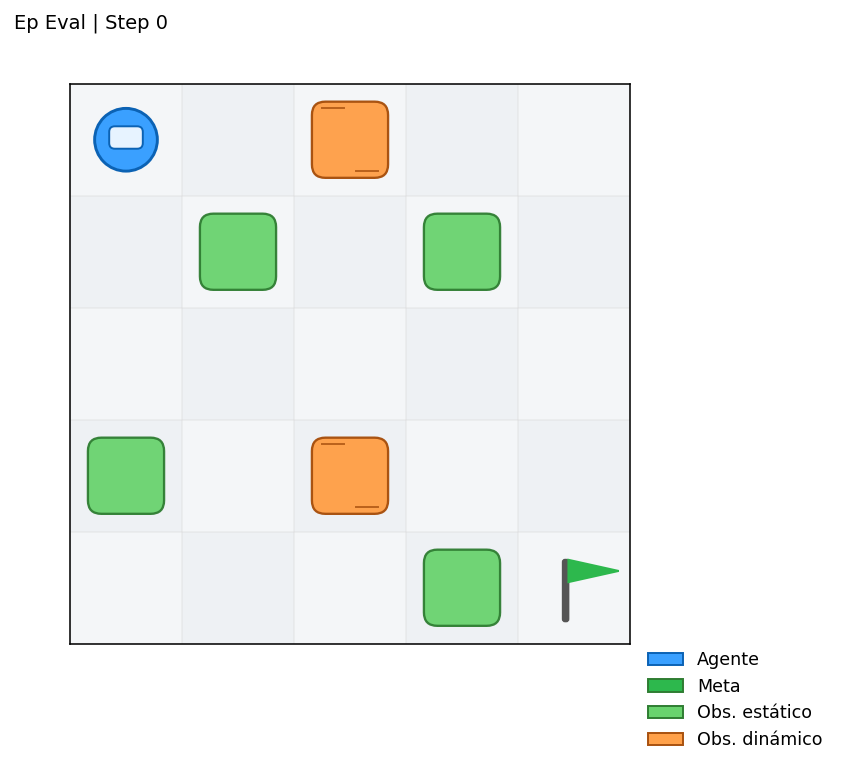

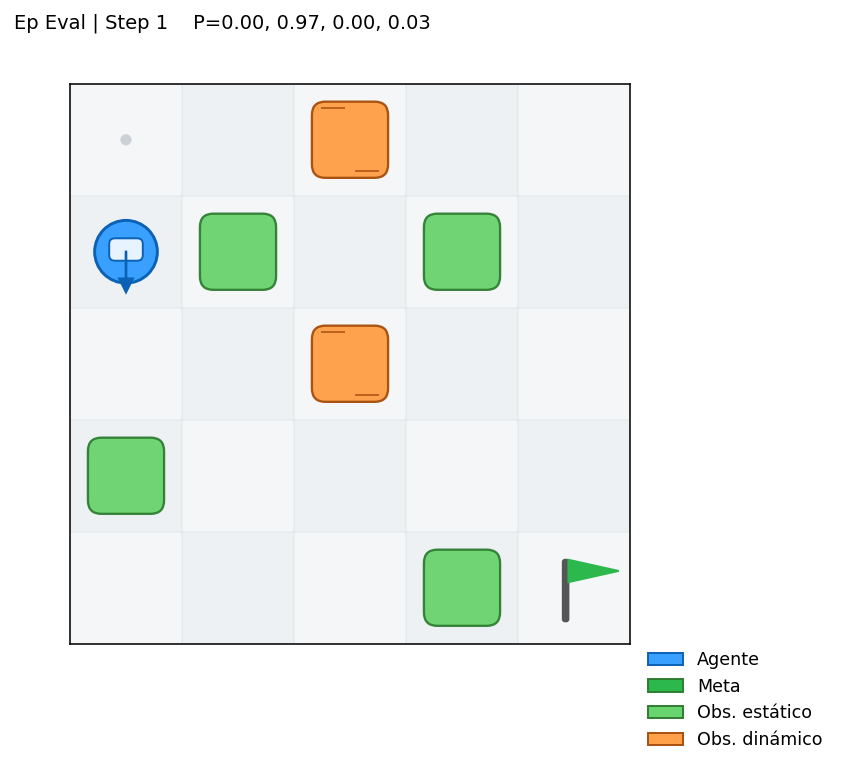

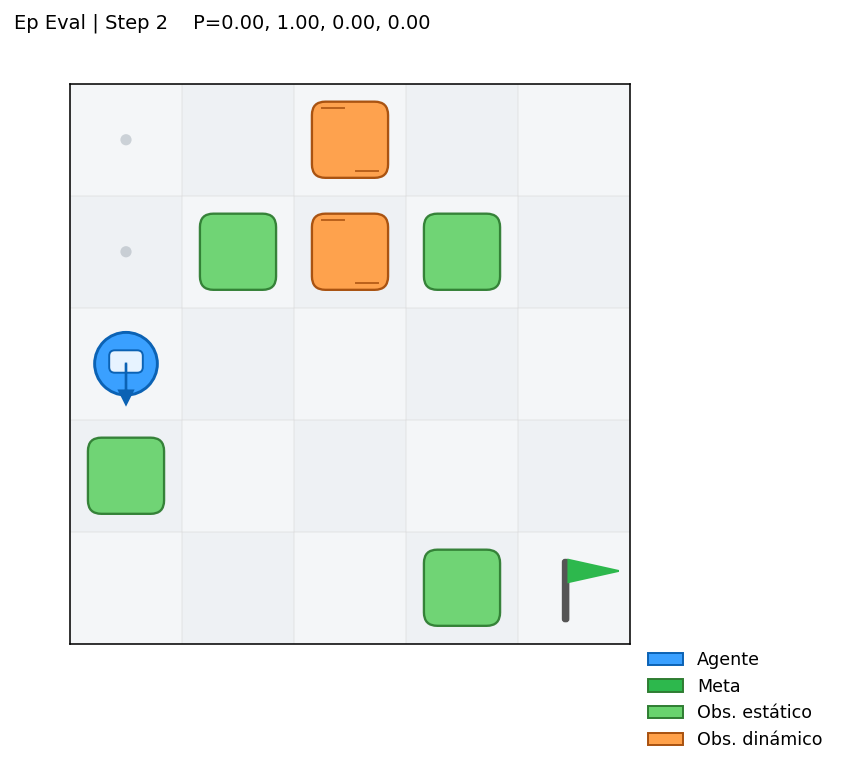

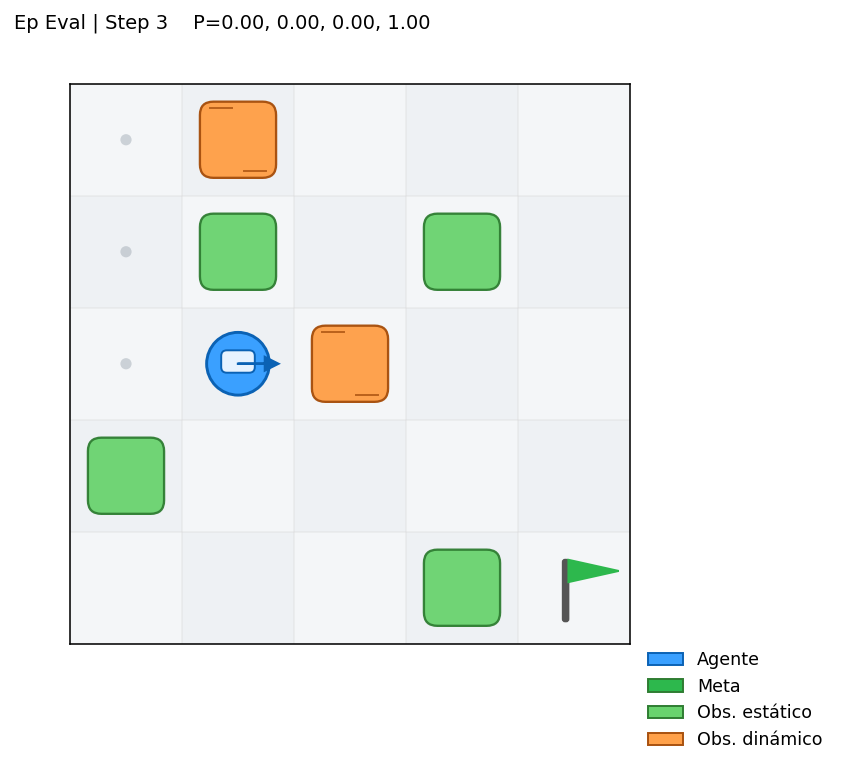

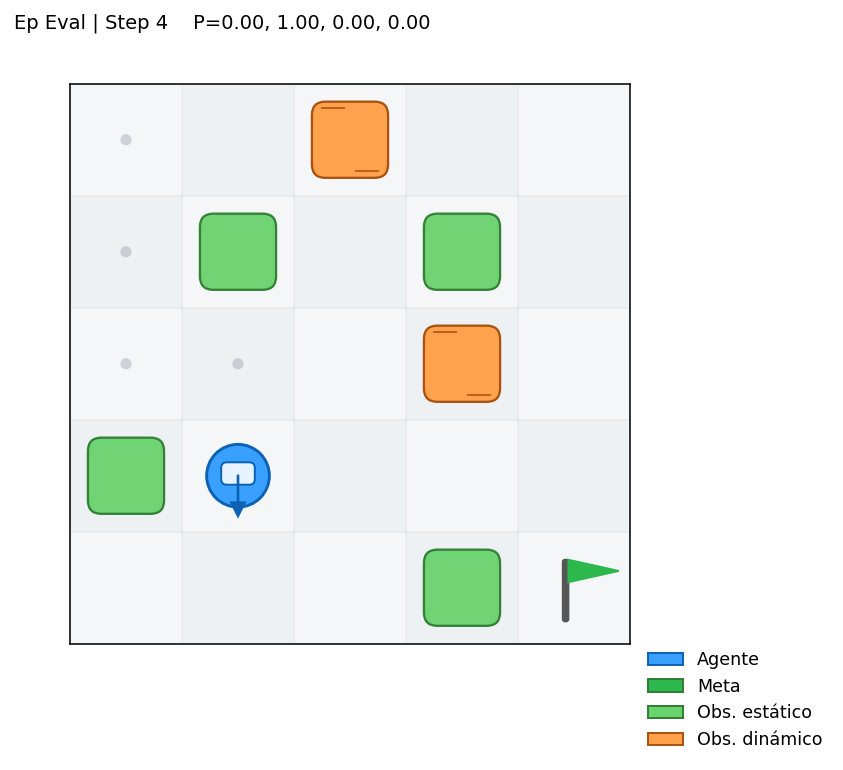

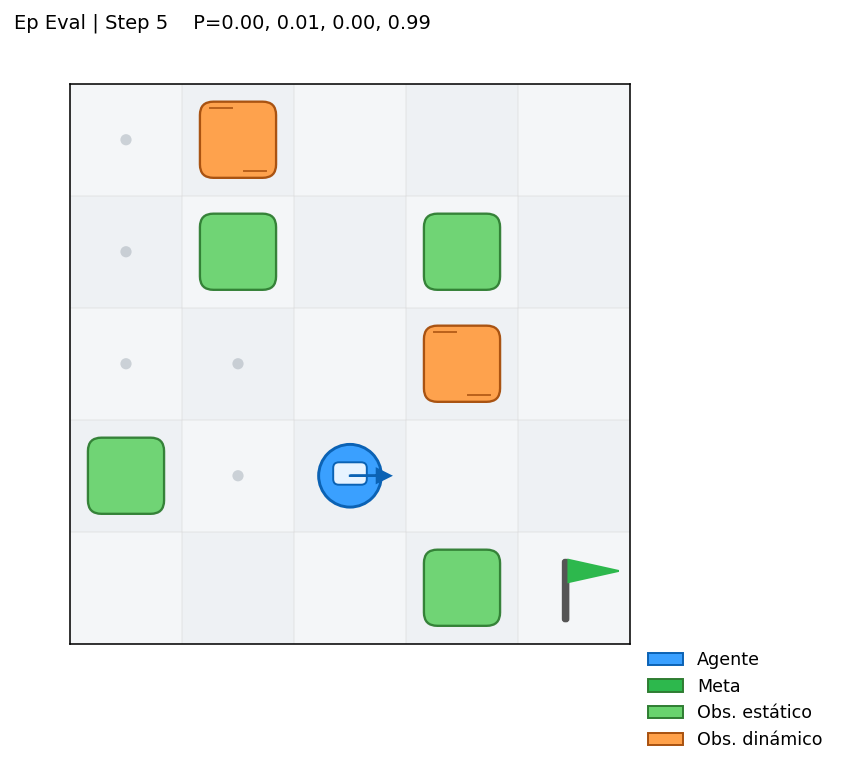

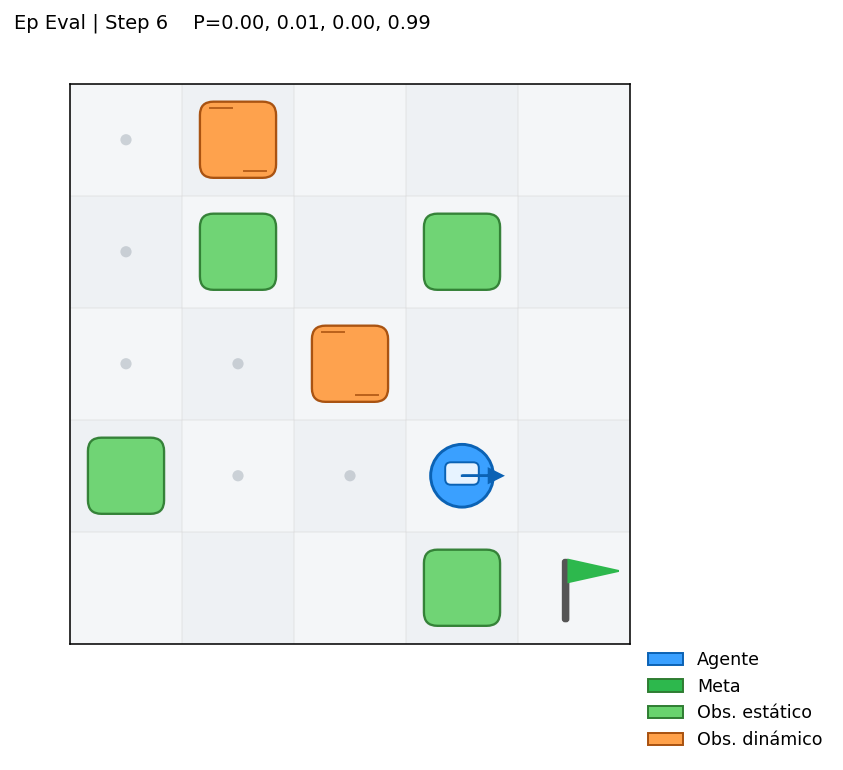

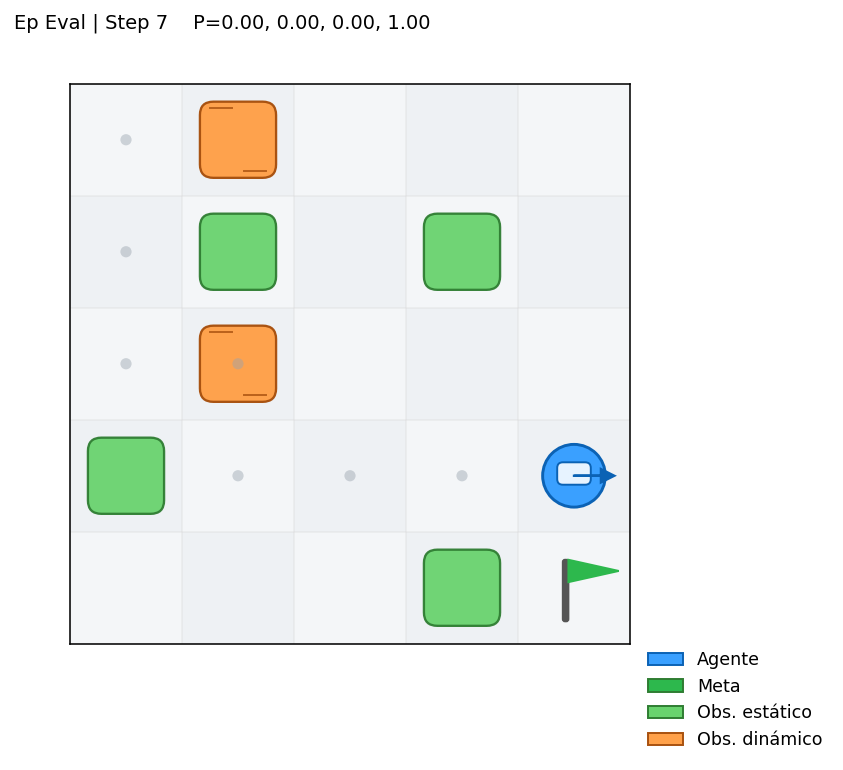

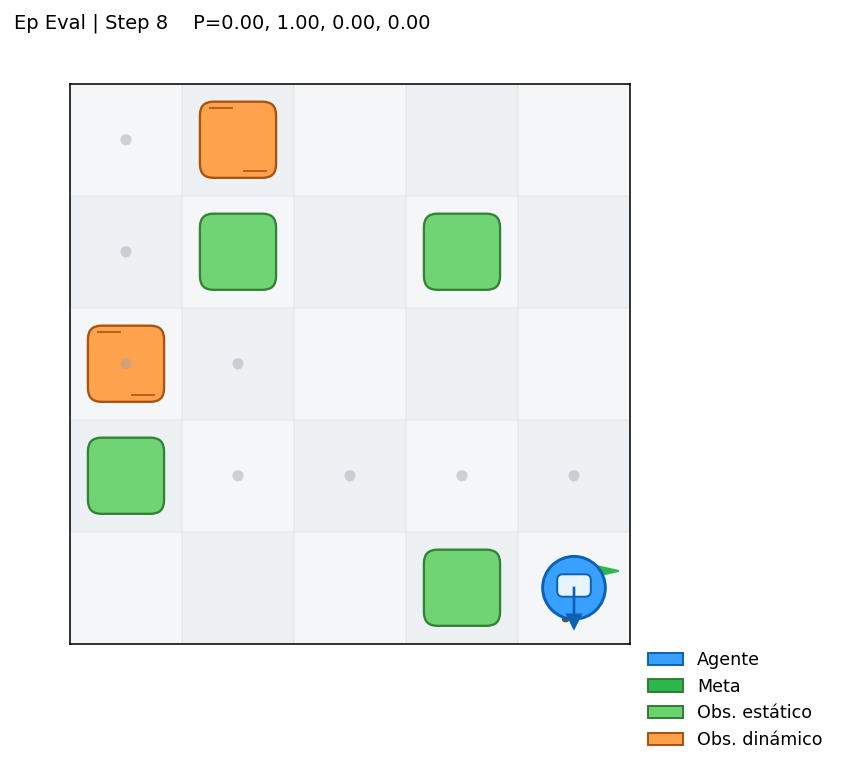

📈 Resultado final: {'path': [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4), (4, 4)], 'total_reward': 42.8, 'success': True, 'ep_len': 8, 'breakdown': {'step': -8.0, 'goal': 50.0, 'wall': 0.0, 'oob': 0.0, 'revisit': 0.0, 'no_move': 0.0}, 'counts': {'wall': 0, 'oob': 0, 'revisit': 0}}
💾 Datos guardados en: resultados/20251127_204044_rapidez__rapidez_per_episode.csv


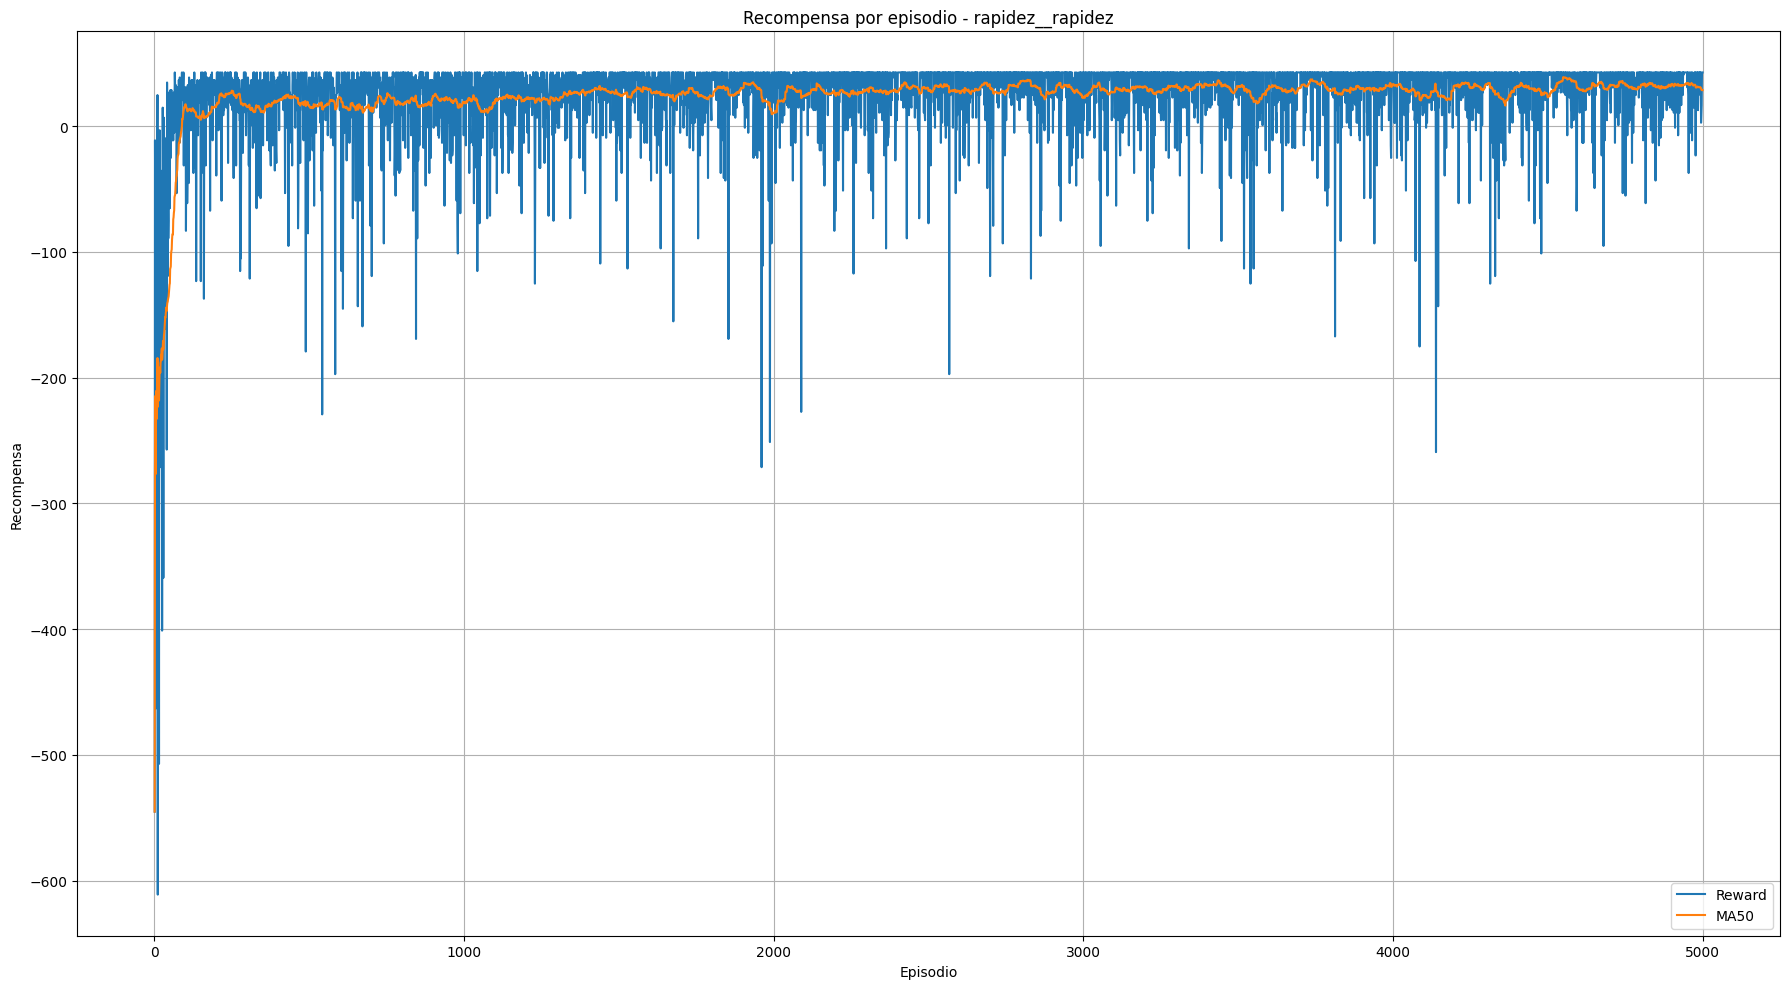

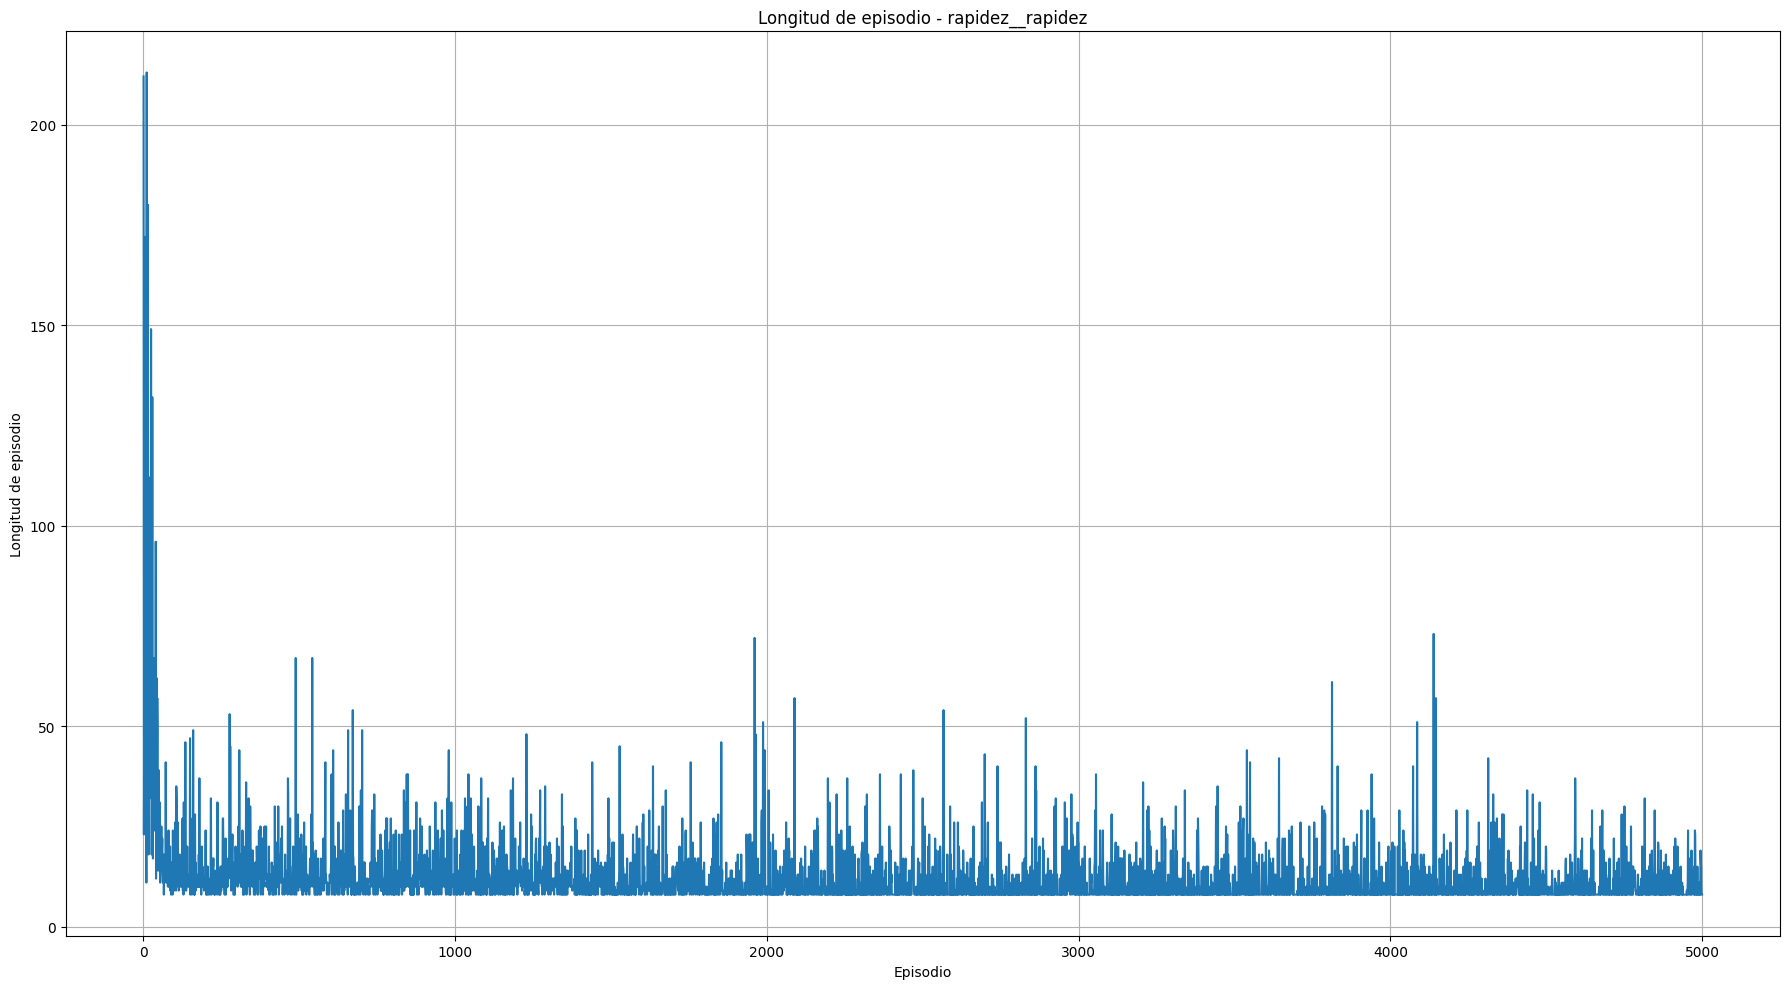


🎉 === Barrido de experimentos completado ===
📊 Resumen consolidado guardado en: resultados/20251127_204044_summary.csv
📁 Archivos detallados por experimento en carpeta 'resultados/'
✅ Listo para análisis comparativo de configuraciones


In [ ]:
# ===================================================================
# DEMONSTRAÇÃO PRINCIPAL: Ciclo completo de treinamento e avaliação
# ===================================================================

if __name__ == "__main__":
    # ===== CONFIGURAÇÃO DE DISPOSITIVO =====
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Dispositivo de computação:", device)
    # Cria diretório de saída para salvar resultados
    os.makedirs("resultados", exist_ok=True)

    # ===== CONFIGURAÇÃO DO AMBIENTE: Grid World navegável =====
    # Design de labirinto 5x5 com obstáculos estáticos e dinâmicos
    # Formato: 0=livre, -1=parede, 2=objetivo
    grid = np.array([
        [0, 0, -1, 0, 0],     # Linha 0: parede central
        [0, -1, 0, -1, 0],    # Linha 1: dois obstáculos
        [0,  0, 0,  0, 0],    # Linha 2: corredor livre
        [-1, 0,-1, 0, 0],     # Linha 3: configuração desafiante
        [0,  0, 0, -1, 2]     # Linha 4: objetivo na esquina
    ])

    # Obstáculos que se movem dinamicamente durante o episódio
    # Incrementa complexidade e exige adaptação em tempo real
    dynamic_obstacles = [(0,2), (3,2)]

    # ===== CONFIGURAÇÕES DE RECOMPENSAS =====
    # Função de recompensa que penaliza colisões e premia eficiência
    reward_configs = {

        #"equilibrado": dict(step_penalty=-0.1, goal_reward=10.0, wall_penalty=-5.0, oob_penalty=-5.0,
        #                    revisit_penalty=-0.5, no_move_penalty=-0.5),
        "rapidez": dict(step_penalty=-1.0, goal_reward=50.0, wall_penalty=-10.0, oob_penalty=-10.0,
                        revisit_penalty=-2.0, no_move_penalty=-1.0),
       #"exploracao": dict(step_penalty=-0.01, goal_reward=5.0, wall_penalty=-2.0, oob_penalty=-2.0,
       #                     revisit_penalty=-0.1, no_move_penalty=None),
       # "seguranca": dict(
       #     step_penalty=-0.1,        # Penaliza passos desnecessários (fomenta eficiência)
       #     goal_reward=20.0,         # Grande recompensa por completar tarefa
       #     wall_penalty=-30.0,       # Forte penalização por colisões
       #     oob_penalty=-30.0,        # Penaliza sair dos limites
       #     revisit_penalty=-1.0,     # Desencoraja ciclos infinitos
       #     no_move_penalty=-0.2      # Penaliza ações inválidas
       # )
    }

    # ===== CONFIGURAÇÕES DE TREINAMENTO =====
    # Hiperparâmetros otimizados para convergência estável com GAE
    train_configs = {
        #"exploracao": dict(
        #    episodes=5000,          # Episódios suficientes para convergência
        #    gamma=0.99,              # Fator de desconto alto (tarefas com horizonte longo)
        #    entropy_coef=0.01,       # Regularização para manter exploração
        #    value_coef=0.5,          # Balanço Actor-Critic (0.5 = equilibrado)
        #    max_steps=300,           # Limite de passos por episódio
        #    render=False,            # Sem visualização durante treinamento (acelera)
        #    print_every=200,         # Frequência de logs
        #    seed=1,                  # Semente para reprodutibilidade
        #    use_gae=True,            # Ativa Generalized Advantage Estimation
        #    gae_lambda=0.95          # Fator de suavização GAE (reduz variância)
        #),
        "rapidez": dict(episodes=5000, gamma=0.99, entropy_coef=0.02, value_coef=0.6,
                        max_steps=300, render=False, print_every=200, seed=2, use_gae=True, gae_lambda=0.95),
        #"equilibrada": dict(episodes=5000, gamma=0.99, entropy_coef=0.02, value_coef=0.5,
         #                   max_steps=300, render=False, print_every=200, seed=3, use_gae=True, gae_lambda=0.95)
    }

    # ===== CONFIGURAÇÃO DE ARQUITETURA =====
    state_mode = "pomdp"          # Representação de estado com informação posicional completa
    hidden_dim = 128            # Dimensão de camadas LSTM (balanço capacidade/velocidade)
    action_dim = 4              # Ações: cima, baixo, esquerda, direita

    # ===== INICIALIZAÇÃO DE MÉTRICAS =====
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Para nomes únicos de arquivos
    summary_rows = []                                      # Resumo tabulado de experimentos
    all_results = {}                                       # Resultados detalhados por configuração

    # ===== CONFIGURAÇÃO DE DINÂMICA DE OBSTÁCULOS =====
    # Sistema de movimento que cria ambiente não-estacionário
    obstacle_mode = "random"          # Movimento aleatório de obstáculos
    obstacle_stay_prob = 0.50         # Probabilidade de permanecer quieto (50%)
    obstacle_move_every = 1           # Frequência de atualização (a cada passo)
    update_order = "obstacles_then_agent"  # Sequência: move obstáculos → agente atua

    # Padrões de movimento para modo "pattern" (atualmente usa "random")
    # Permite comportamentos previsíveis se necessário
    obstacle_patterns = {
        0: [(0,1),(1,0),(0,-1),(-1,0)],    # Movimento circular
        1: [(-1,0),(1,0)]                   # Oscilação horizontal
    }

    # ===== VARREDURA DE CONFIGURAÇÕES (Grid Search) =====
    # Executa todas as combinações de recompensas × treinamento
    # Permite comparar efetividade de distintos hiperparâmetros
    for rname, rconf in reward_configs.items():
        for tname, tconf in train_configs.items():
            combo_name = f"{rname}__{tname}"
            print(f"\n Executando experimento: {combo_name}")

            # ===== CONSTRUÇÃO DO AMBIENTE DINÂMICO =====
            # Fusiona todos os parâmetros em uma configuração unificada
            env_params = dict(
                size=5, start=(0,0), goal=(4,4),      # Topologia básica
                grid=grid,                             # Layout de obstáculos fixos
                state_mode=state_mode,                 # Formato de representação
                **rconf,                               # Parâmetros de recompensa
                dynamic_obstacles=dynamic_obstacles,   # Obstáculos móveis
                obstacle_mode=obstacle_mode,           # Tipo de movimento
                obstacle_stay_prob=obstacle_stay_prob, # Probabilidades de dinâmica
                obstacle_move_every=obstacle_move_every,
                obstacle_patterns=obstacle_patterns if obstacle_mode=="pattern" else None,
                update_order=update_order,             # Sequência de atualização
                seed=tconf.get("seed", None)           # Reprodutibilidade
            )
            # ===== INSTANCIAÇÃO DO AMBIENTE =====
            env = GridWorld(**env_params)
            print(f"✅ Ambiente criado com obstáculos dinâmicos: {dynamic_obstacles}")

            # ===== CONFIGURAÇÃO DE DIMENSÕES =====
            # Calcula dimensionalidade do espaço de estados segundo representação
            if state_mode == "mdp":
                # Codificação completa: posição + obstáculos + objetivo + agente
                state_dim = env.size * env.size * 4
            else:
                # Codificação básica: só posição + objetivo
                state_dim = env.size * env.size * 2

            # ===== CONSTRUÇÃO DE REDES NEURAIS =====
            # Arquitetura Actor-Critic com memória LSTM para sequências
            actor = Actor(state_dim, hidden_dim, action_dim).to(device)
            critic = Critic(state_dim, hidden_dim).to(device)

            # Otimizadores com learning rates diferenciados
            # Critic aprende mais rápido para estimação de valor estável
            actor_opt  = optim.Adam(actor.parameters(),  lr=3e-4)
            critic_opt = optim.Adam(critic.parameters(), lr=8e-4, eps=1e-5)


            # ===== FASE DE TREINAMENTO =====
            print(" Iniciando treinamento A2C com GAE...")
            result = train(env, actor, critic, actor_opt, critic_opt, device=device, **tconf)

            # Armazena resultados completos para análise posterior
            all_results[combo_name] = {
                "reward_config": rconf,
                "train_config": tconf,
                "result": result
            }

            # ===== AVALIAÇÃO FINAL =====
            print("📊 Executando avaliação determinística...")
            eval_res = evaluate(env, actor, device=device, render=True)
            print("📈 Resultado final:", eval_res)

            # ===== EXPORTAÇÃO DE DADOS DE TREINAMENTO =====
            # Estrutura métricas episódicas para análise temporal
            df = pd.DataFrame({
                "episode": np.arange(1, len(result["rewards"])+1),  # Numeração sequencial
                "reward": result["rewards"],                        # Recompensa total por episódio
                "success": result["success"],                       # Indicador binário de sucesso
                "ep_len": result["ep_len"],                        # Comprimento de episódio
                "ma100_success": result["ma100_success"]           # Média móvel de taxa de sucesso
            })

            # Salva dados tabulados com timestamp para rastreabilidade
            csv_path = f"resultados/{timestamp}_{combo_name}_per_episode.csv"
            df.to_csv(csv_path, index=False)
            print(f"💾 Dados salvos em: {csv_path}")

            plt.figure(figsize=(18,10))
            plt.plot(df["episode"], df["reward"], label="Reward")
            plt.plot(df["episode"], moving_average(df["reward"].tolist(), 50), label="MA50")
            plt.xlabel("Episódio"); plt.ylabel("Recompensa")
            plt.title(f"Recompensa por episódio - {combo_name}")
            plt.grid(True); plt.legend(); plt.tight_layout()
            fig_path = f"resultados/{timestamp}_{combo_name}_rewards.png"
            plt.savefig(fig_path); plt.show(); plt.close()

            plt.figure(figsize=(18,10))
            plt.plot(df["episode"], df["ep_len"])
            plt.xlabel("Episódio"); plt.ylabel("Comprimento de episódio")
            plt.title(f"Comprimento de episódio - {combo_name}")
            plt.grid(True); plt.tight_layout()
            fig2_path = f"resultados/{timestamp}_{combo_name}_eplen.png"
            plt.savefig(fig2_path); plt.show(); plt.close()

            avg_reward = float(np.mean(result["rewards"]))
            last_ma100 = float(pd.Series(result["rewards"]).rolling(100, min_periods=1).mean().iloc[-1])
            success_rate = float(np.mean(result["success"]))
            avg_len = float(np.mean(result["ep_len"]))



            # ===== CONSOLIDAÇÃO DE MÉTRICAS POR EXPERIMENTO =====
            # Compilamos todas as métricas relevantes em uma linha resumo
            summary_rows.append({
                # Identificadores do experimento
                "combo": combo_name,                              # Nome único da configuração
                "state_mode": state_mode,                         # Tipo de representação de estado
                "dynamic_obstacles": str(dynamic_obstacles),      # Obstáculos dinâmicos ativos
                "obstacle_mode": obstacle_mode,                   # Modo de movimento de obstáculos
                "obstacle_move_every": obstacle_move_every,       # Frequência de movimento
                "update_order": update_order,                     # Ordem de atualização

                # Métricas de treinamento
                "avg_reward": avg_reward,                         # Recompensa média durante treinamento
                "ma100_last": last_ma100,                         # Média móvel final (convergência)
                "success_rate": success_rate,                     # Taxa de sucesso no treinamento
                "avg_ep_len": avg_len,                           # Comprimento médio de episódios
                "num_episodes": len(result["rewards"]),          # Total de episódios treinados

                # Métricas de avaliação final
                "eval_total_reward": eval_res.get("total_reward", None),  # Recompensa na avaliação
                "eval_success": eval_res.get("success", None),           # Sucesso na avaliação
                "eval_ep_len": eval_res.get("ep_len", None),            # Passos na avaliação

                # Contadores detalhados de eventos
                "eval_counts_wall": eval_res["counts"]["wall"],          # Colisões com paredes
                "eval_counts_oob": eval_res["counts"]["oob"],           # Saídas dos limites
                "eval_counts_revisit": eval_res["counts"]["revisit"],   # Células revisitadas

                # Rotas de arquivos gerados
                "csv_path": csv_path,                             # Dados episódicos
                "fig_reward_path": fig_path,                      # Gráfico de recompensas
                "fig_eplen_path": fig2_path                       # Gráfico de comprimentos
            })

    # ===== EXPORTAÇÃO DO RESUMO CONSOLIDADO =====
    summary_df = pd.DataFrame(summary_rows)
    summary_csv = f"resultados/{timestamp}_summary.csv"
    summary_df.to_csv(summary_csv, index=False)

    print("\n === Varredura de experimentos completada ===")
    print(f"📊 Resumo consolidado salvo em: {summary_csv}")
    print("📁 Arquivos detalhados por experimento na pasta 'resultados/'")
    print("✅ Pronto para análise comparativa de configurações")


🧪 === INICIANDO PRUEBAS DE ROBUSTEZ ===
Objetivo: Validar la capacidad de adaptación del agente entrenado

>>> Prueba A: Evaluación en entorno estático (línea base)
Propósito: Establecer rendimiento de referencia sin obstáculos dinámicos


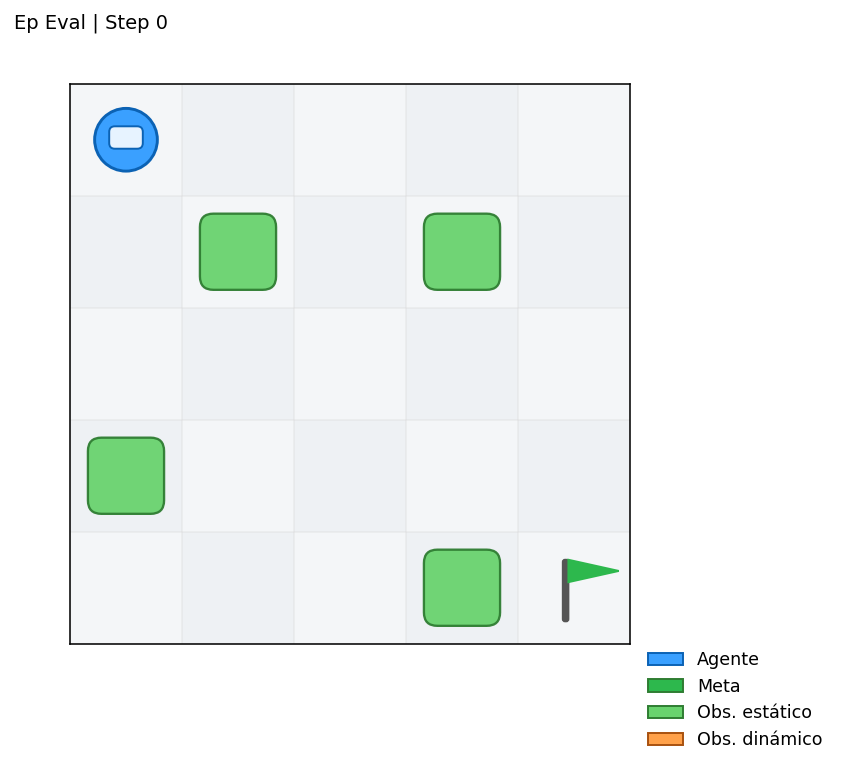

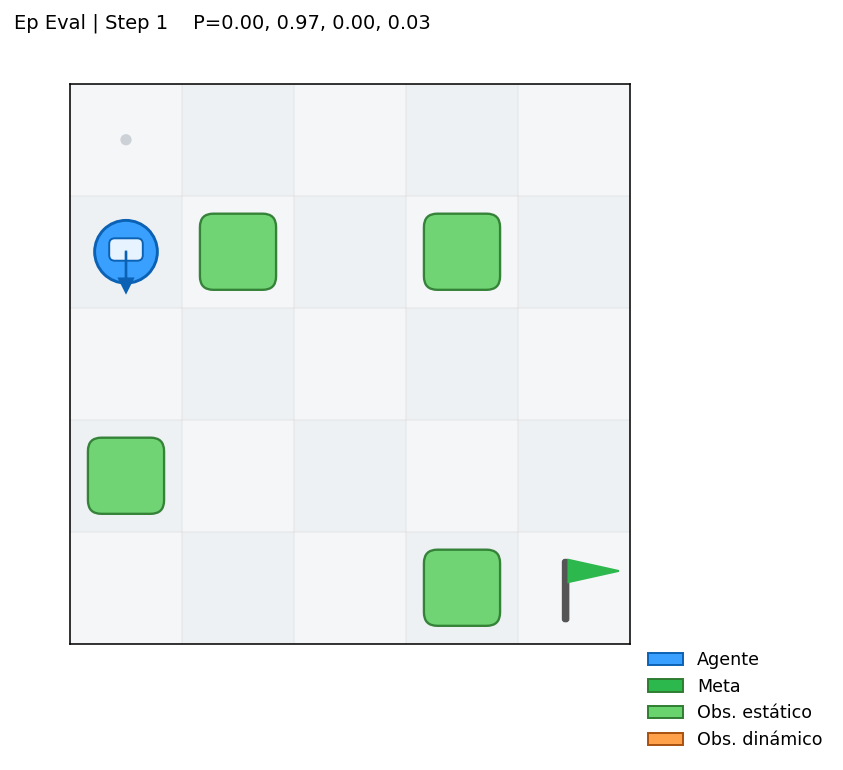

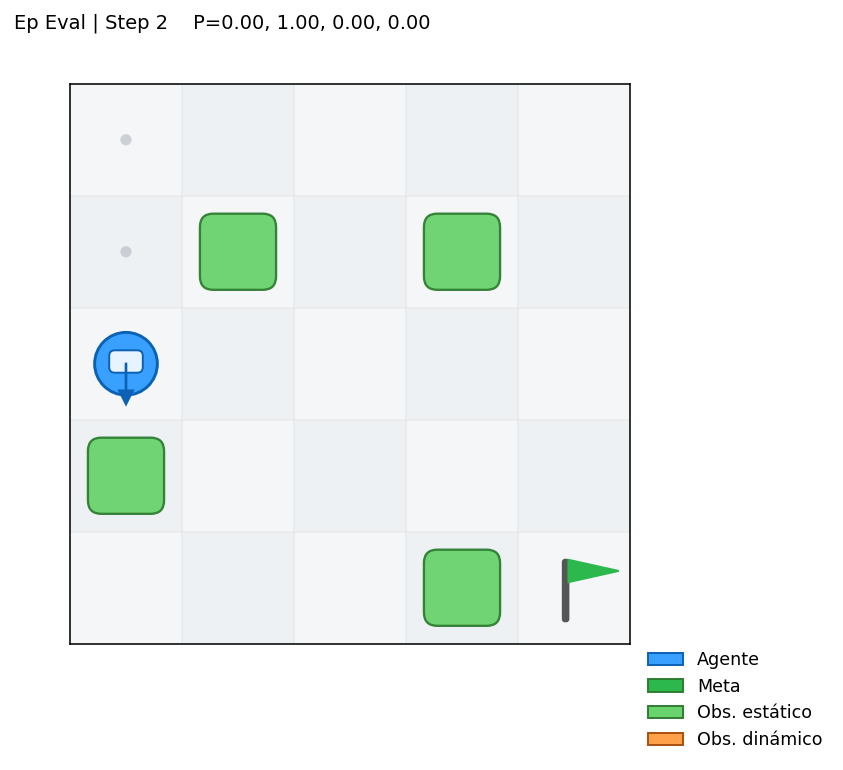

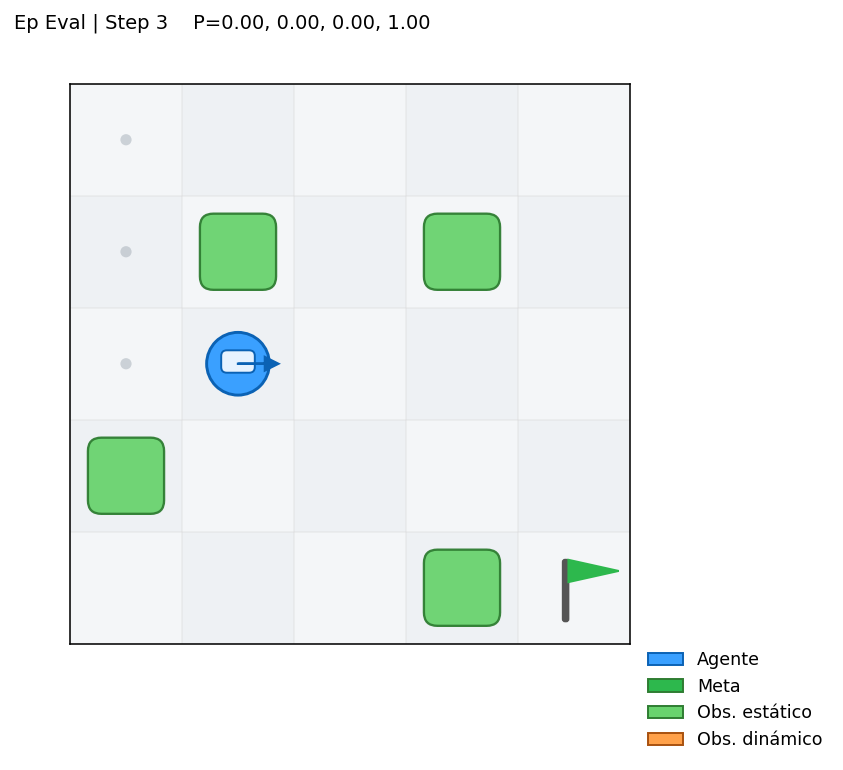

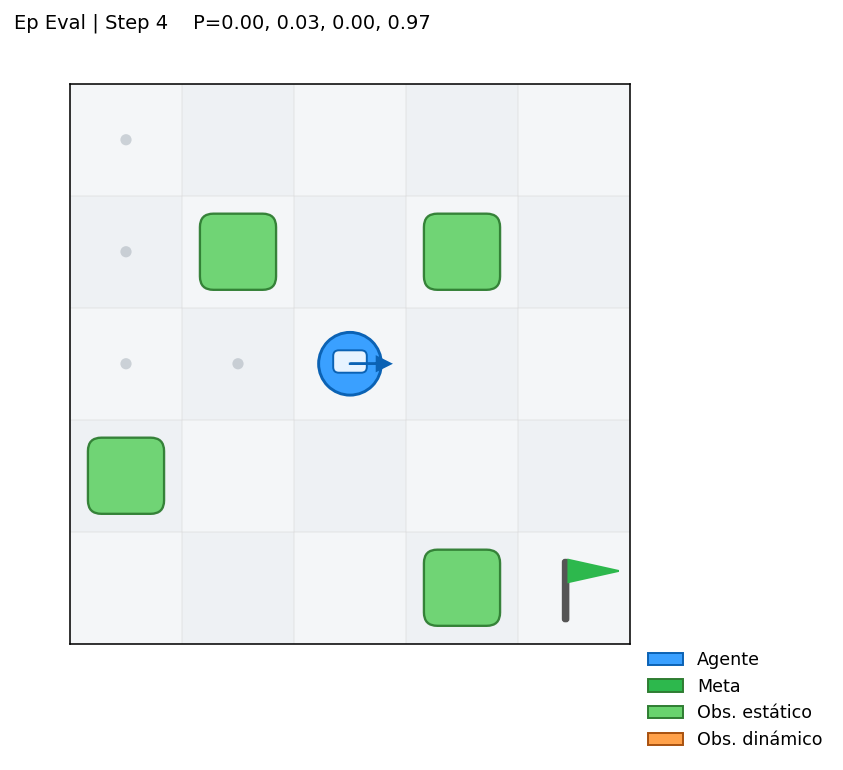

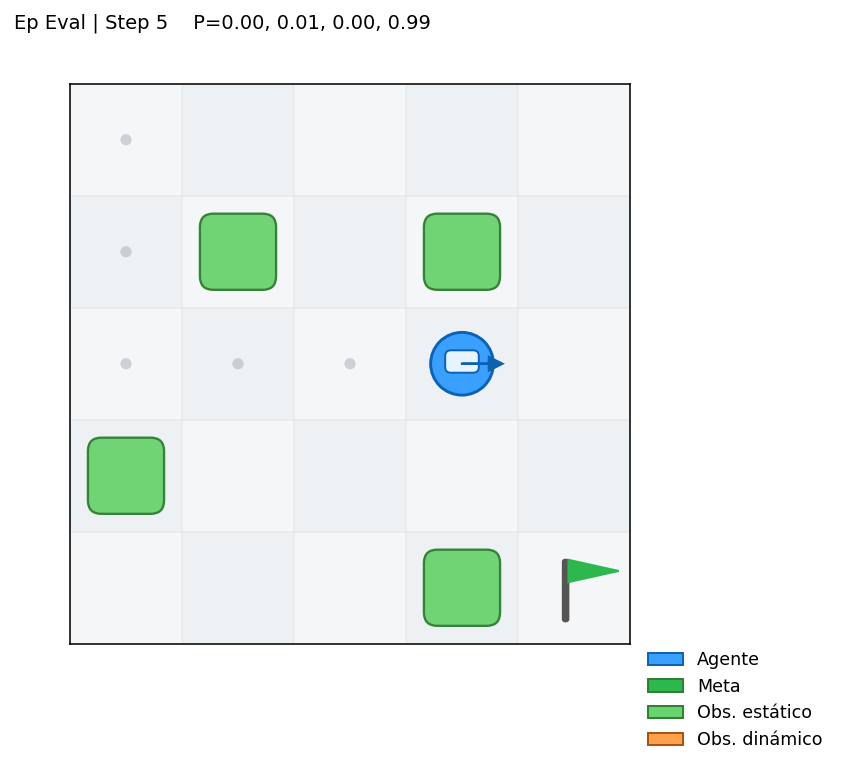

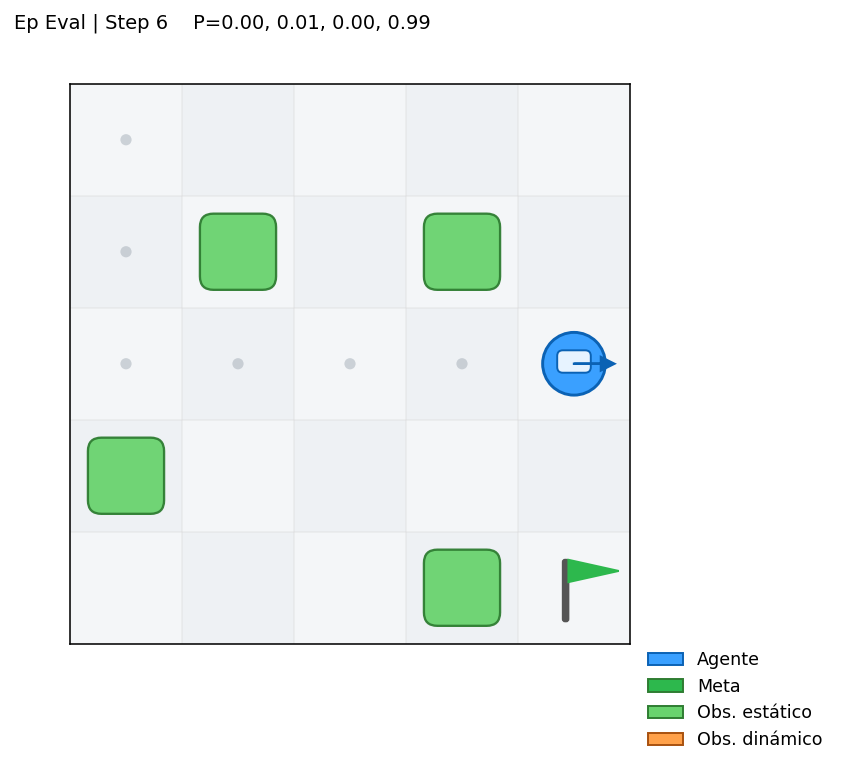

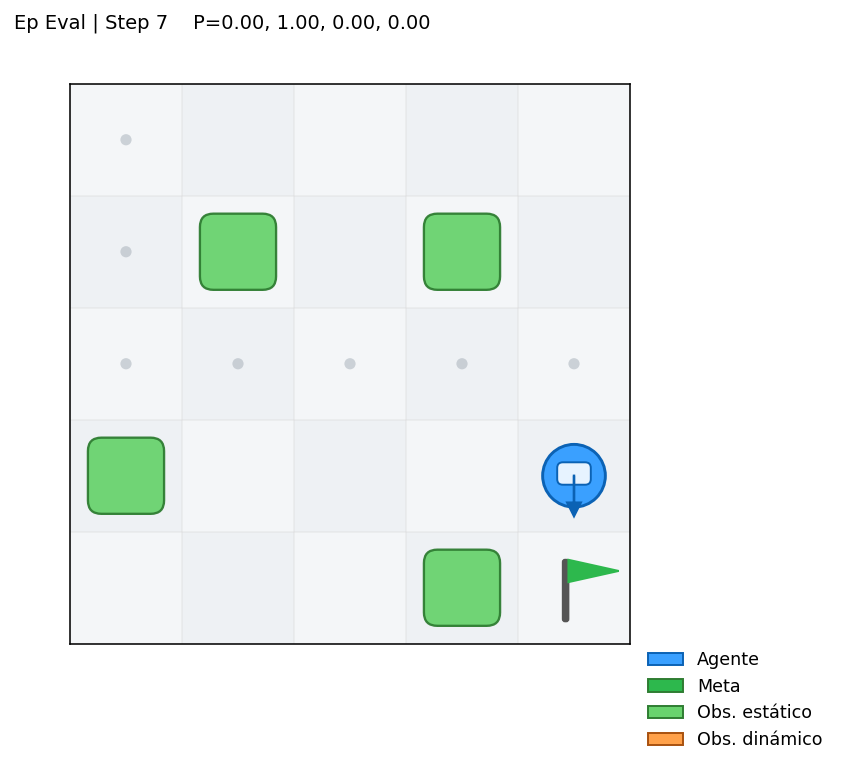

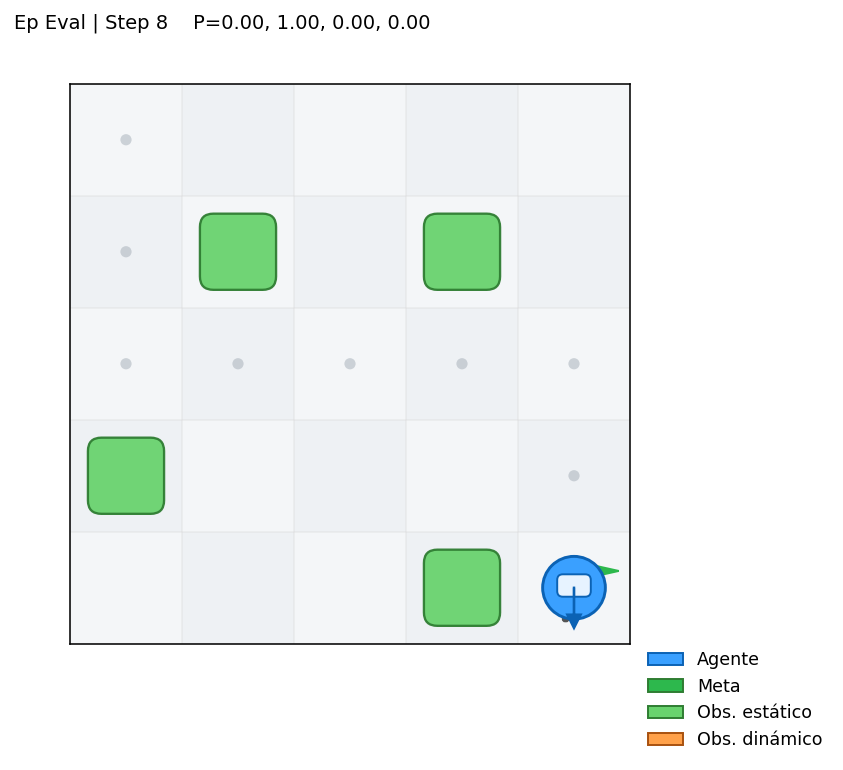

📈 Línea base establecida: True éxito, 8 pasos
Esta será la referencia para comparar rendimiento bajo estrés


In [ ]:
# ===================================================================
# TESTES DE ROBUSTEZ PÓS-TREINAMENTO
# ===================================================================
print("\n === INICIANDO TESTES DE ROBUSTEZ ===")
print("Objetivo: Validar a capacidade de adaptação do agente treinado")

# ===== TESTE A: LINHA BASE EM AMBIENTE ESTÁTICO =====
print("\n>>> Teste A: Avaliação em ambiente estático (linha base)")
print("Propósito: Estabelecer desempenho de referência sem obstáculos dinâmicos")

# Cria versão estática para medição controlada
env_static = make_static_env_like(env)

# Preserva tema visual se existir (mantém visualização consistente)
if hasattr(env, "_theme"):
    env_static.attach_theme(env._theme,
                            zoom=getattr(env, "_tile_zoom", 0.85),
                            grid_color=getattr(env, "_grid_color", "#d6d6d6"))

# Executa avaliação determinística com visualização
base = eval_determinista(env_static, actor, device, render=True)
print(f"📈 Linha base estabelecida: {base['success']} sucesso, {base['ep_len']} passos")
print("Esta será a referência para comparar desempenho sob estresse")


>>> Prueba B: Bloquear una celda de la ruta base y verificar re-ruta
Objetivo: Evaluar si el agente puede adaptarse a obstáculos inesperados
Método: Inserta bloqueo artificial en la ruta óptima y mide adaptación
>>> Bloqueo en celda: (2, 2)


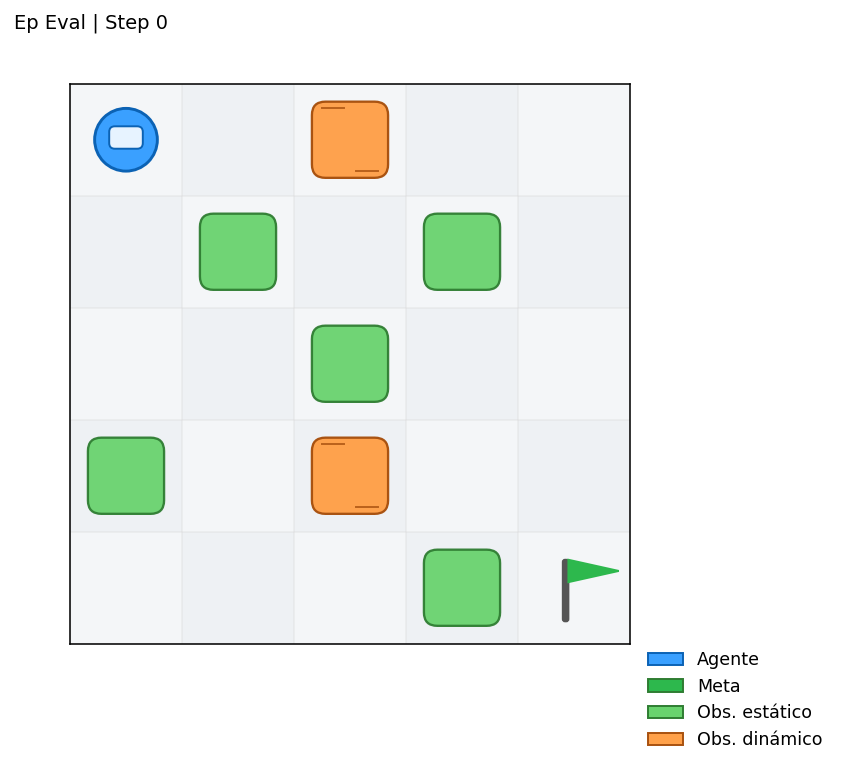

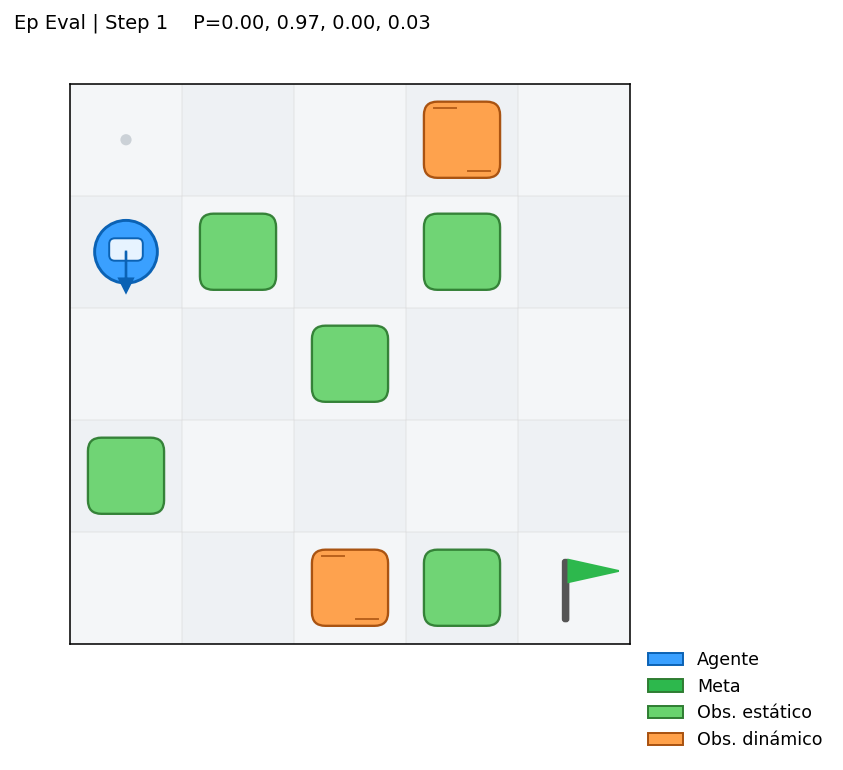

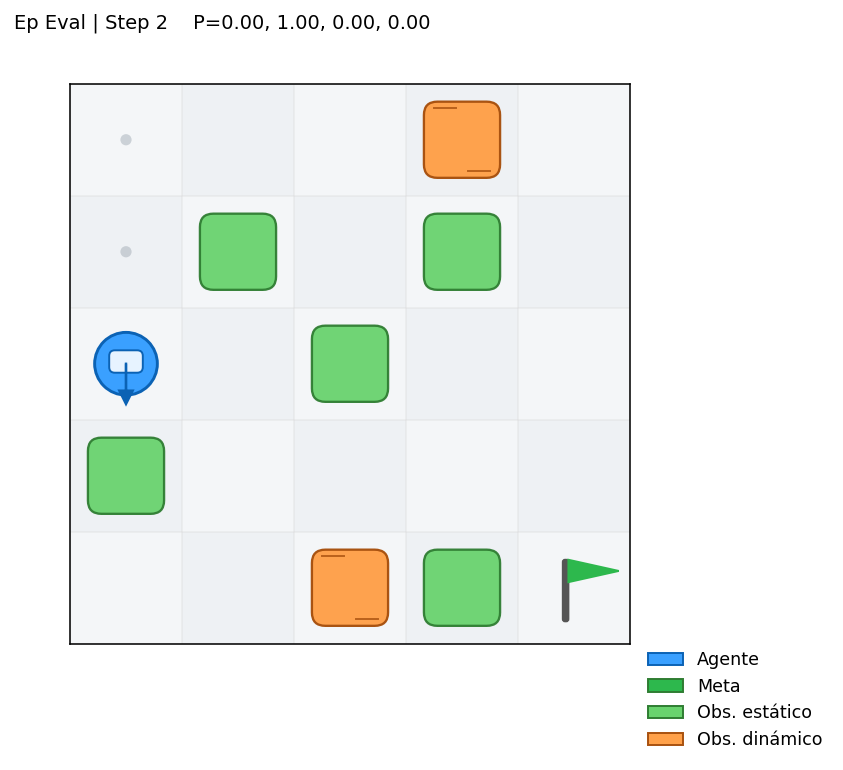

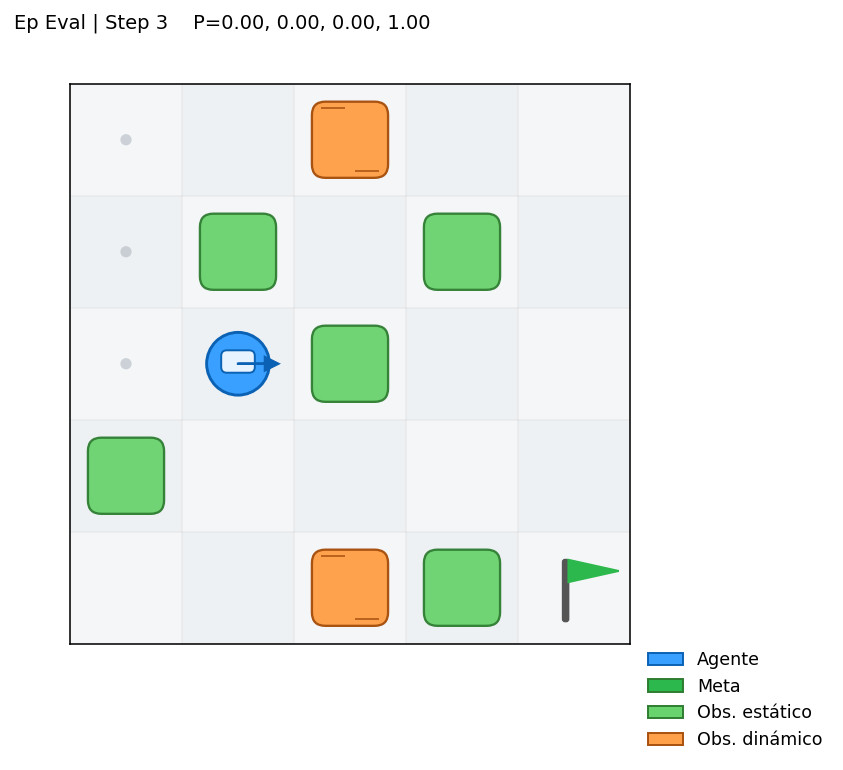

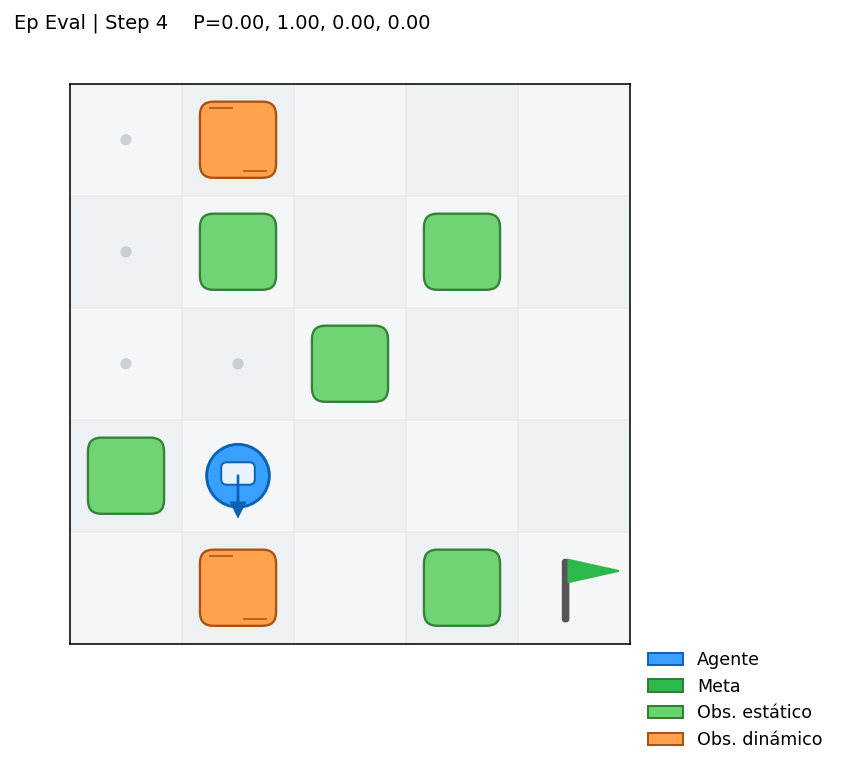

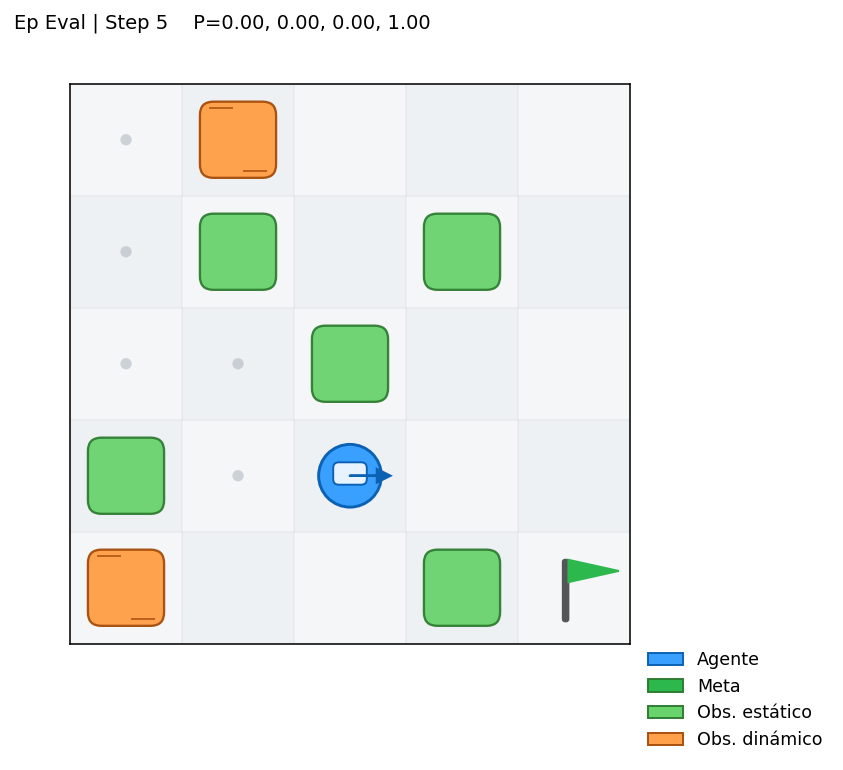

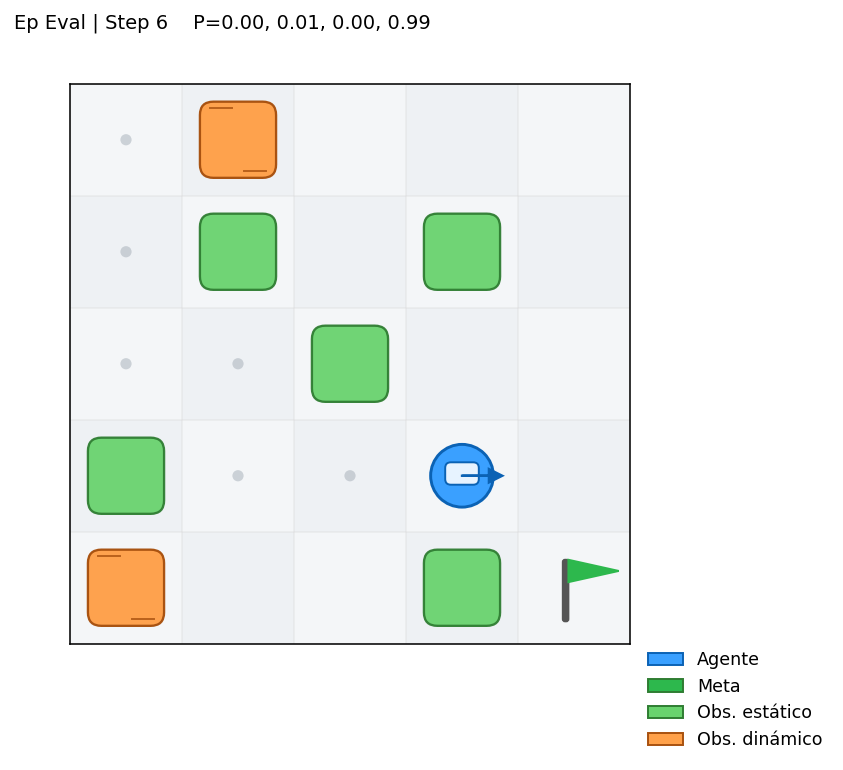

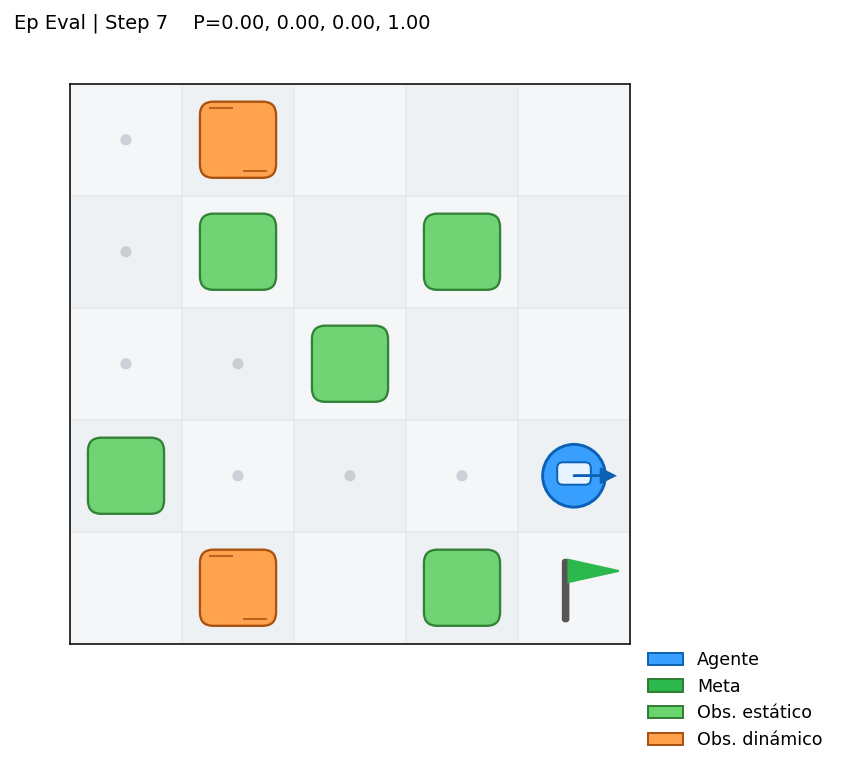

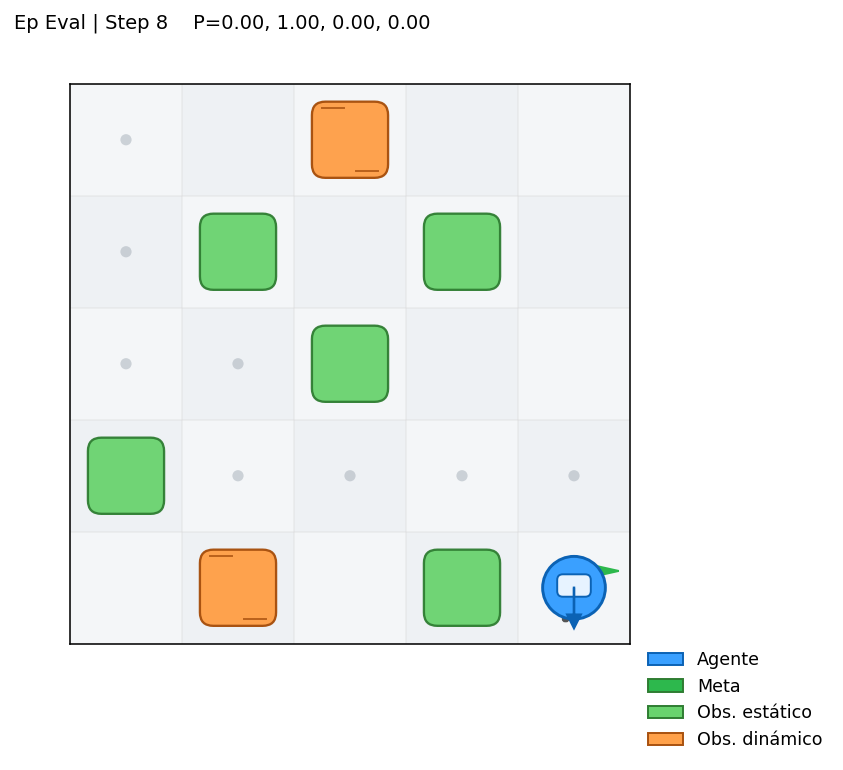

>>> Resultado bloqueo: {'block_cell': (2, 2), 'base': {'success': True, 'len': 9}, 'reroute': {'success': True, 'len': 9}, 'detour_steps': 0, 'diverge_idx': 4, 'rejoin_idx': 7, 'collisions': {'wall': 0, 'oob': 0, 'revisit': 0}, 'breakdown': {'step': -8.0, 'goal': 50.0, 'wall': 0.0, 'oob': 0.0, 'revisit': 0.0, 'no_move': 0.0}}
✅ ÉXITO: El agente encontró ruta alternativa
   Costo del desvío: 0 pasos adicionales
   Divergencia en paso: 4
   Reencuentro en paso: 7


In [ ]:
# ===== TESTE B: CAPACIDADE DE ADAPTAÇÃO E RE-ROTA =====
print("\n>>> Teste B: Bloquear uma célula da rota base e verificar re-rota")
print("Objetivo: Avaliar se o agente pode se adaptar a obstáculos inesperados")
print("Método: Insere bloqueio artificial na rota ótima e mede adaptação")

# Executa teste de re-rota com visualização
bloqueo = test_block_on_base_path(env, actor, device, block_index=None, render=True, pause=0.05)

# Interpretação de resultados
if bloqueo.get("base_success", True):
    if bloqueo["reroute"]["success"]:
        print("✅ SUCESSO: O agente encontrou rota alternativa")
        if bloqueo["detour_steps"] is not None:
            print(f"   Custo do desvio: {bloqueo['detour_steps']} passos adicionais")
        if bloqueo["diverge_idx"] is not None:
            print(f"   Divergência no passo: {bloqueo['diverge_idx']}")
        if bloqueo["rejoin_idx"] is not None:
            print(f"   Reencontro no passo: {bloqueo['rejoin_idx']}")
    else:
        print("❌ FALHA: O agente não conseguiu se adaptar ao bloqueio")
        print("   Isso pode indicar sobreajuste a rotas específicas")


>>> Prueba C: Stress test con obstáculos dinámicos (N=50)
Objetivo: Medir robustez estadística bajo condiciones variables
Método: Múltiples evaluaciones independientes con obstáculos móviles


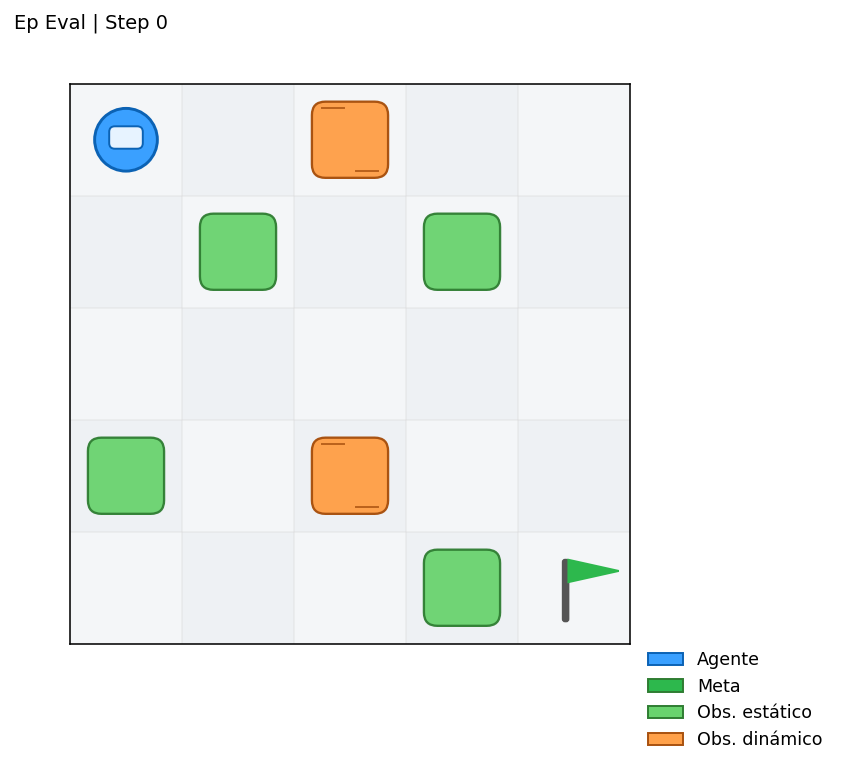

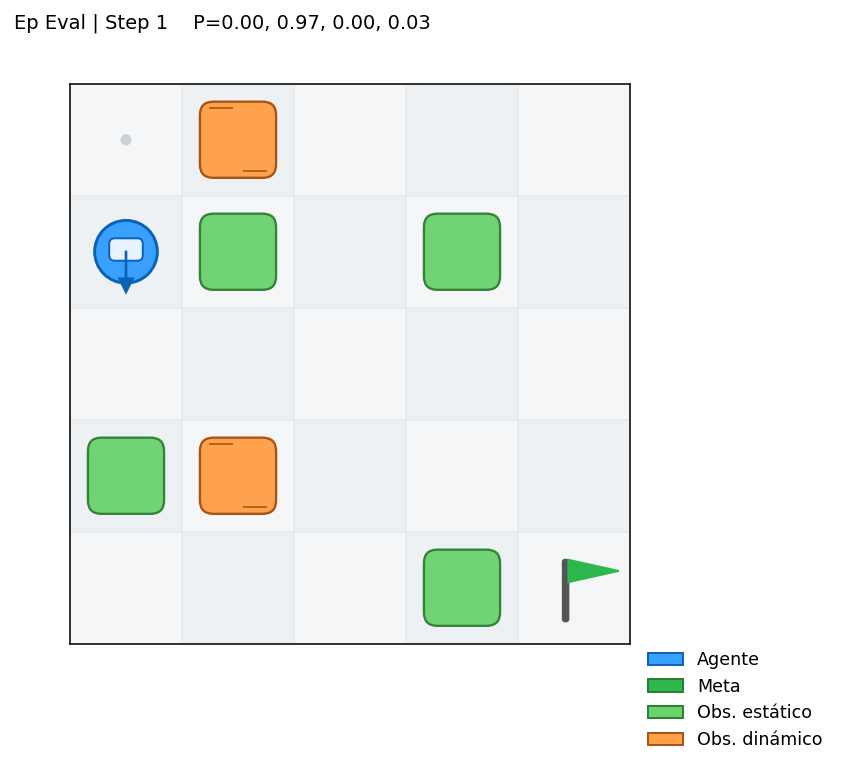

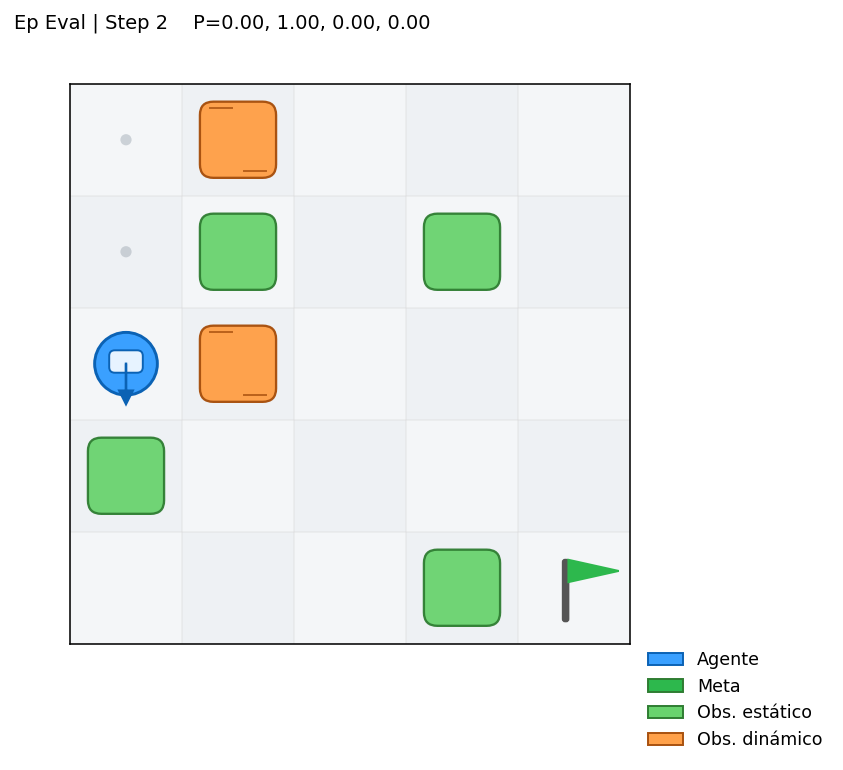

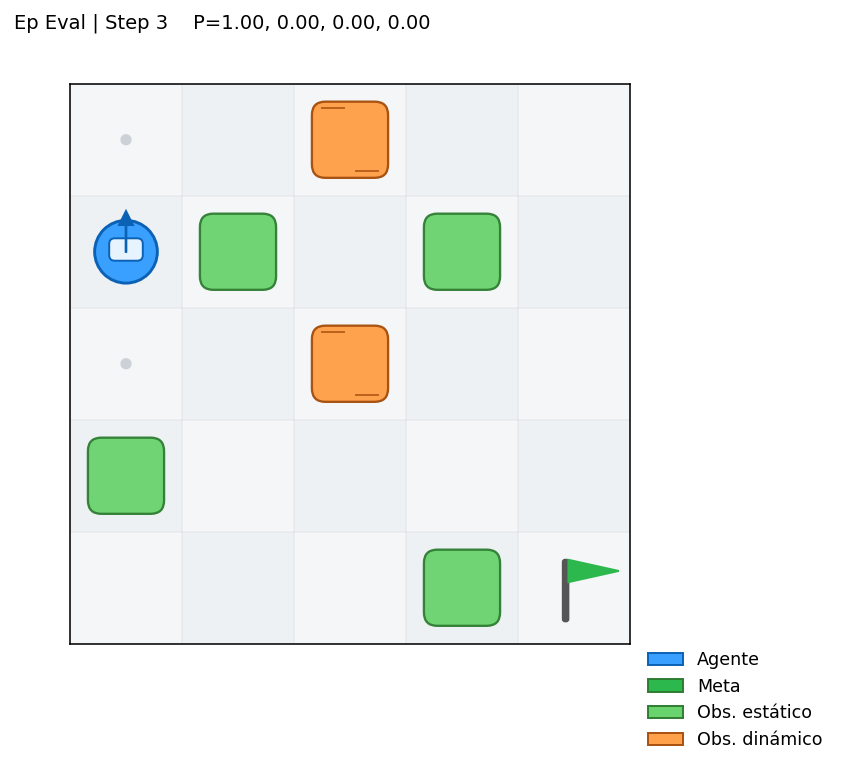

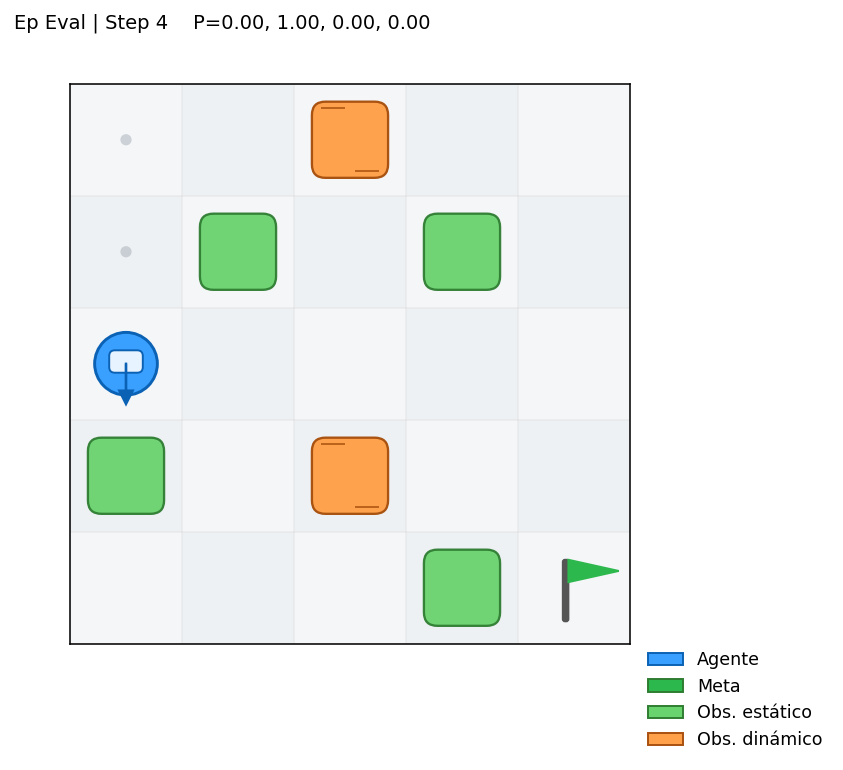

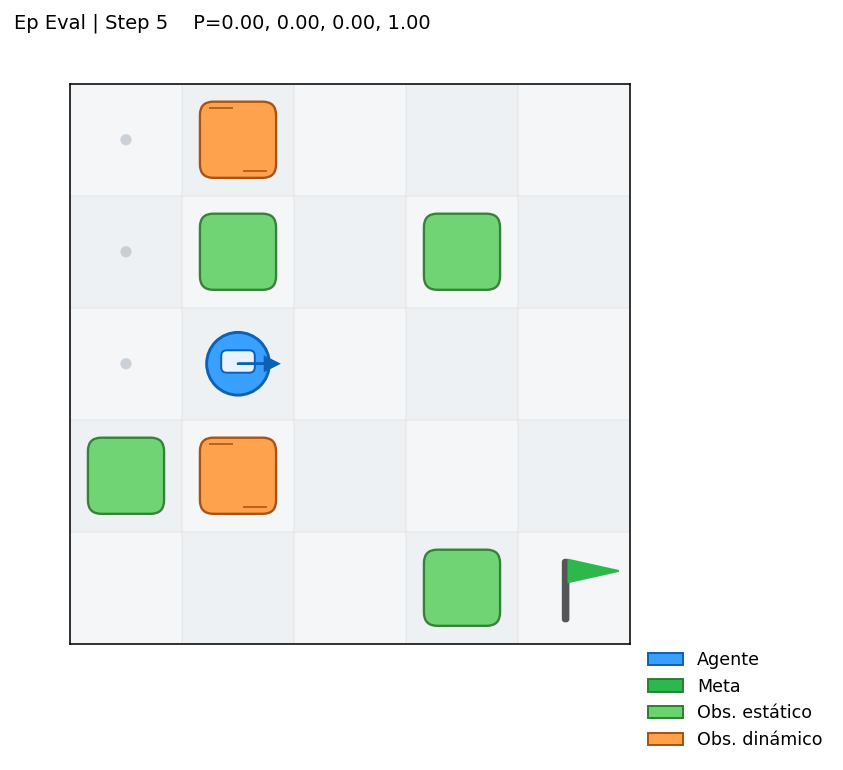

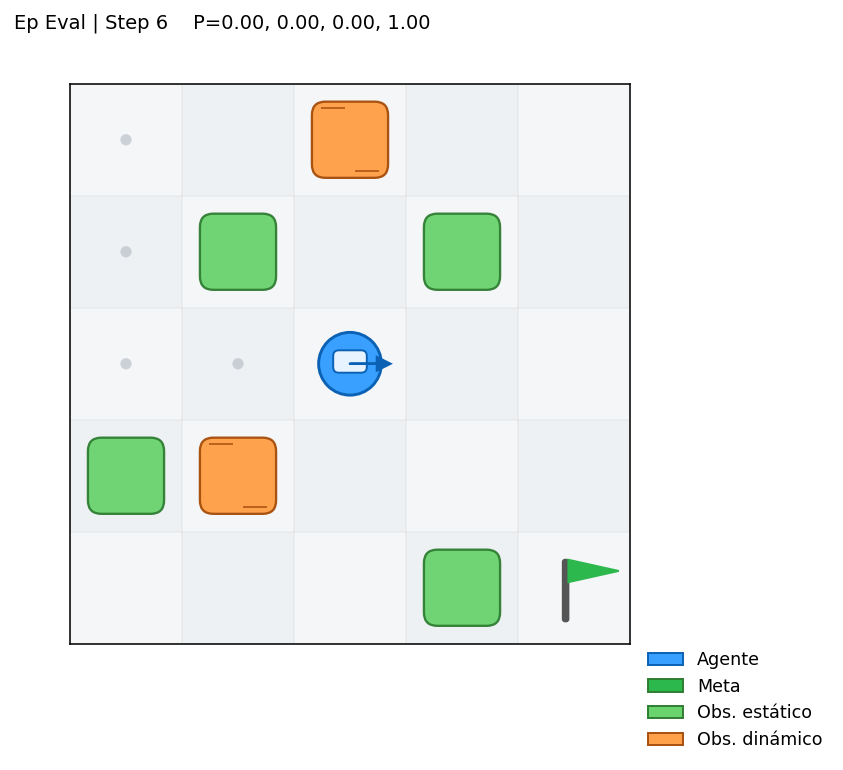

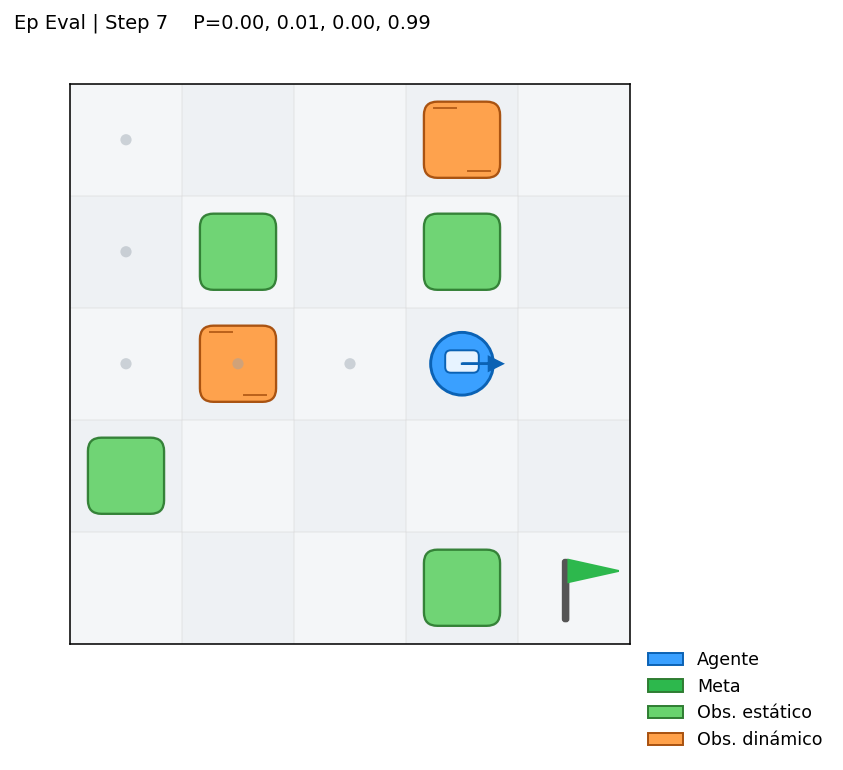

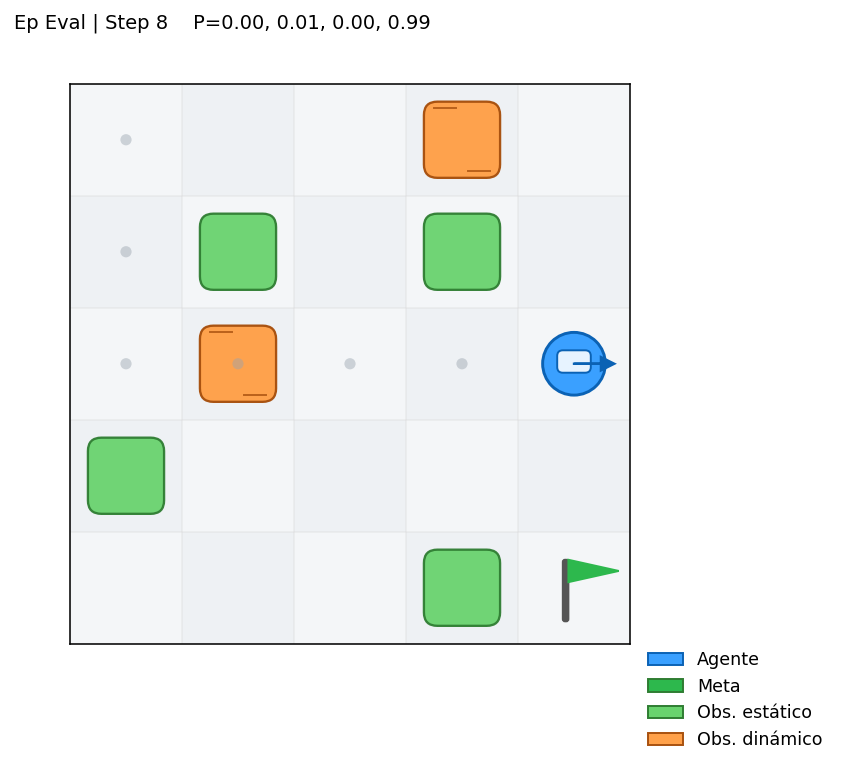

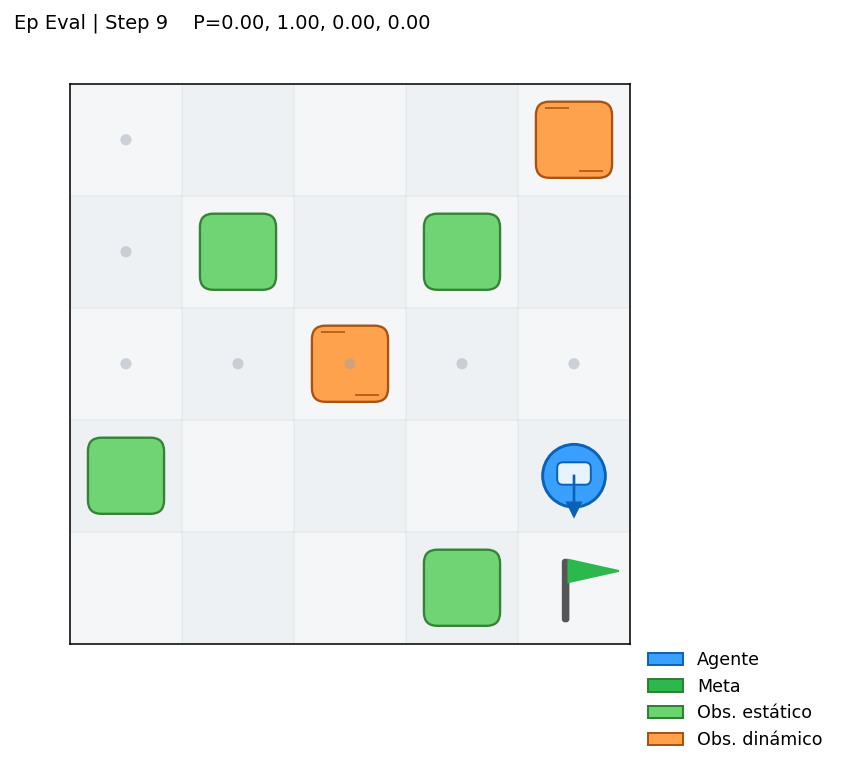

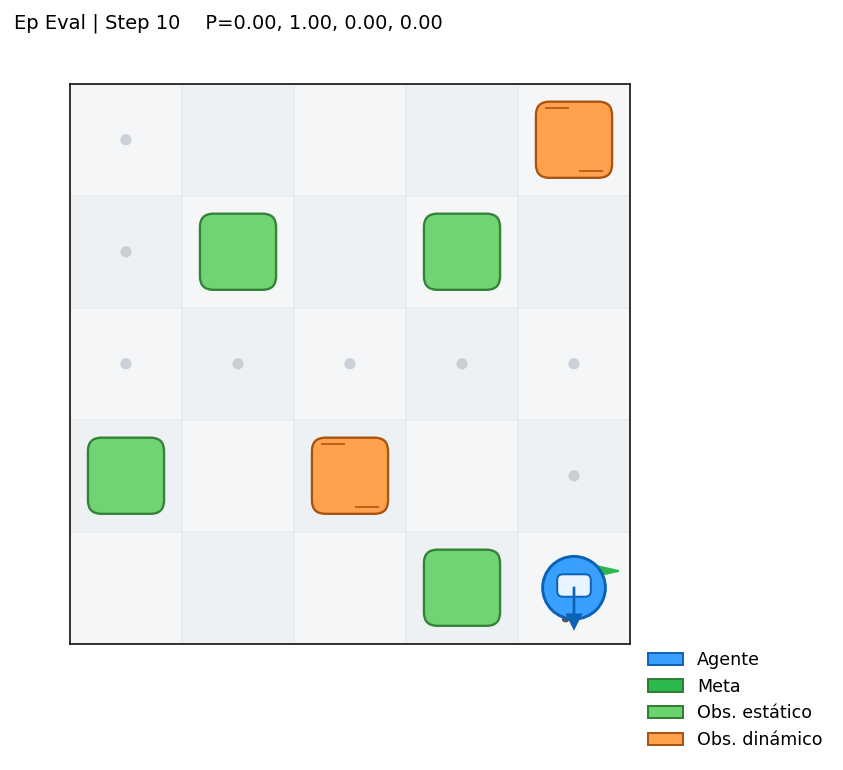

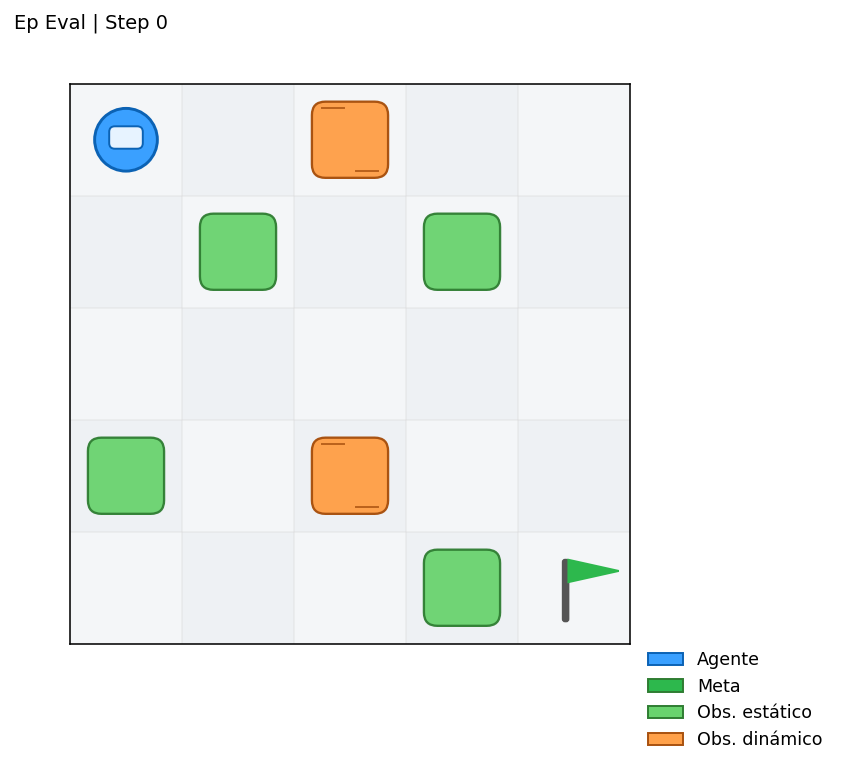

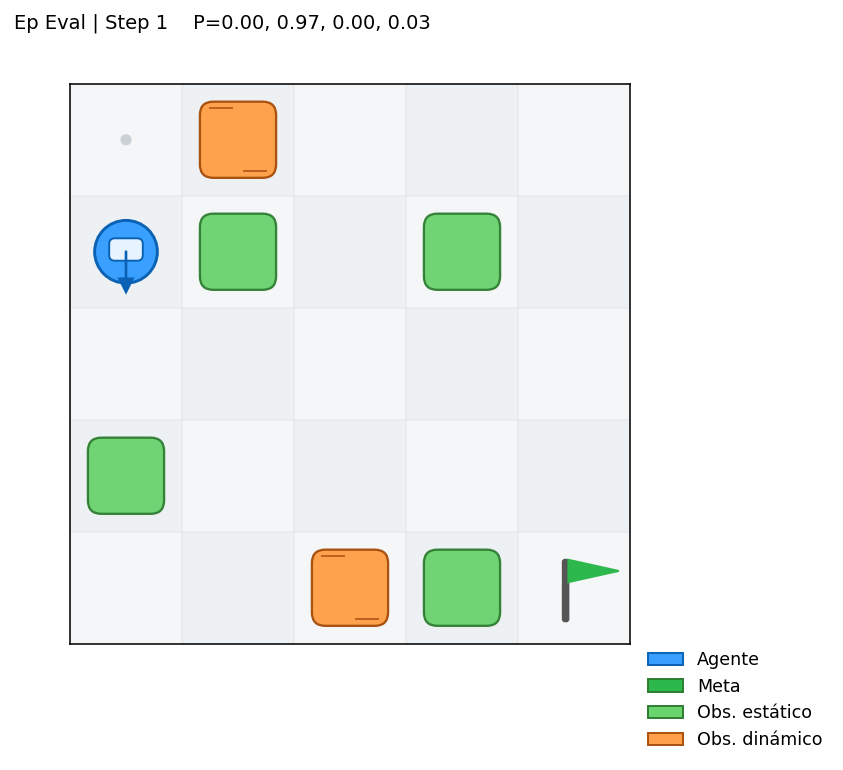

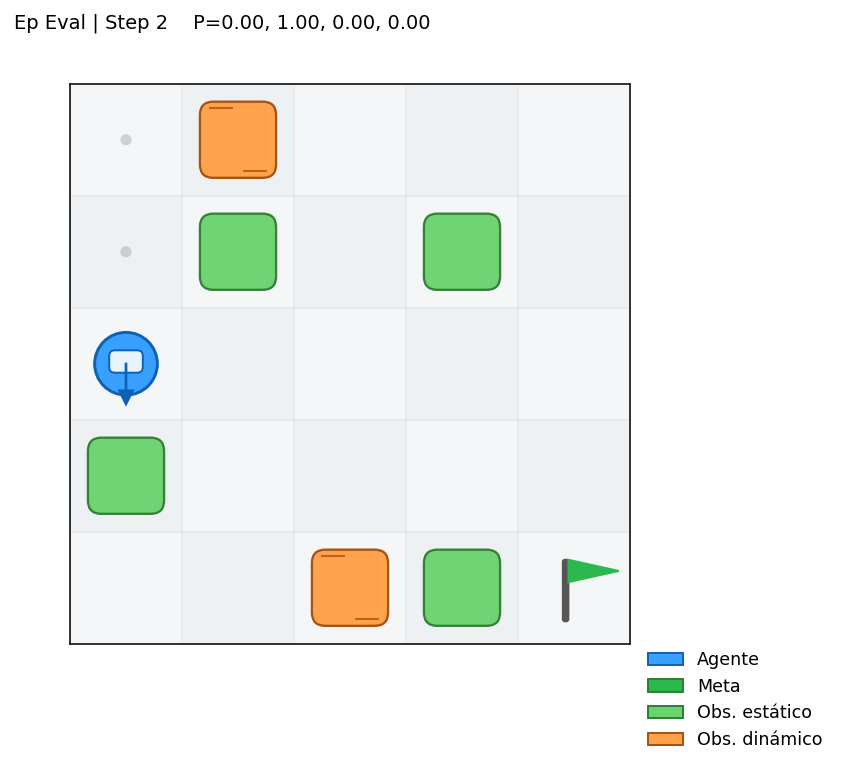

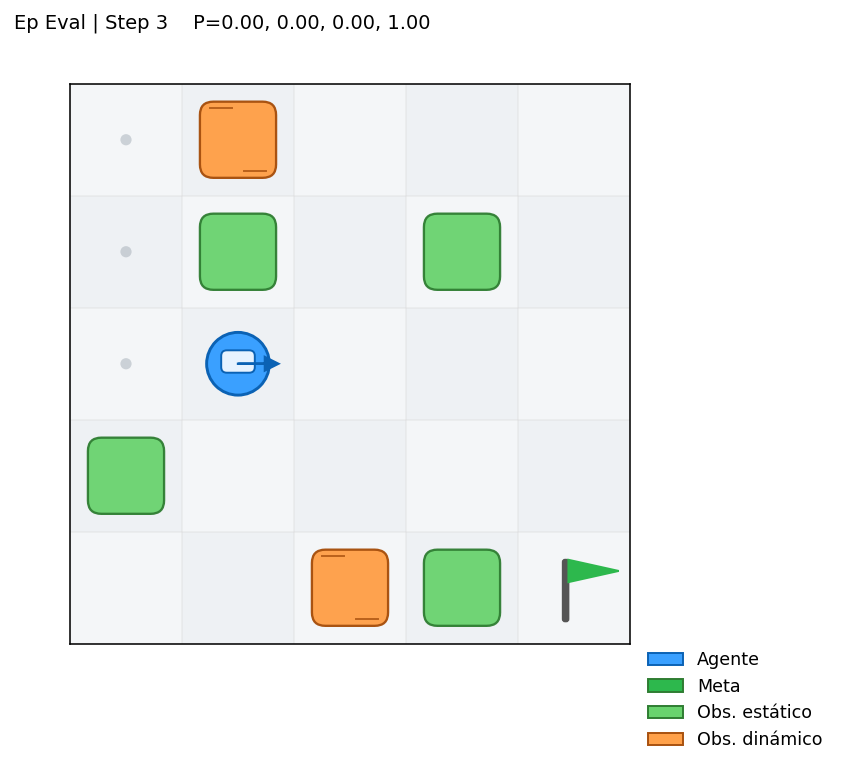

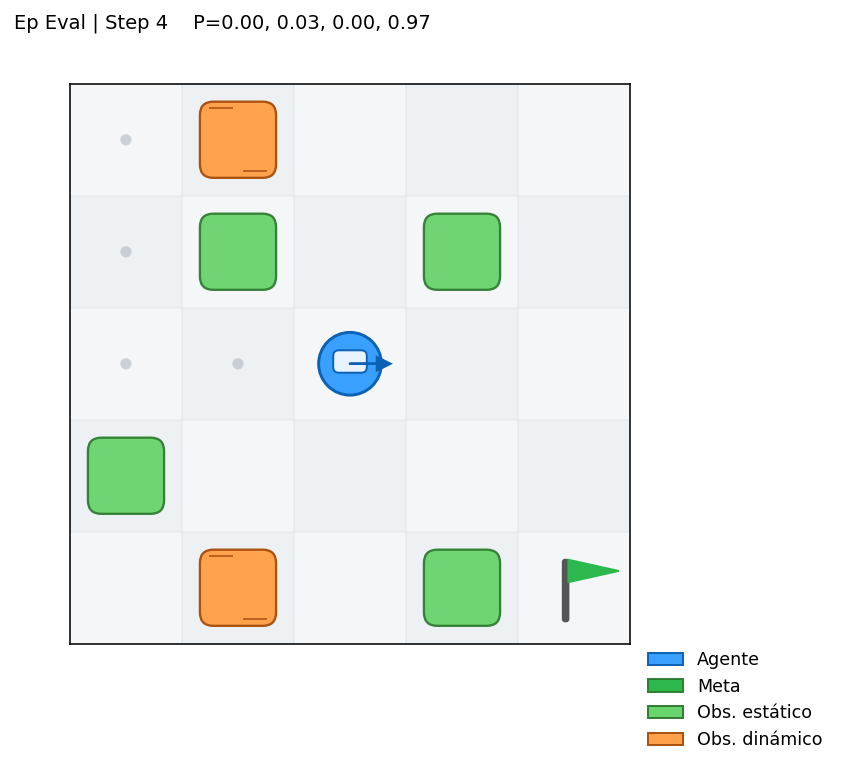

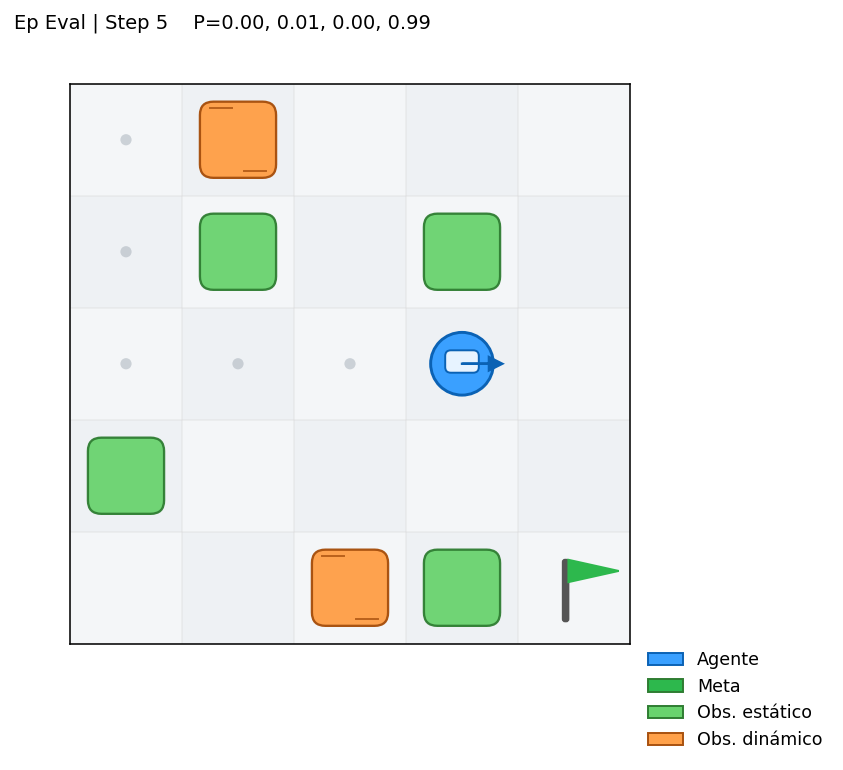

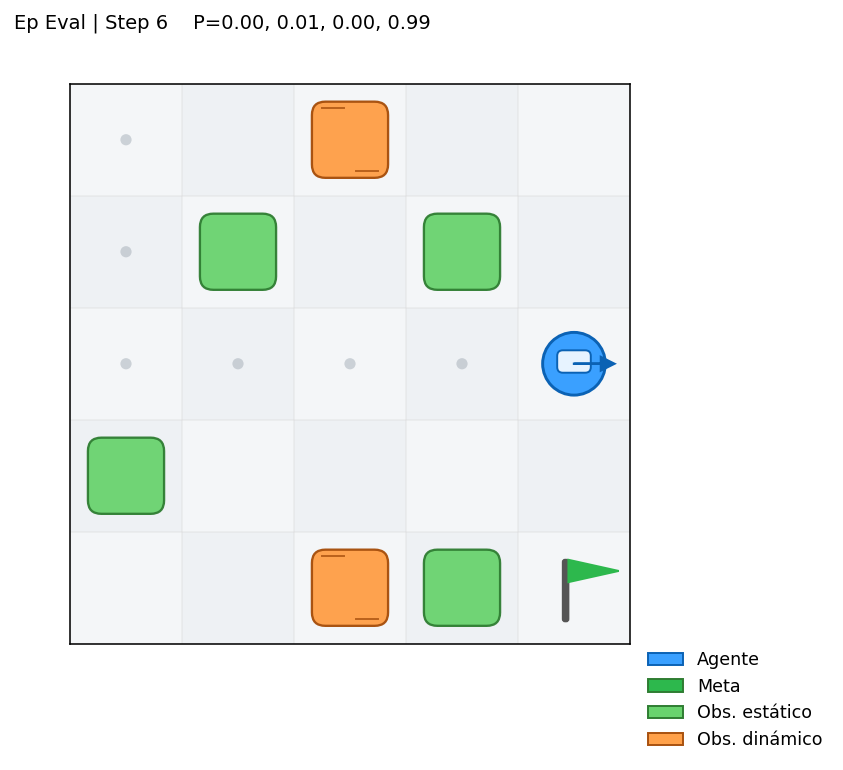

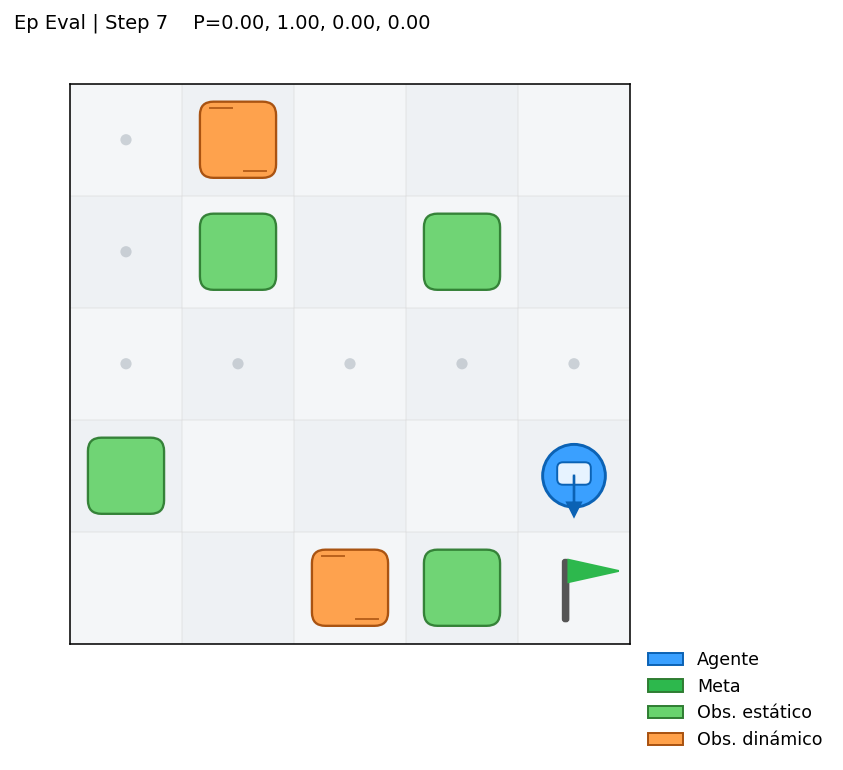

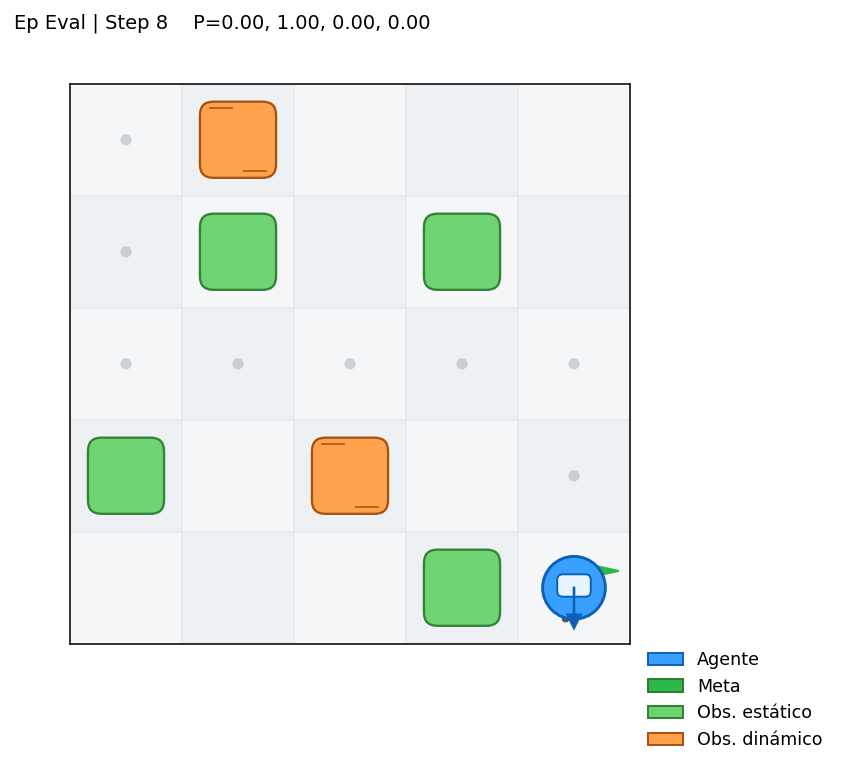

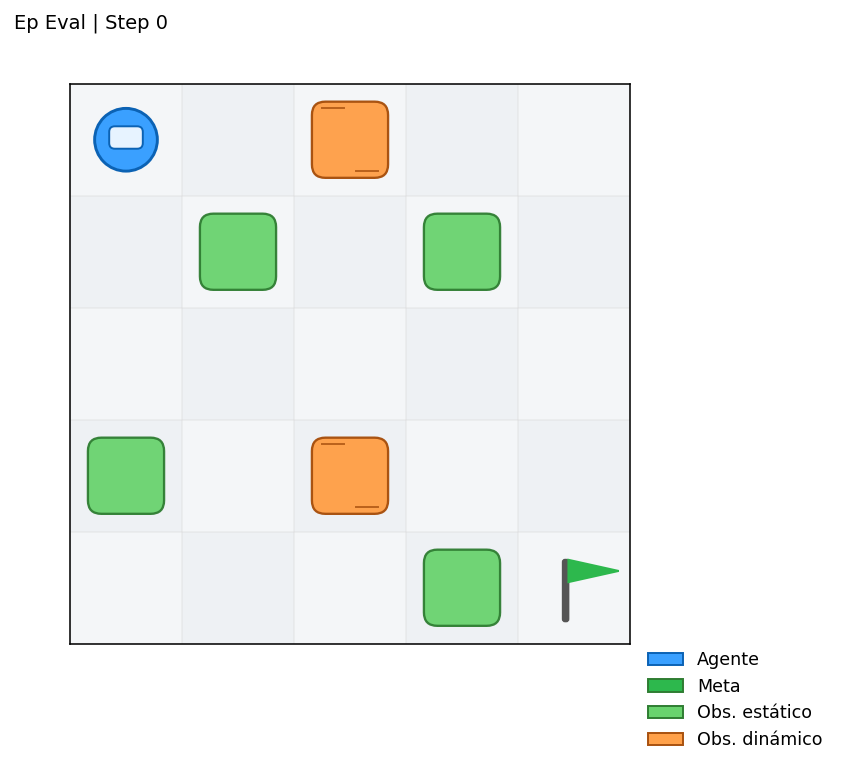

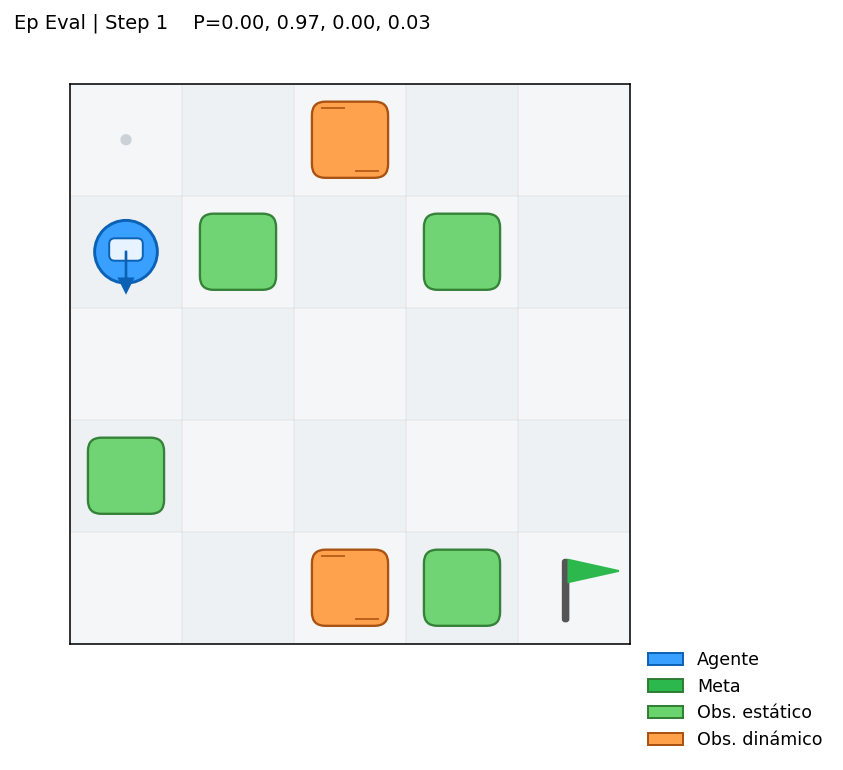

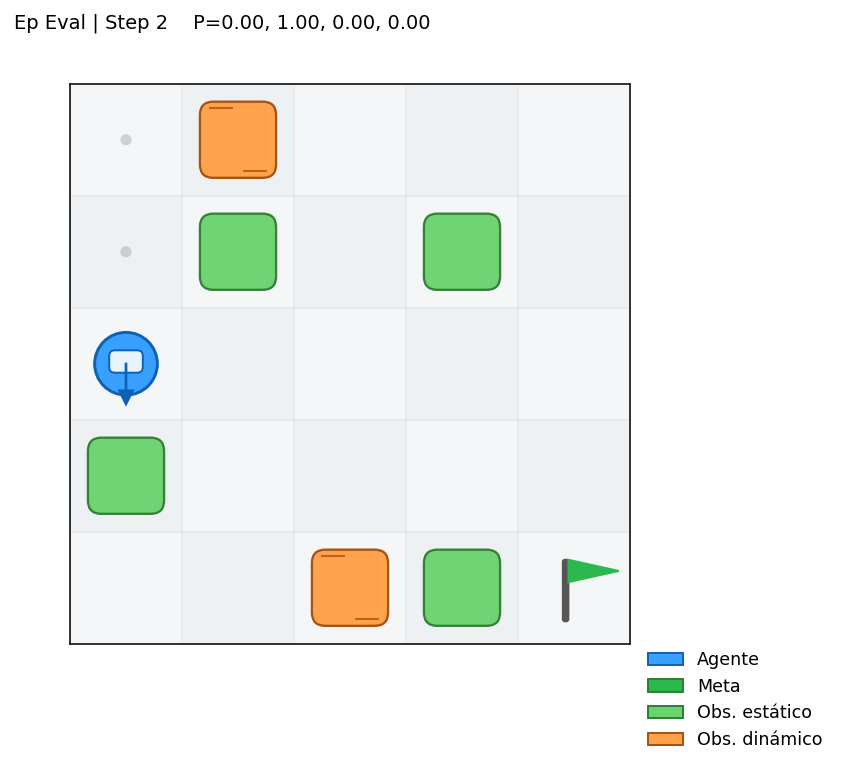

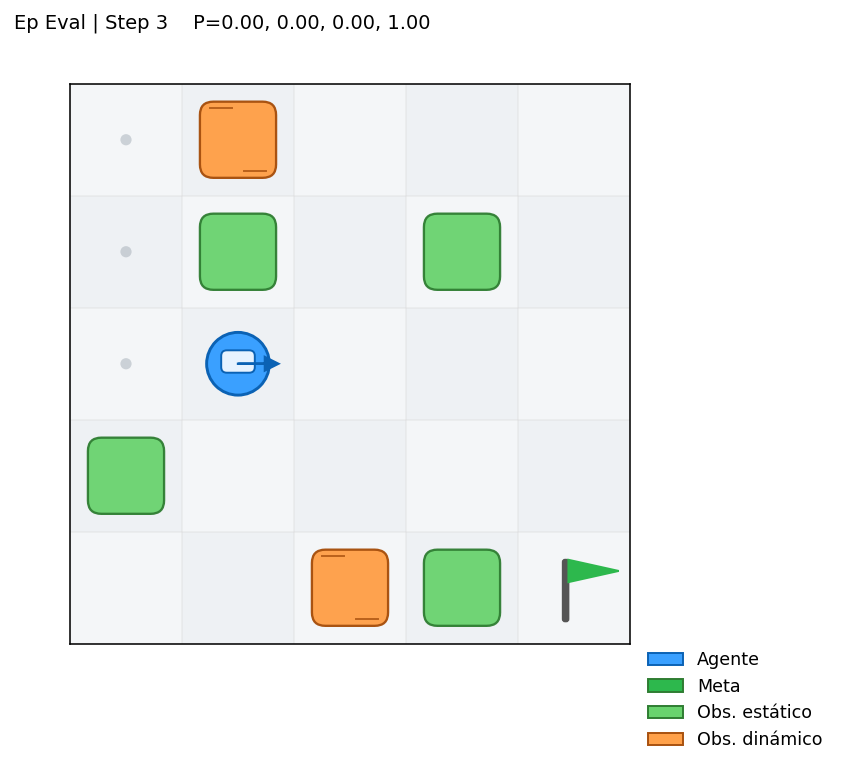

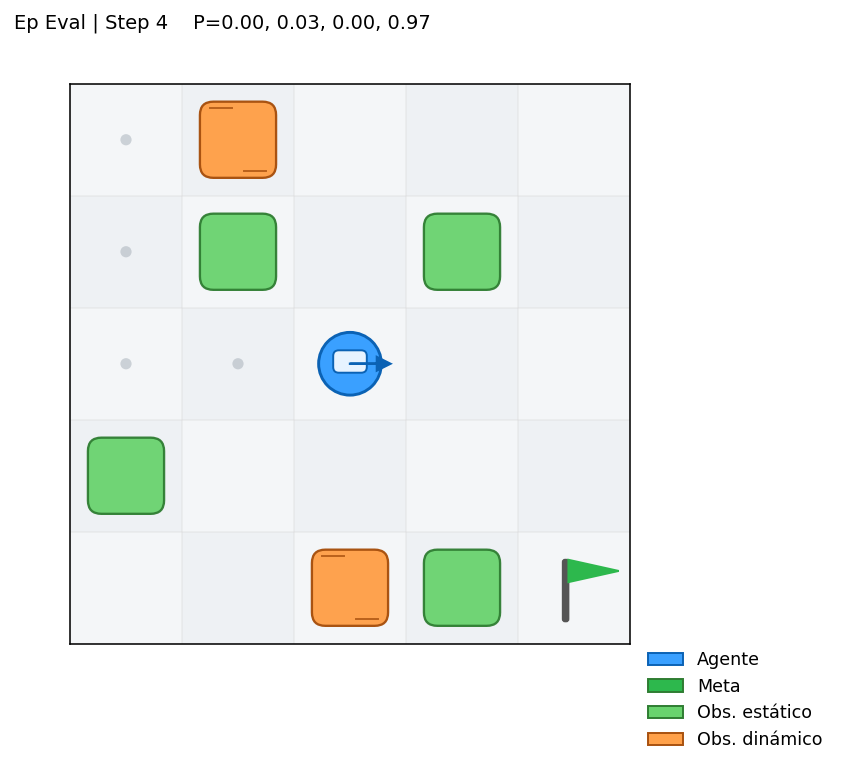

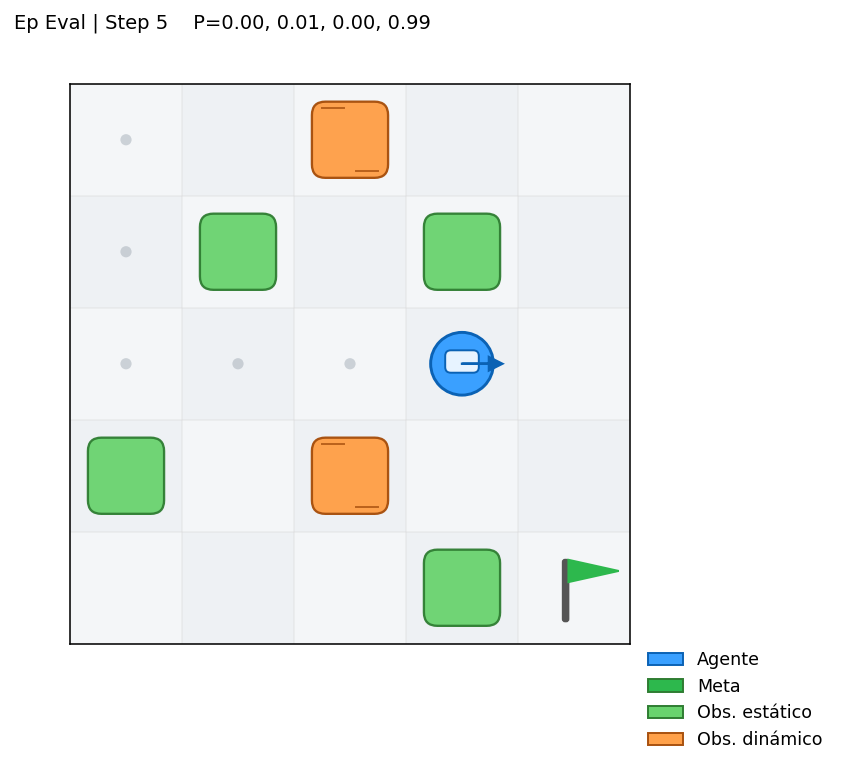

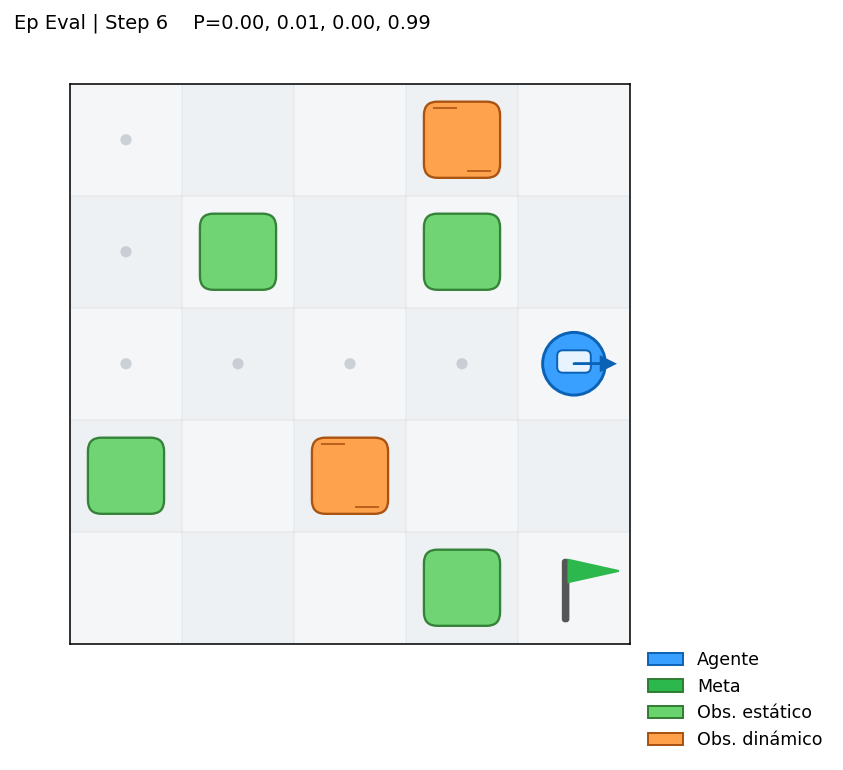

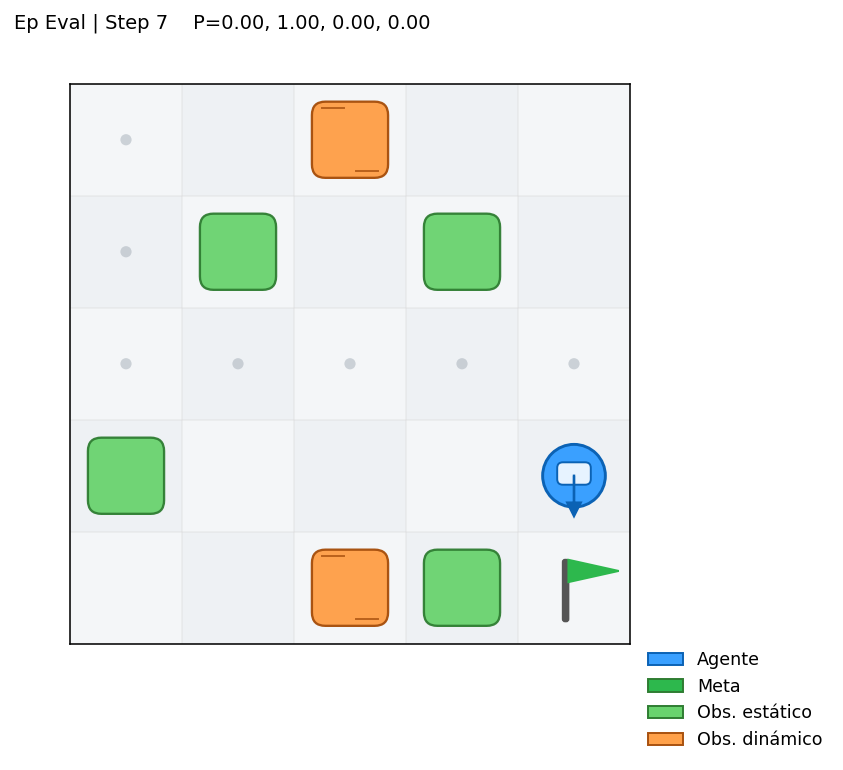

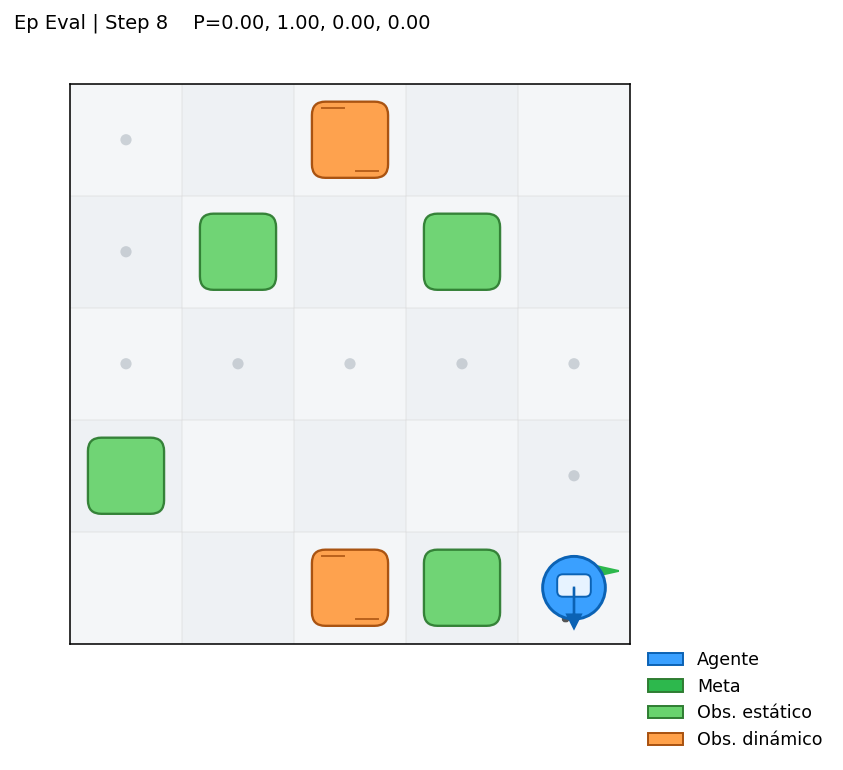

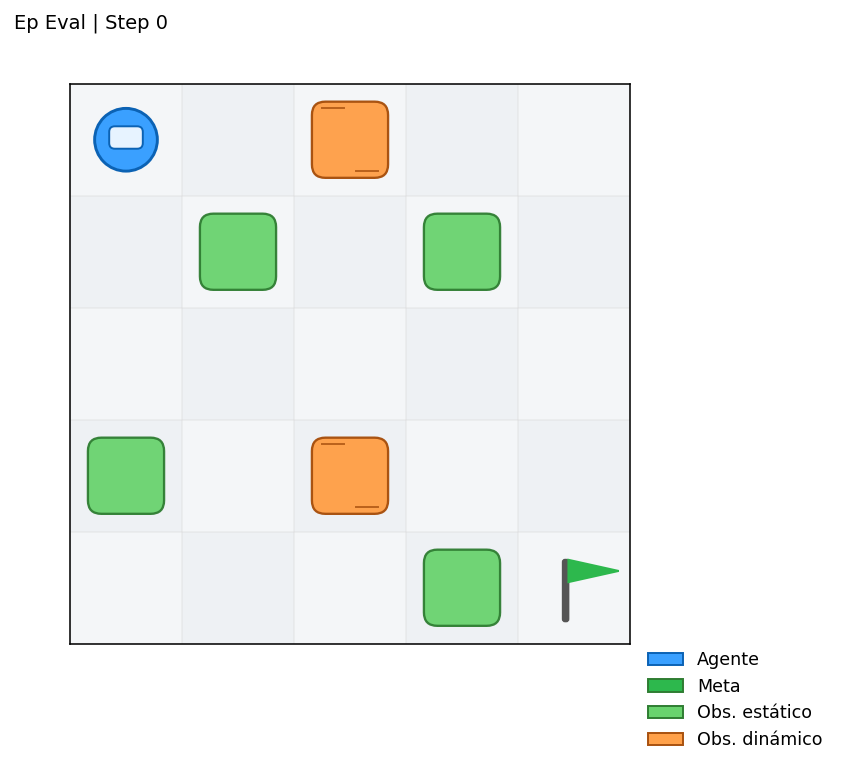

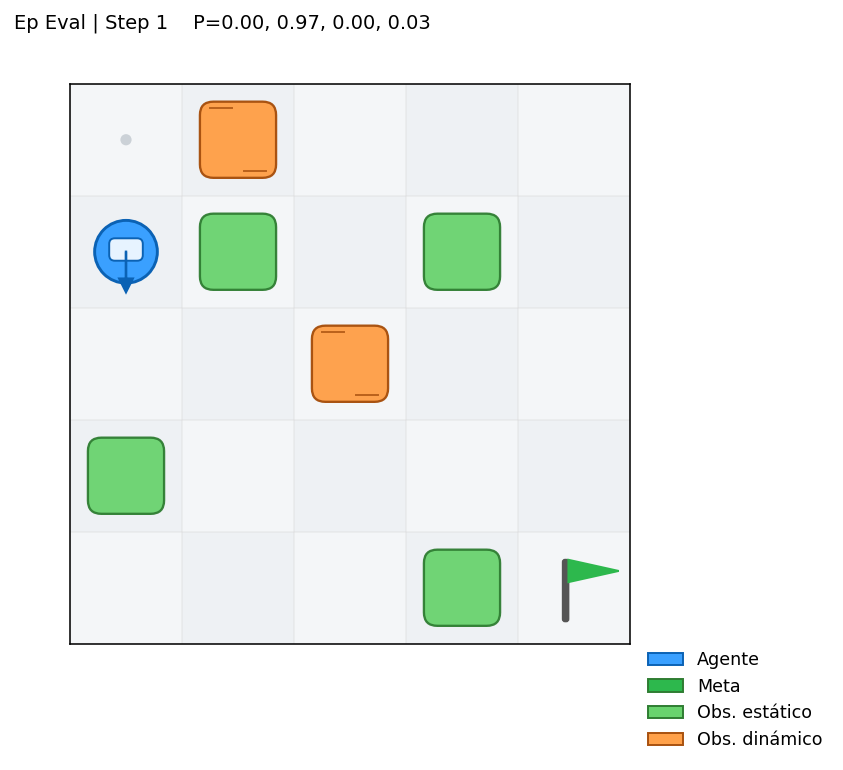

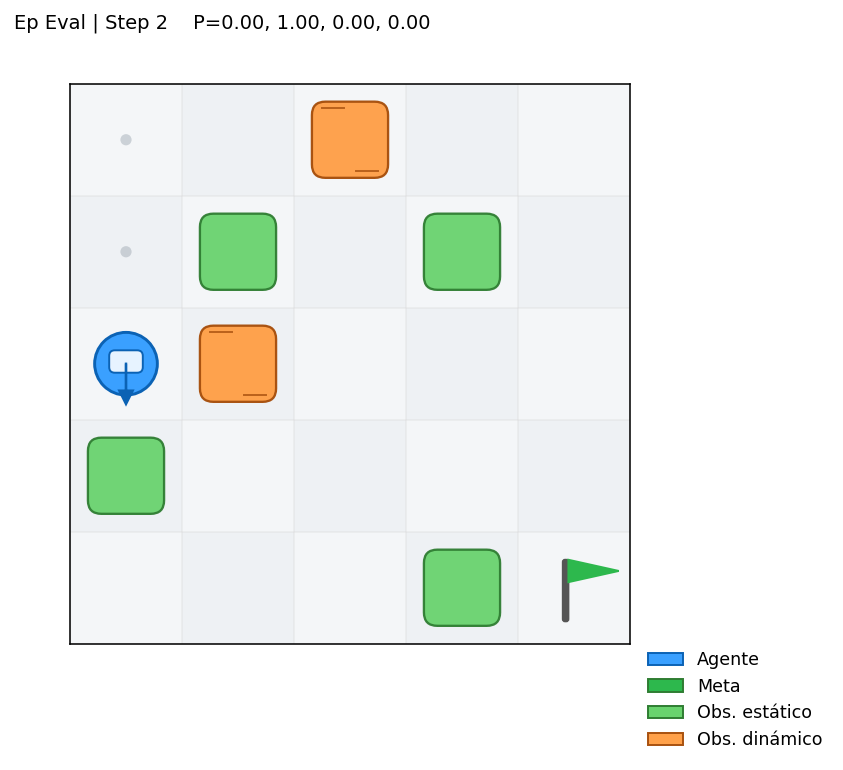

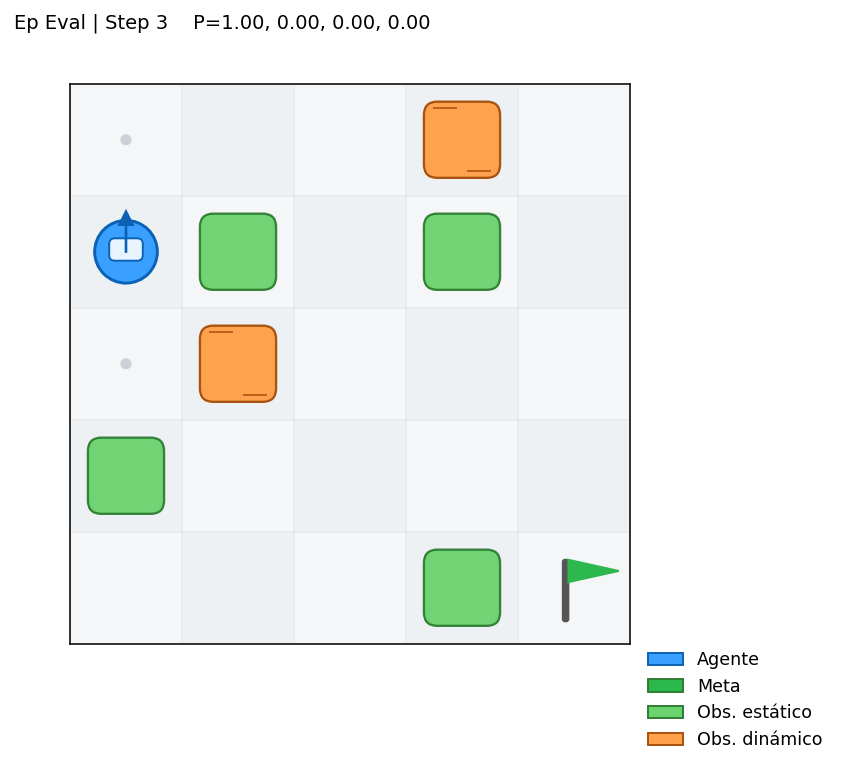

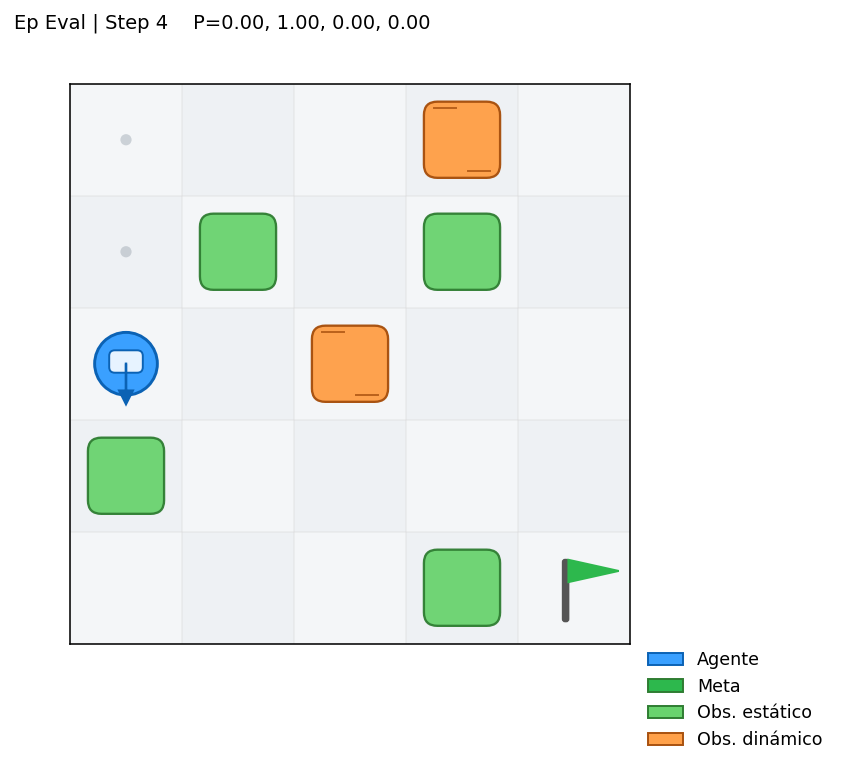

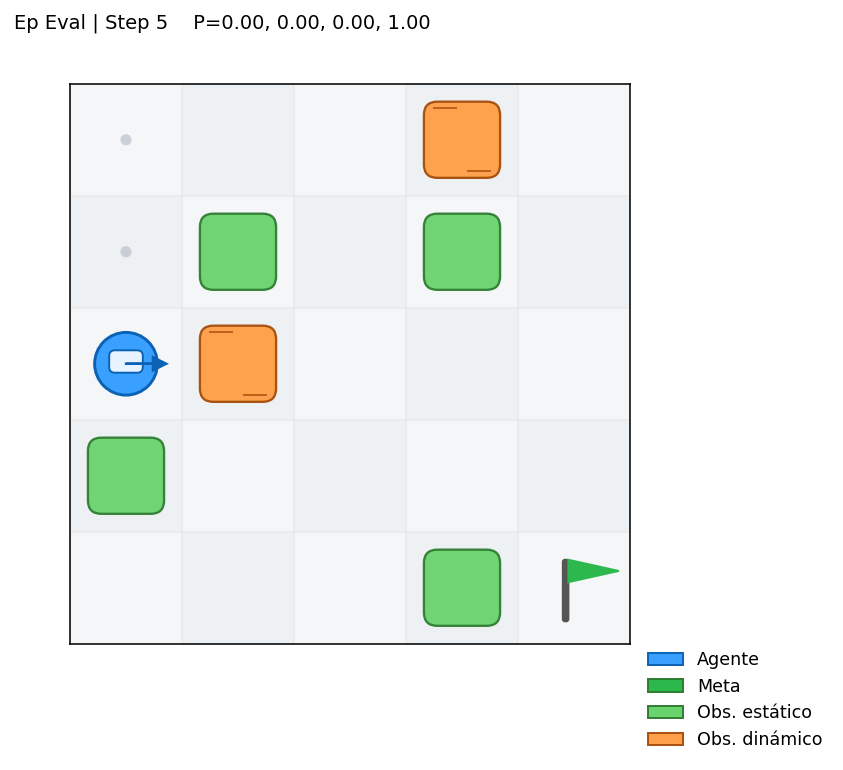

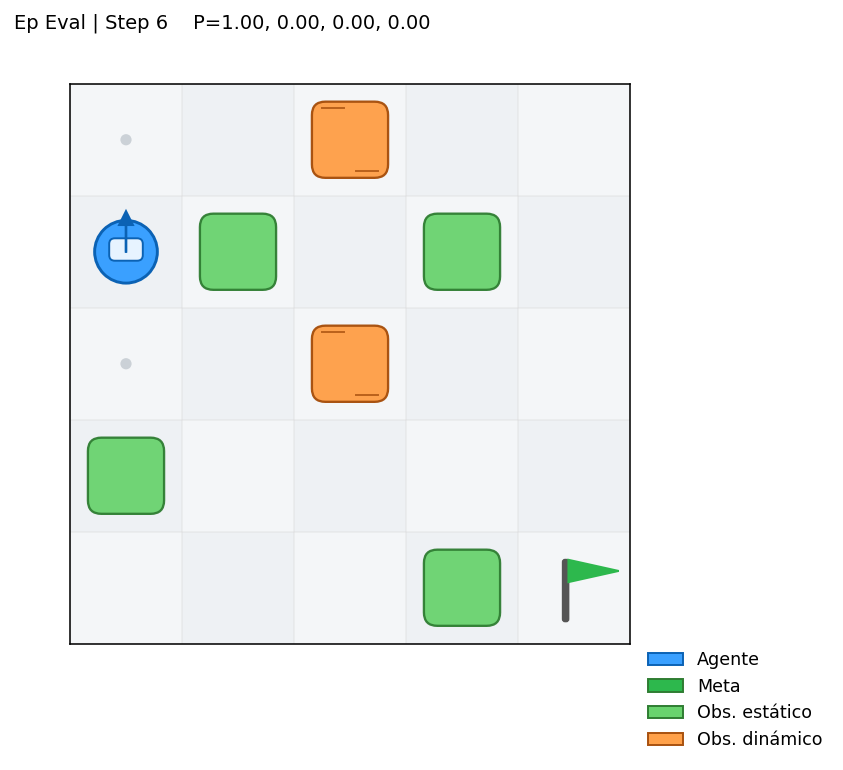

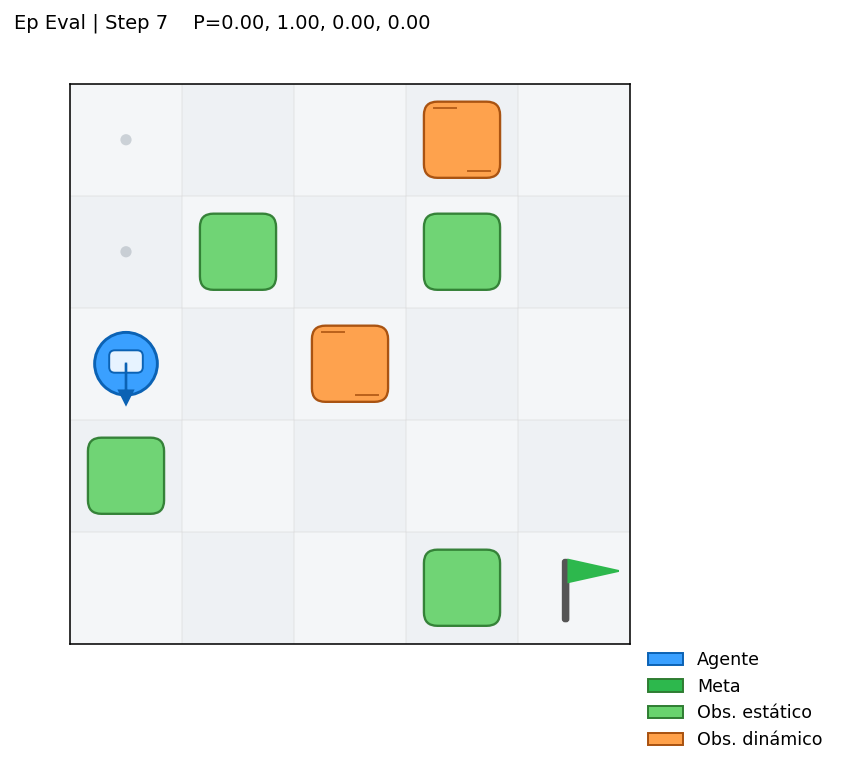

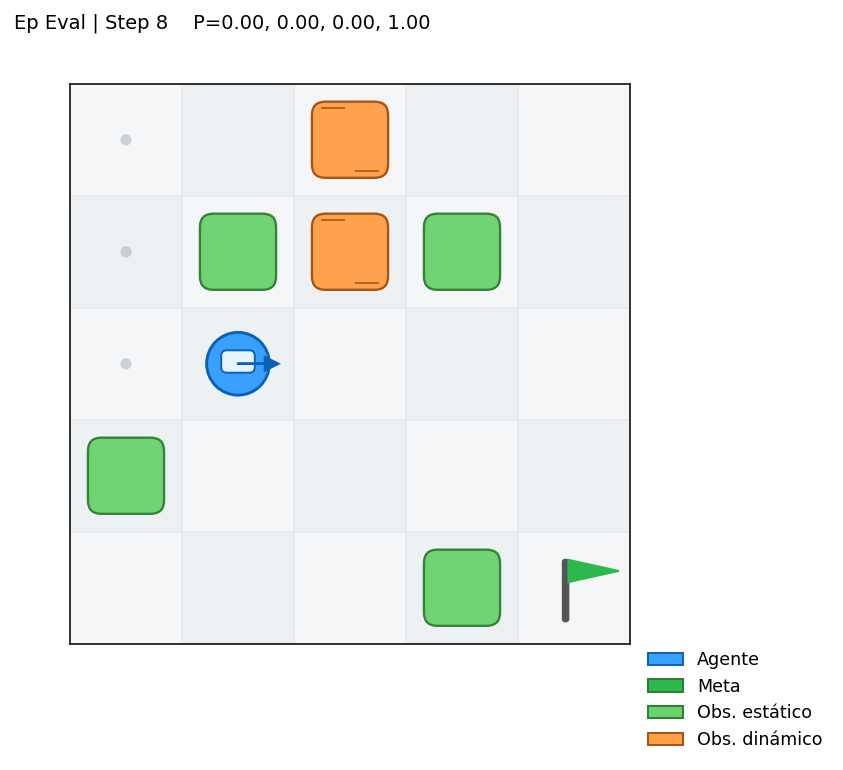

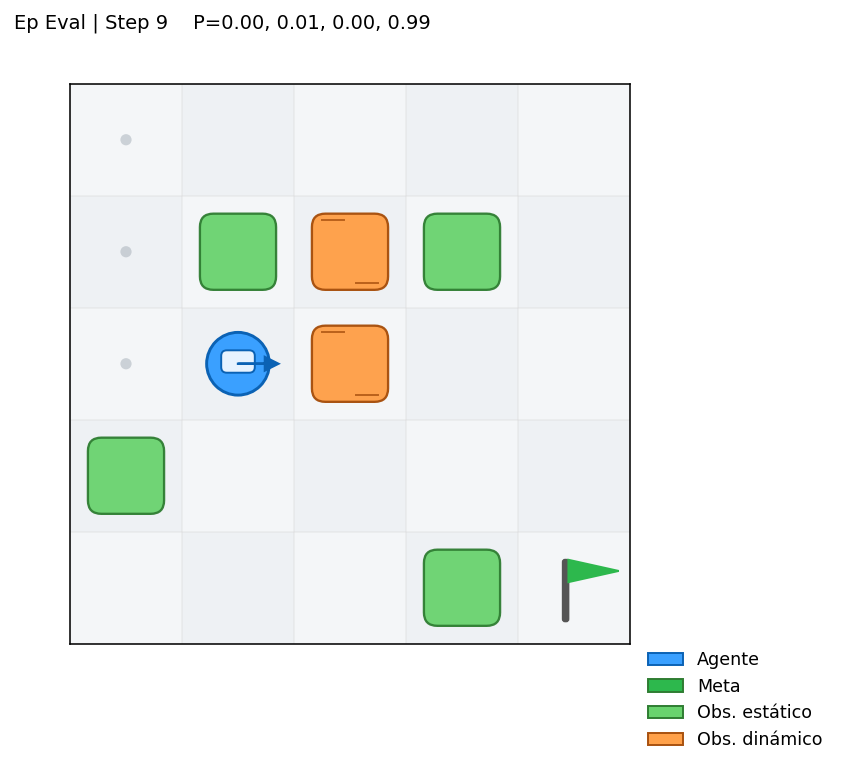

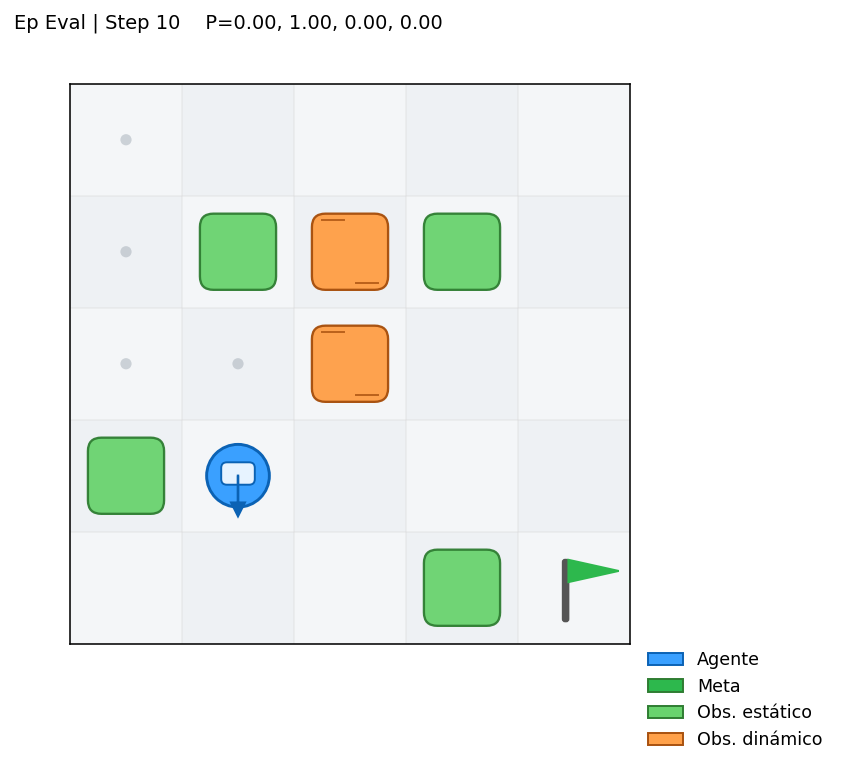

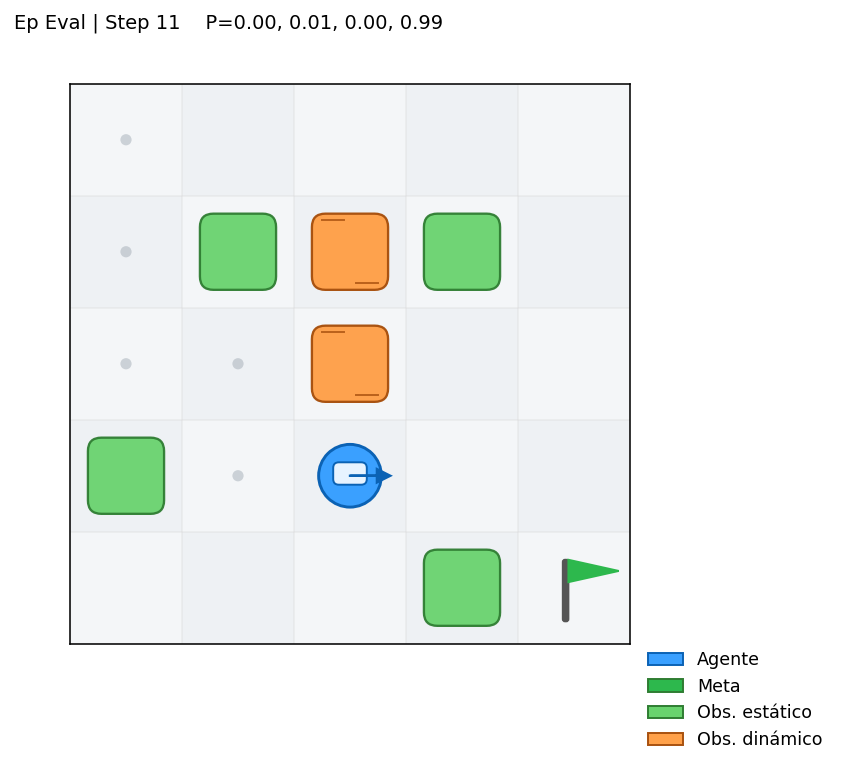

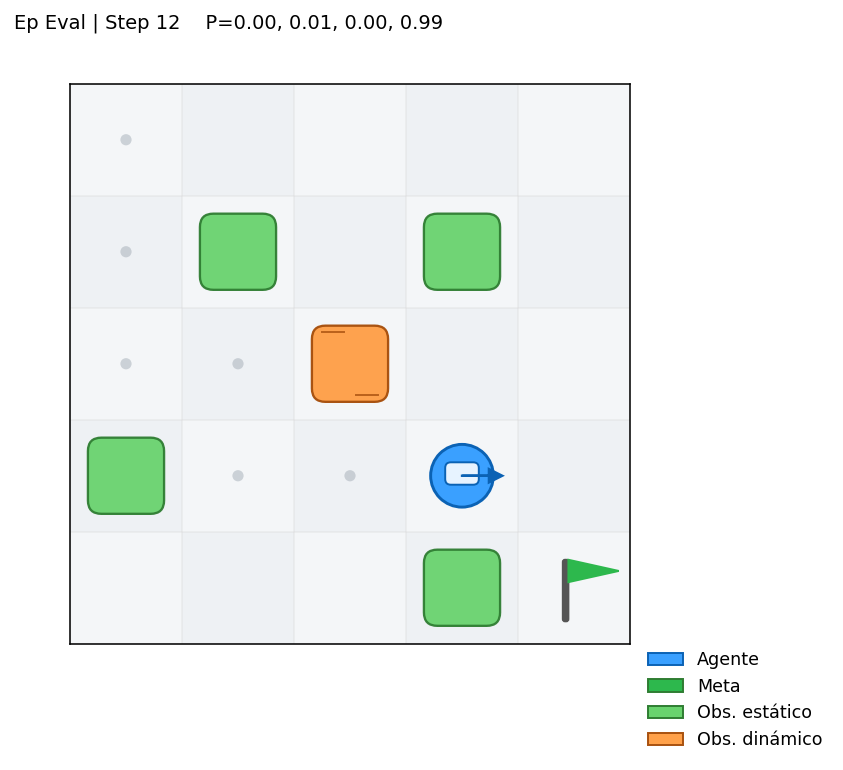

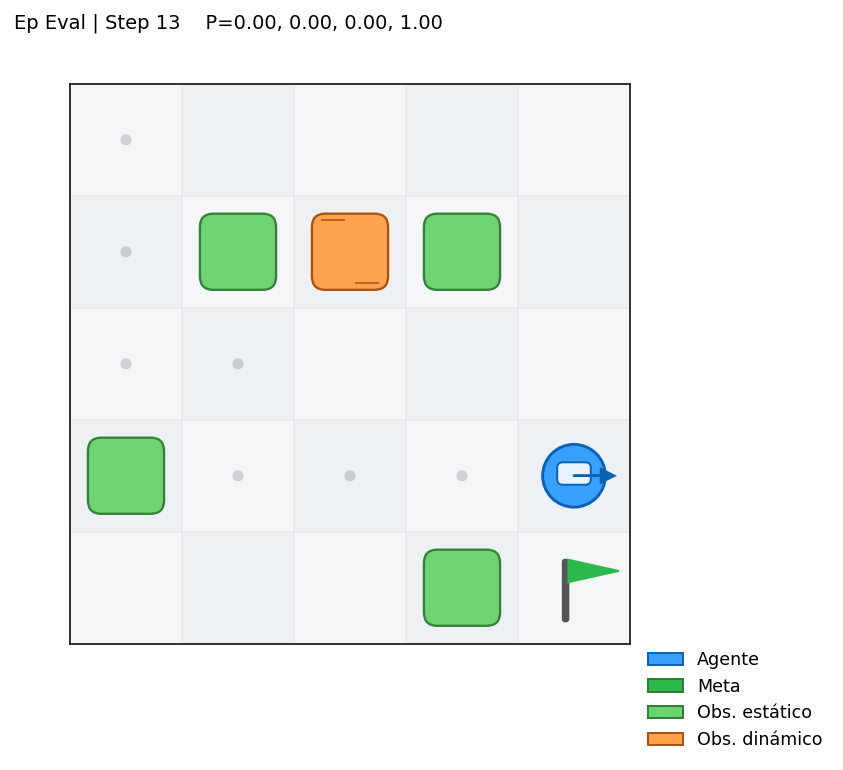

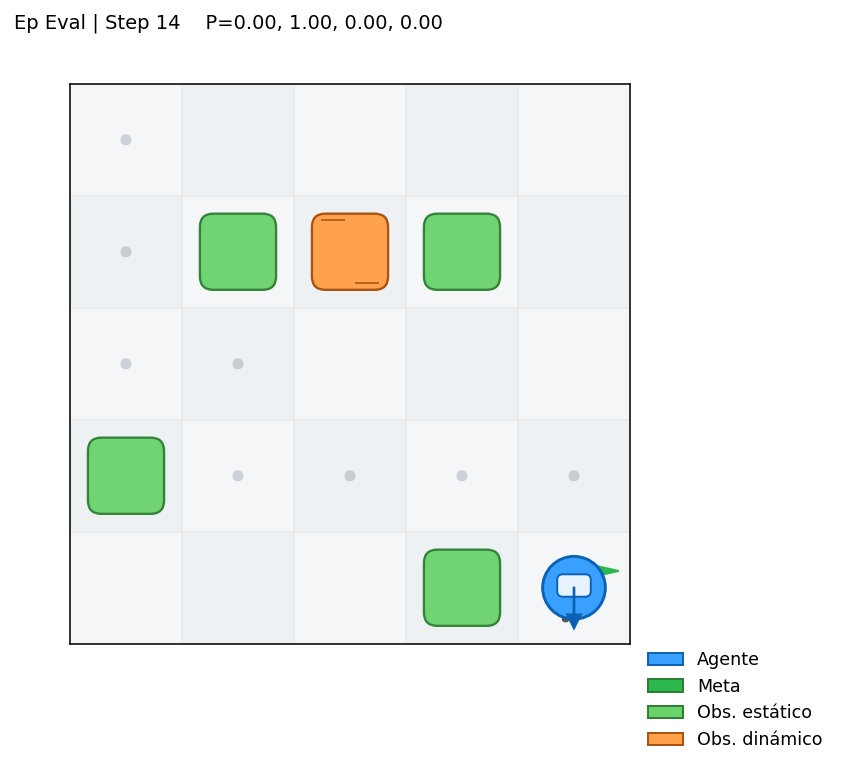

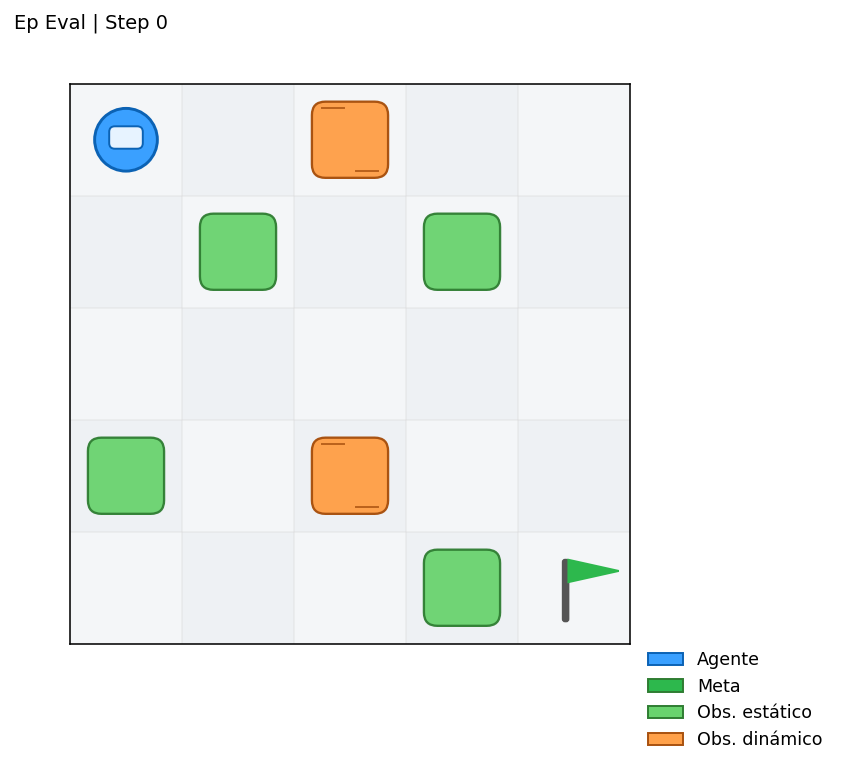

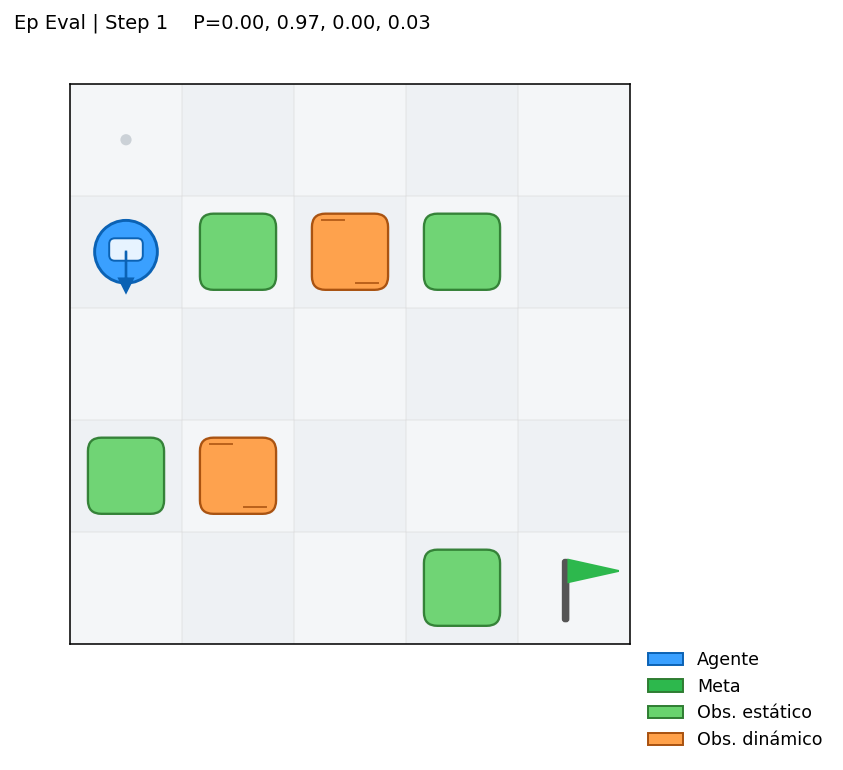

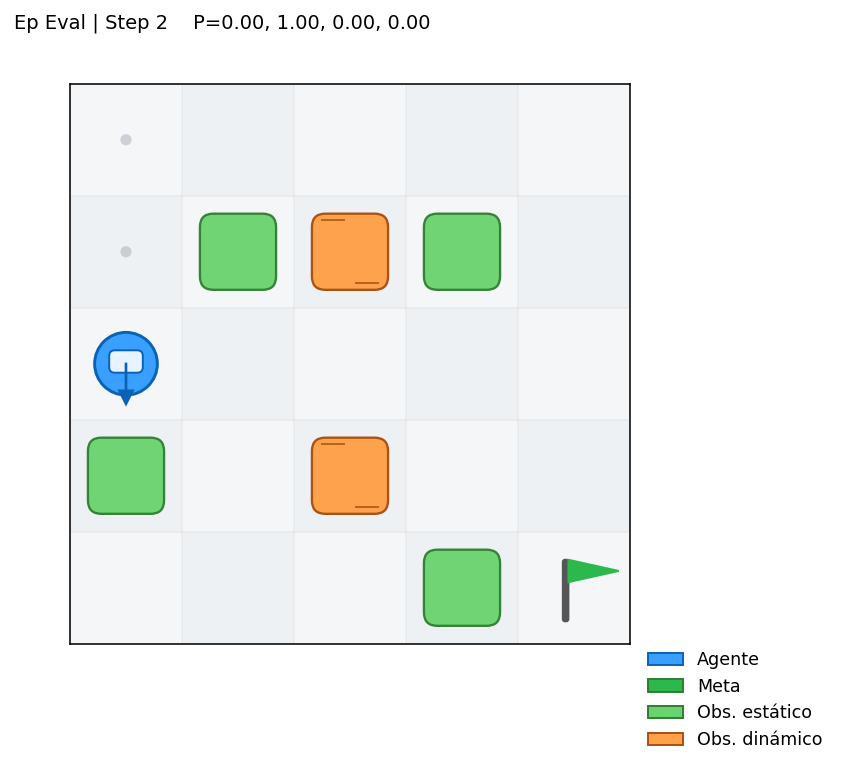

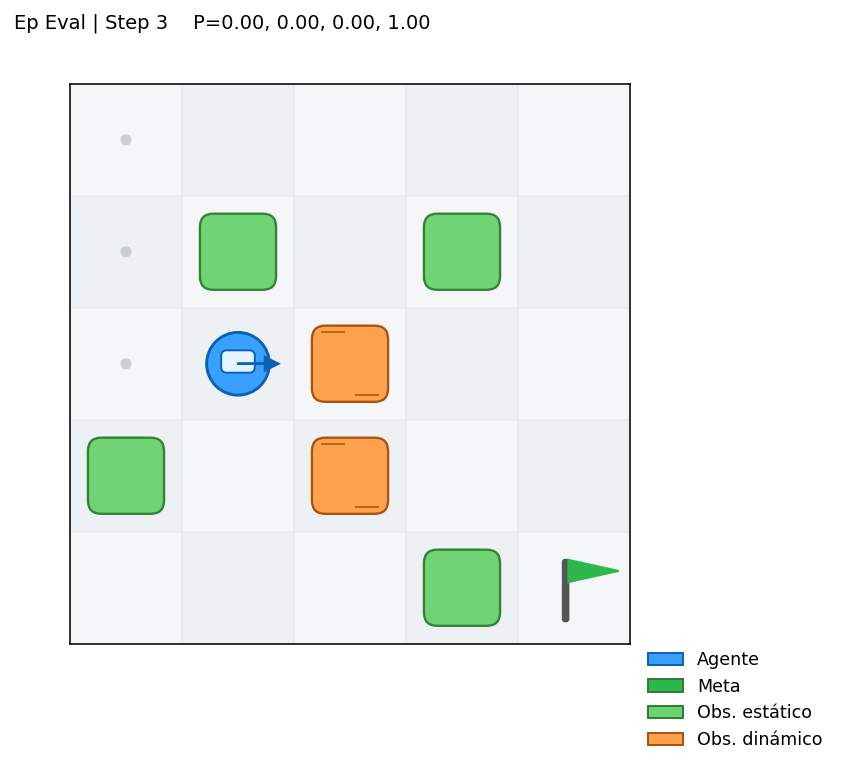

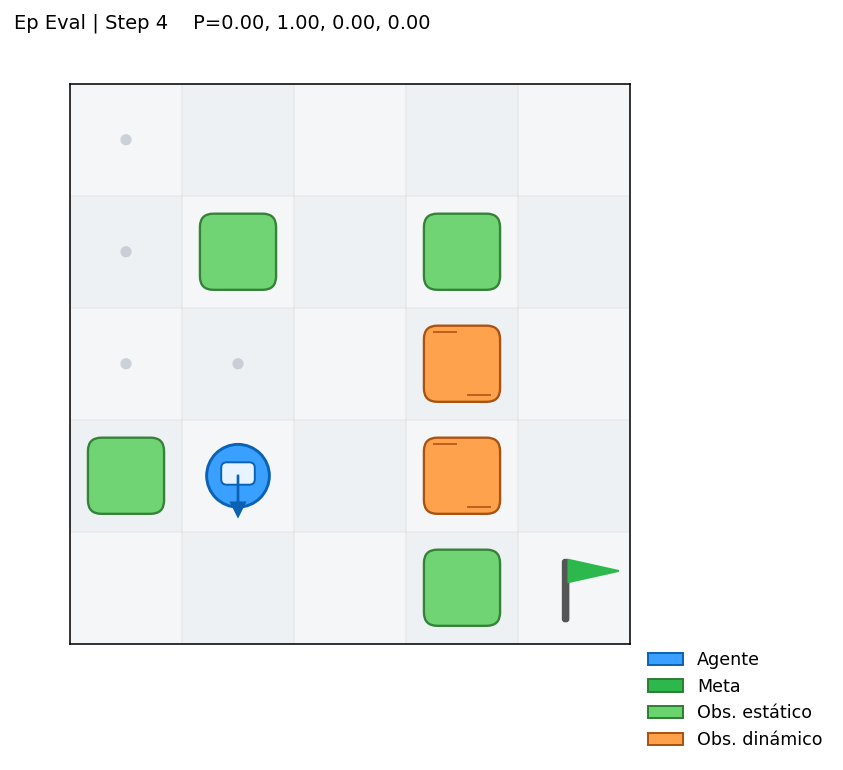

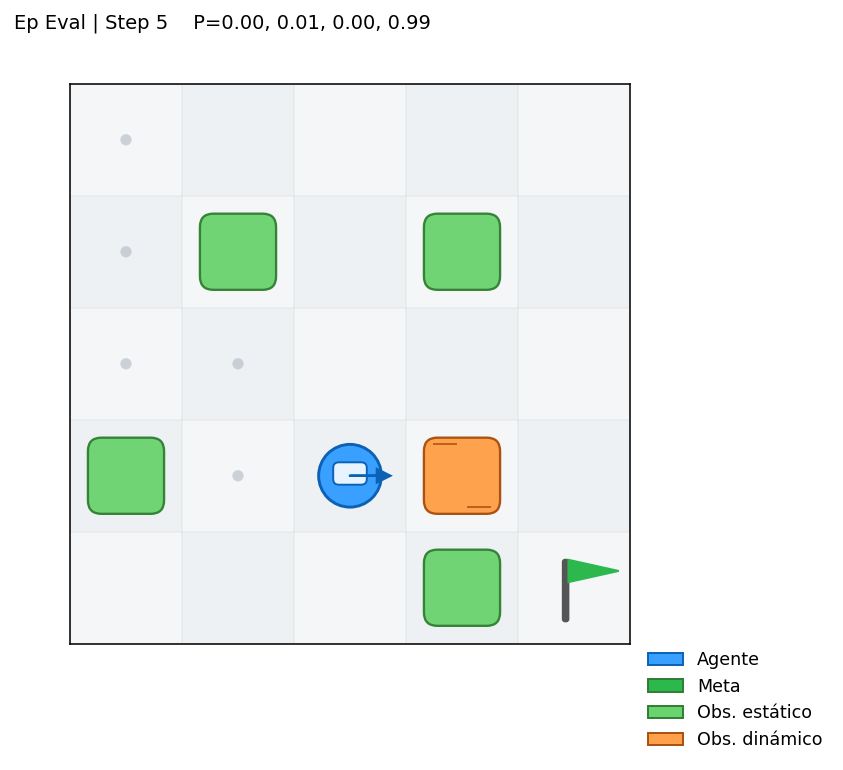

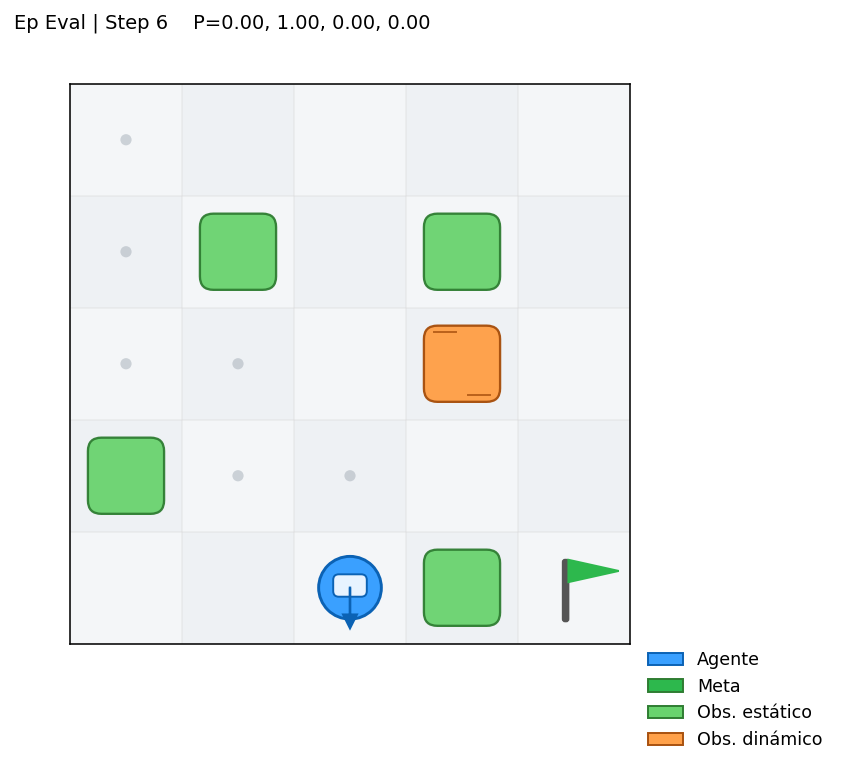

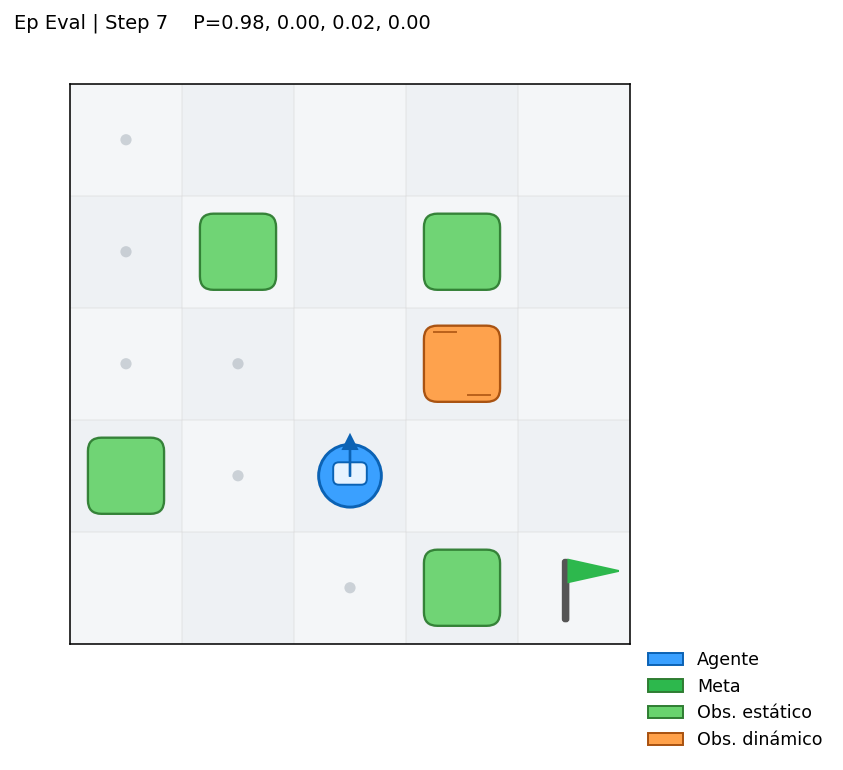

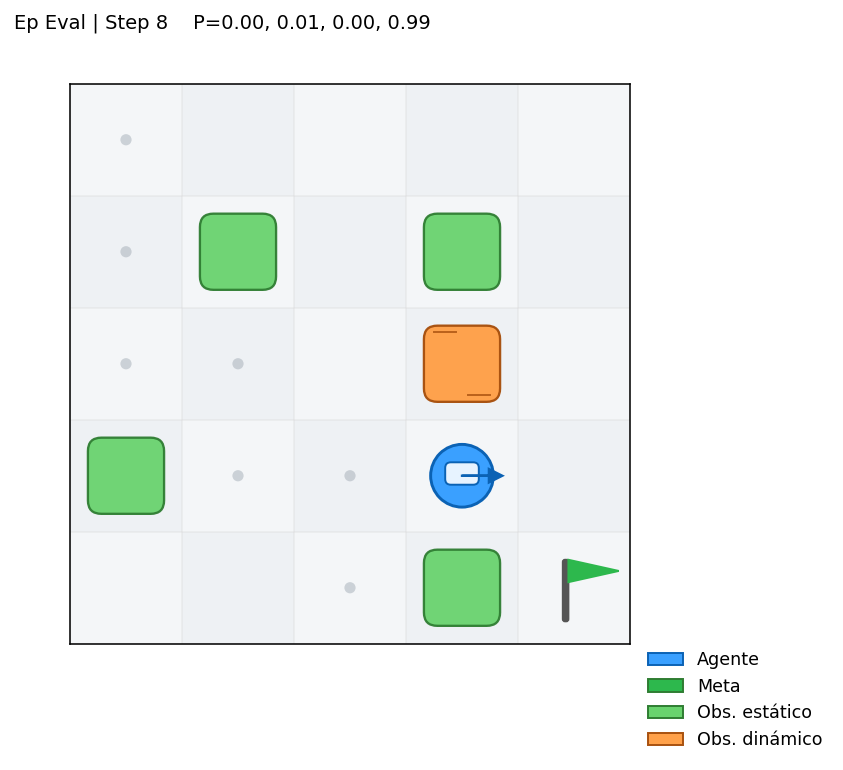

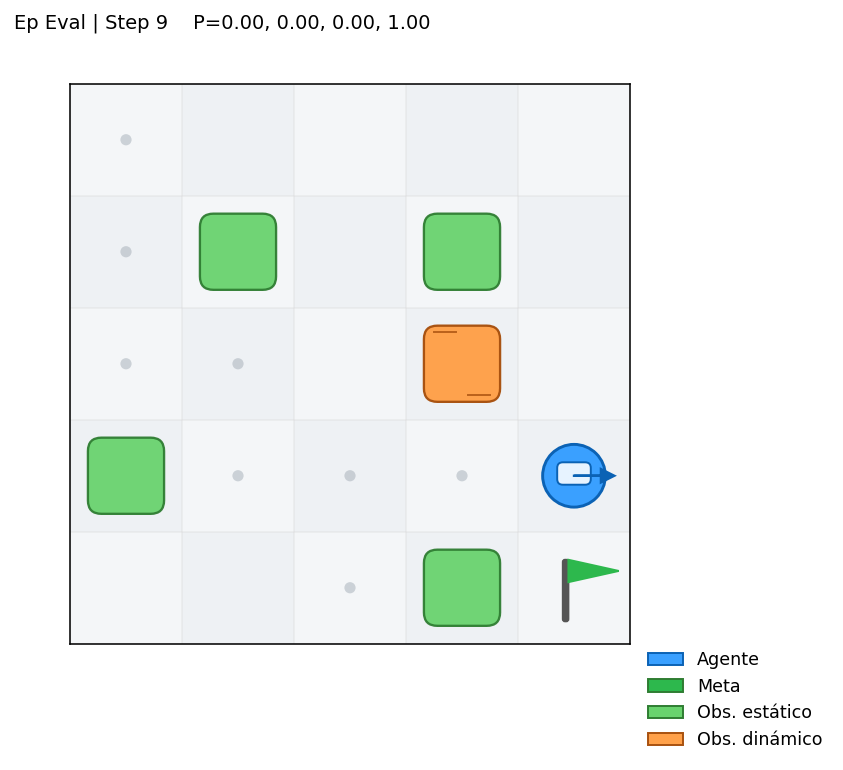

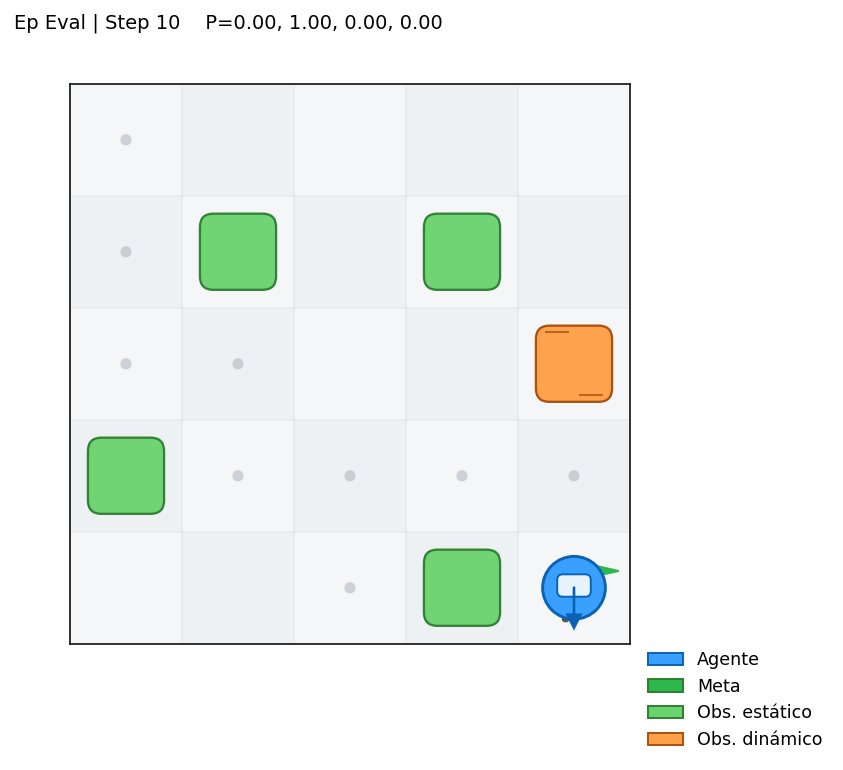

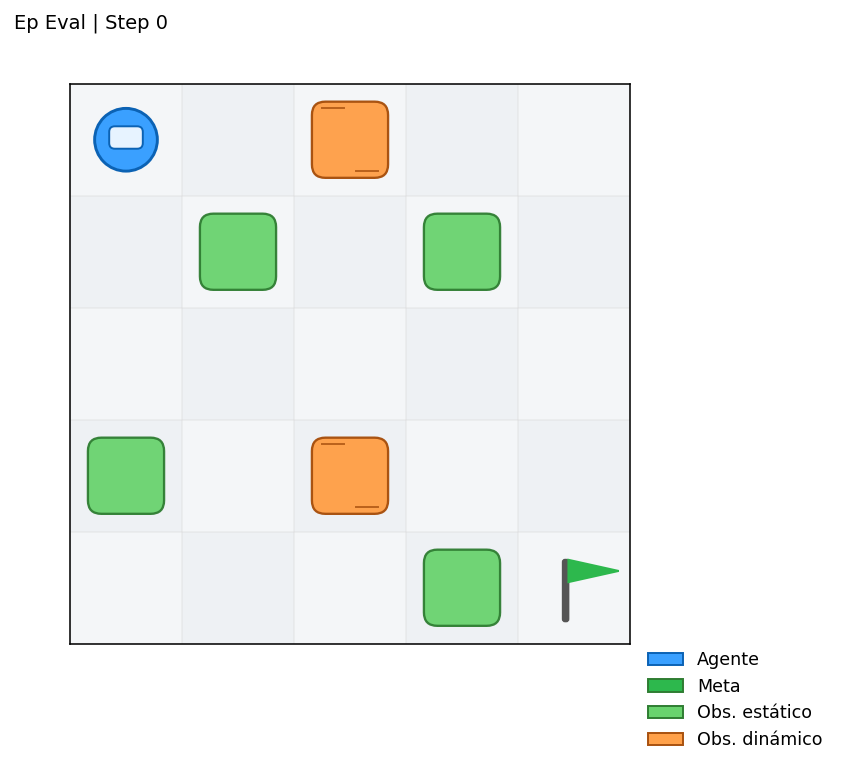

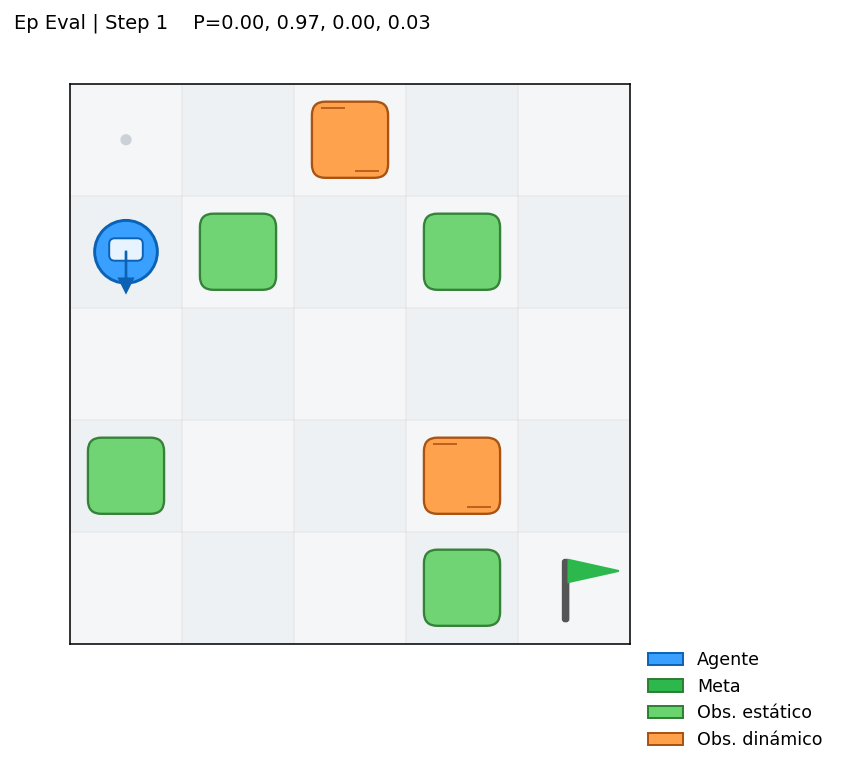

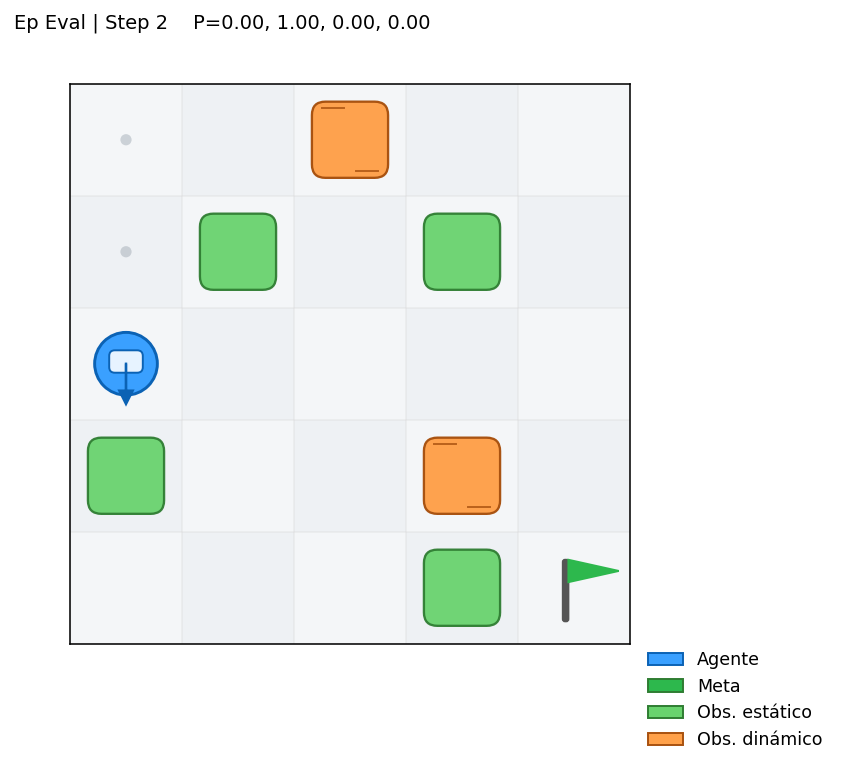

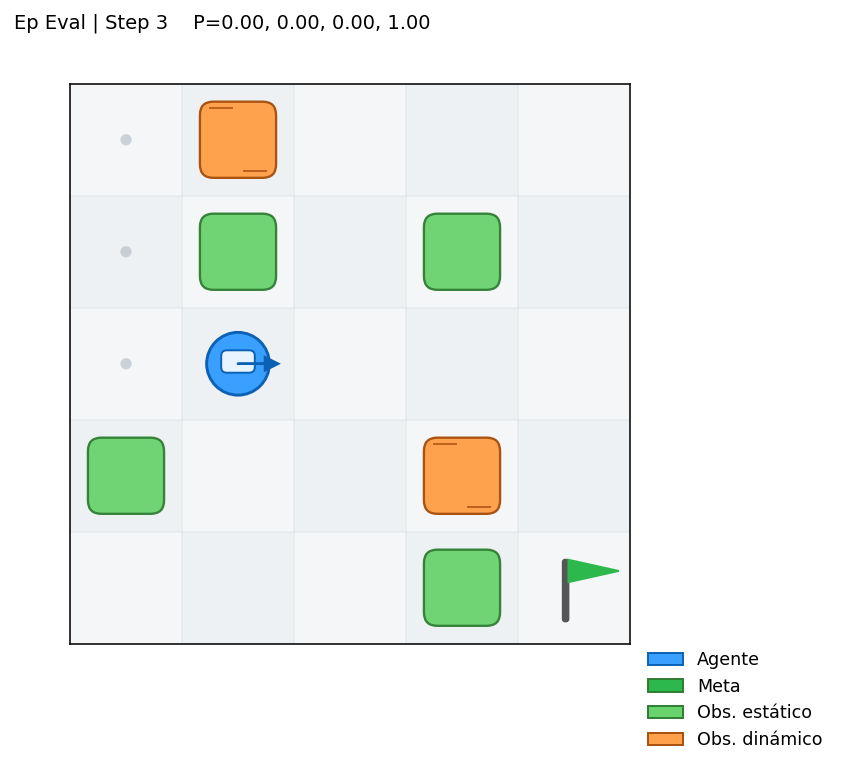

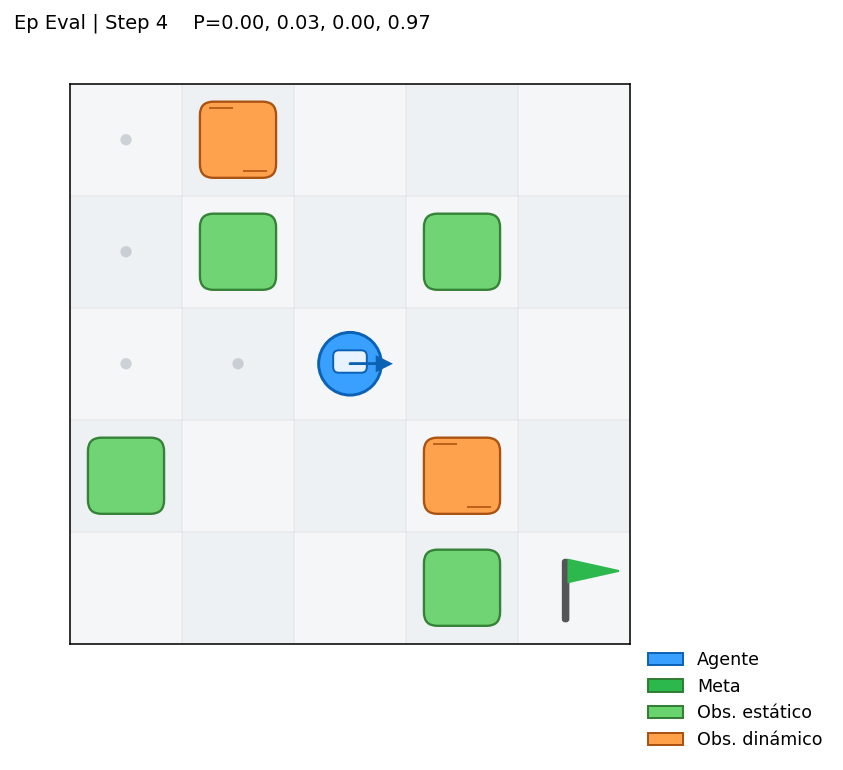

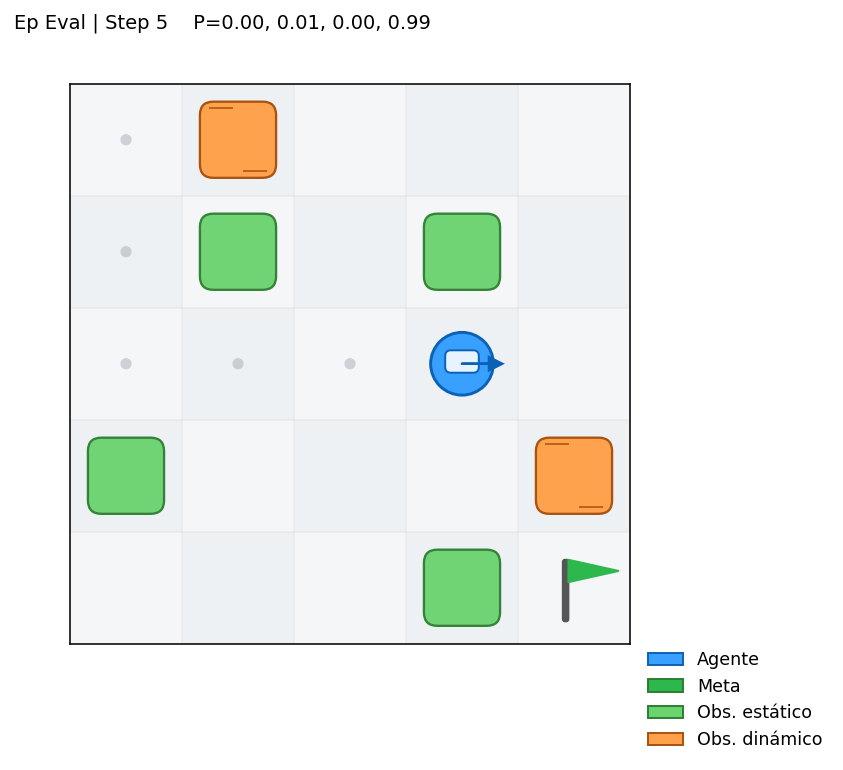

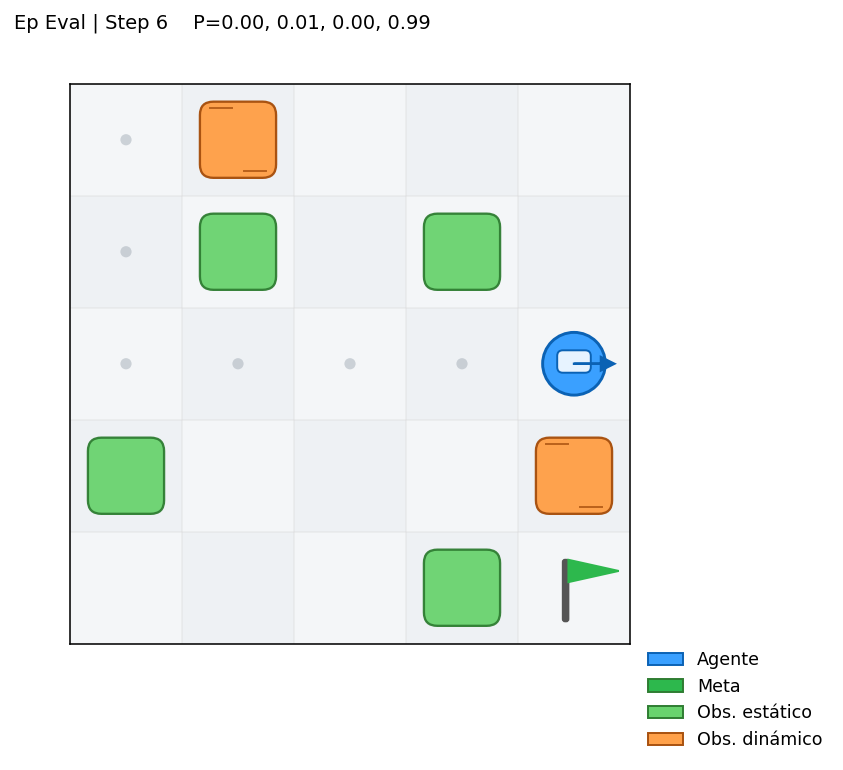

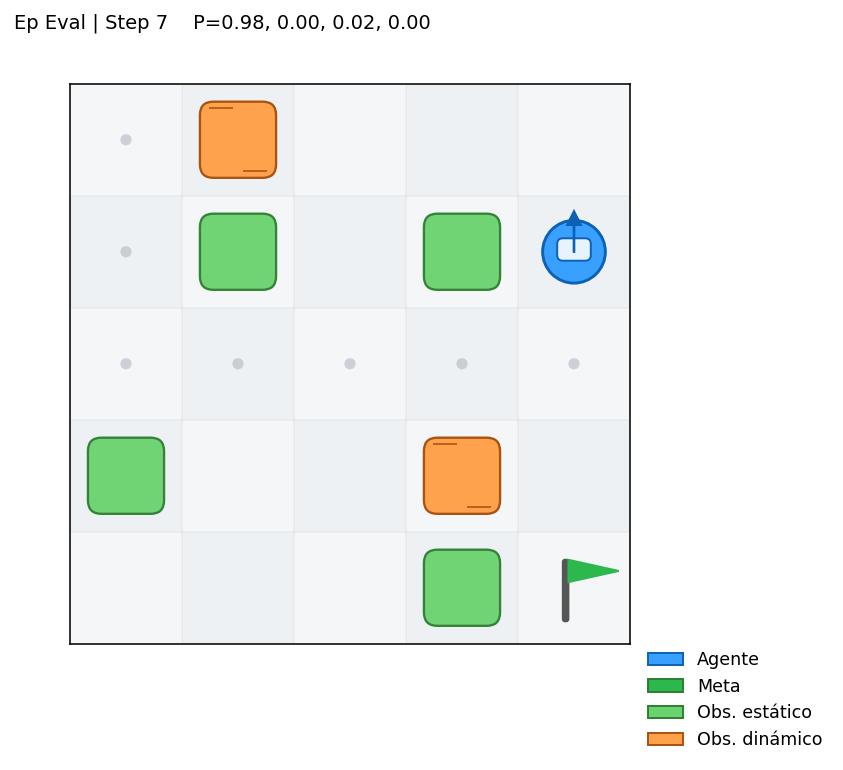

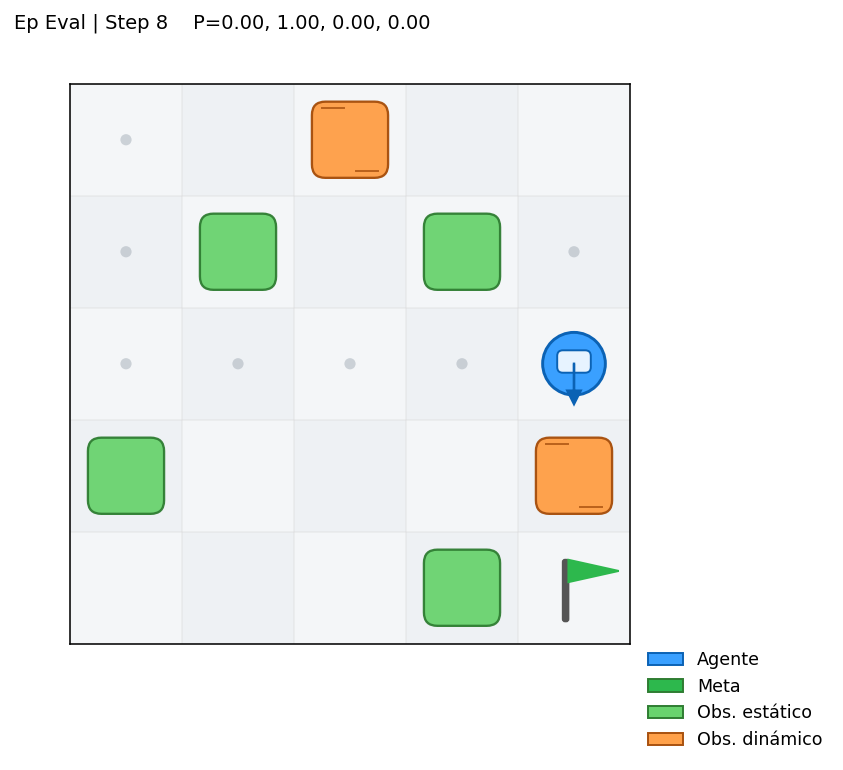

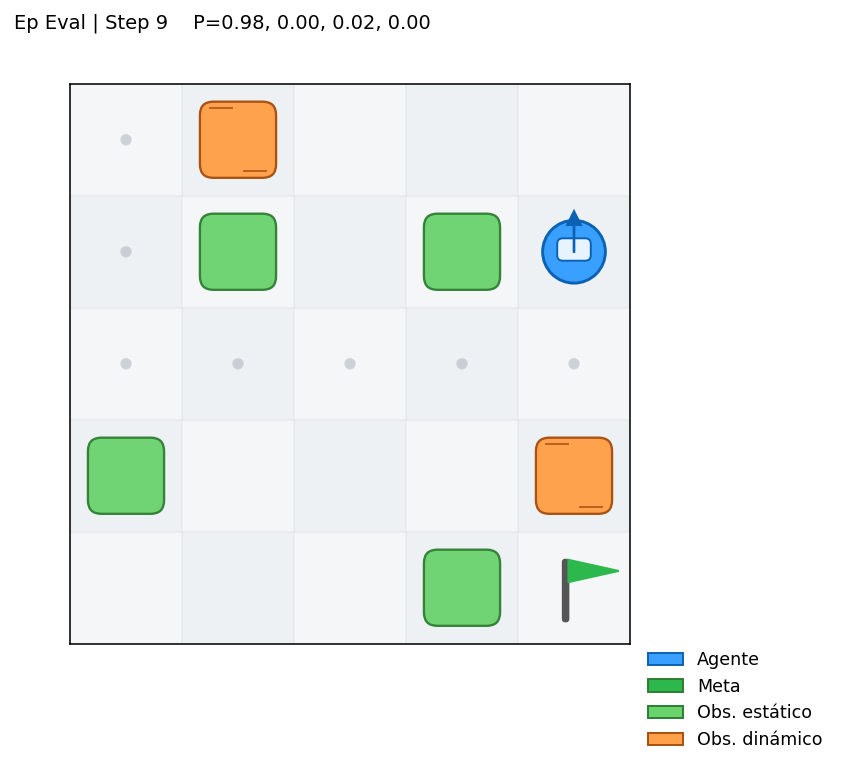

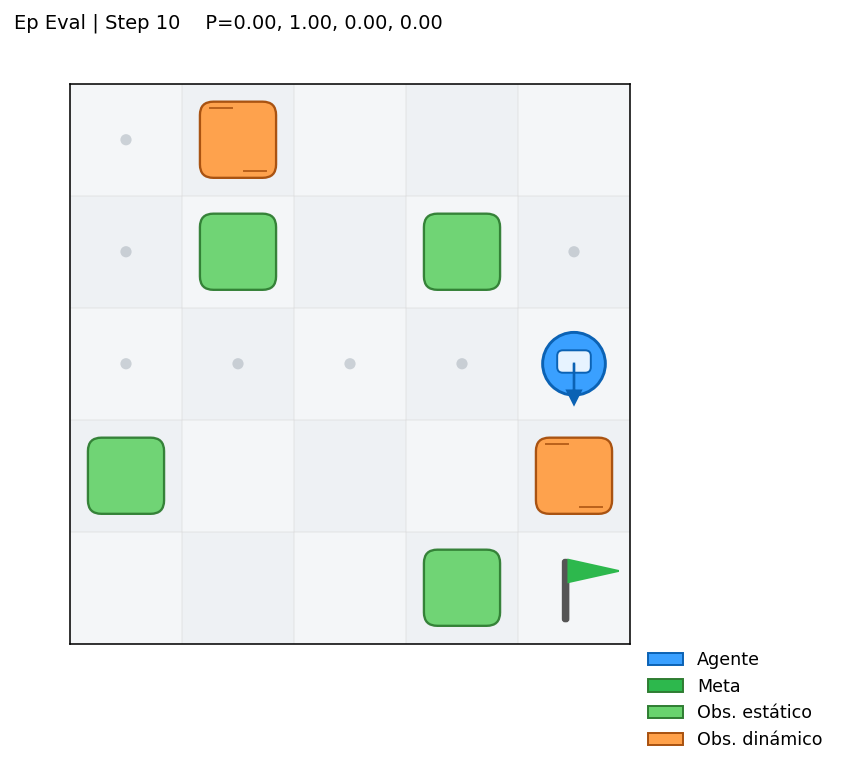

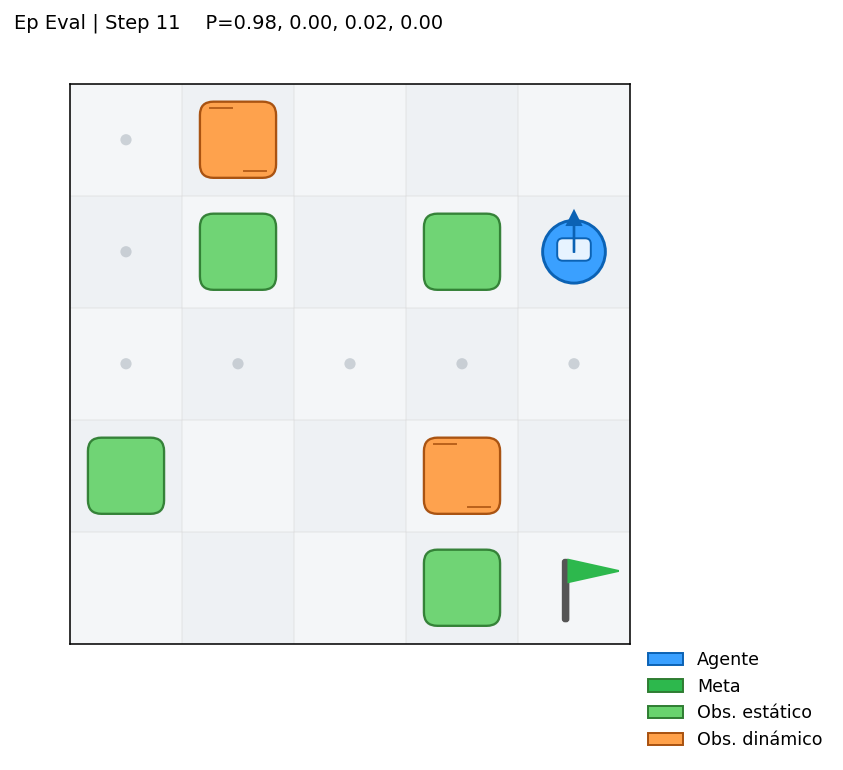

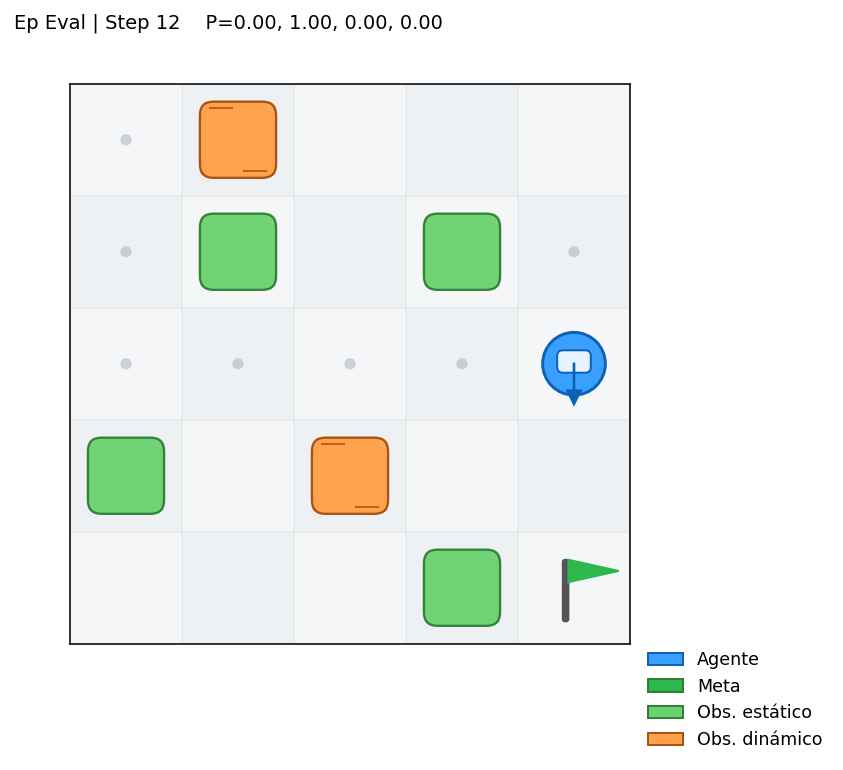

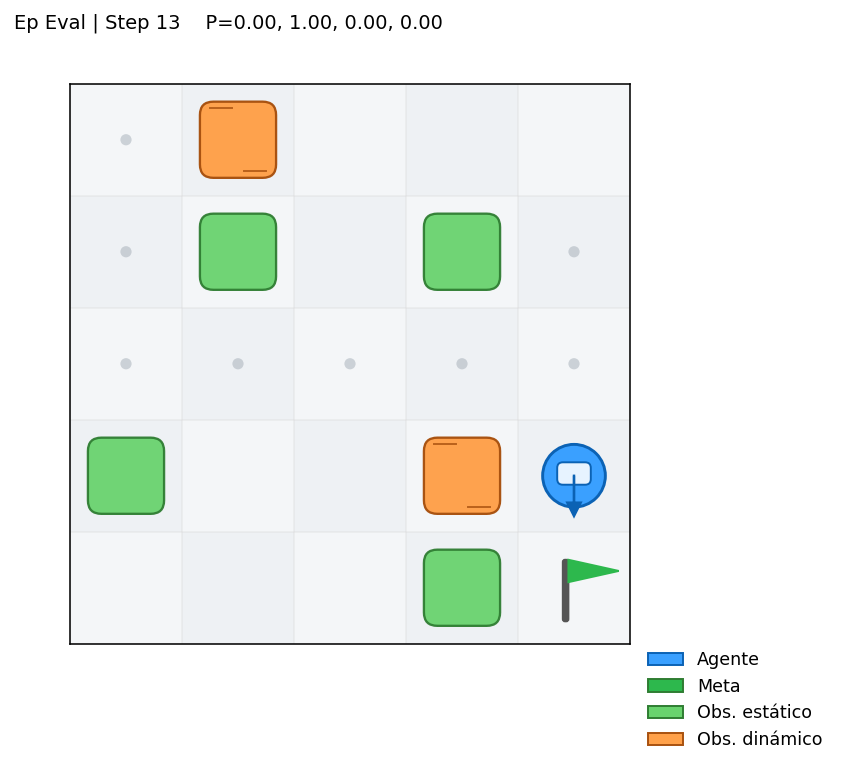

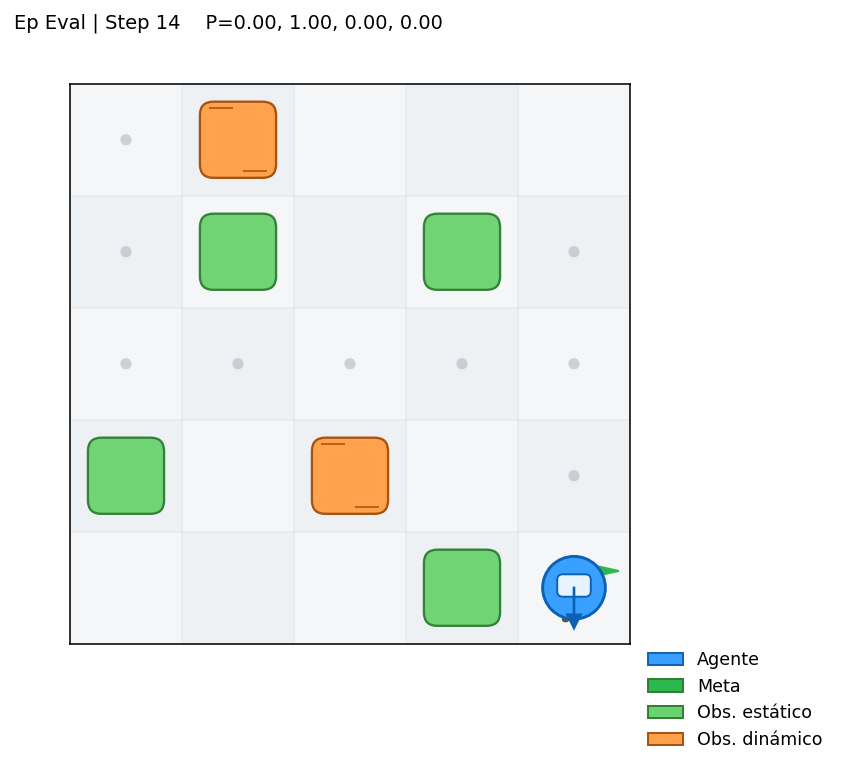

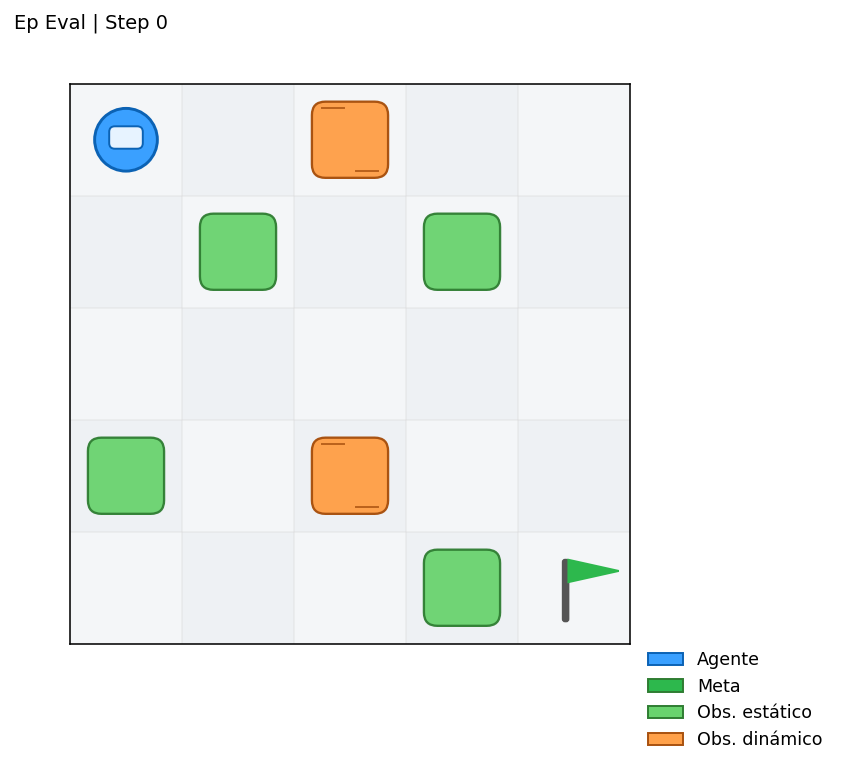

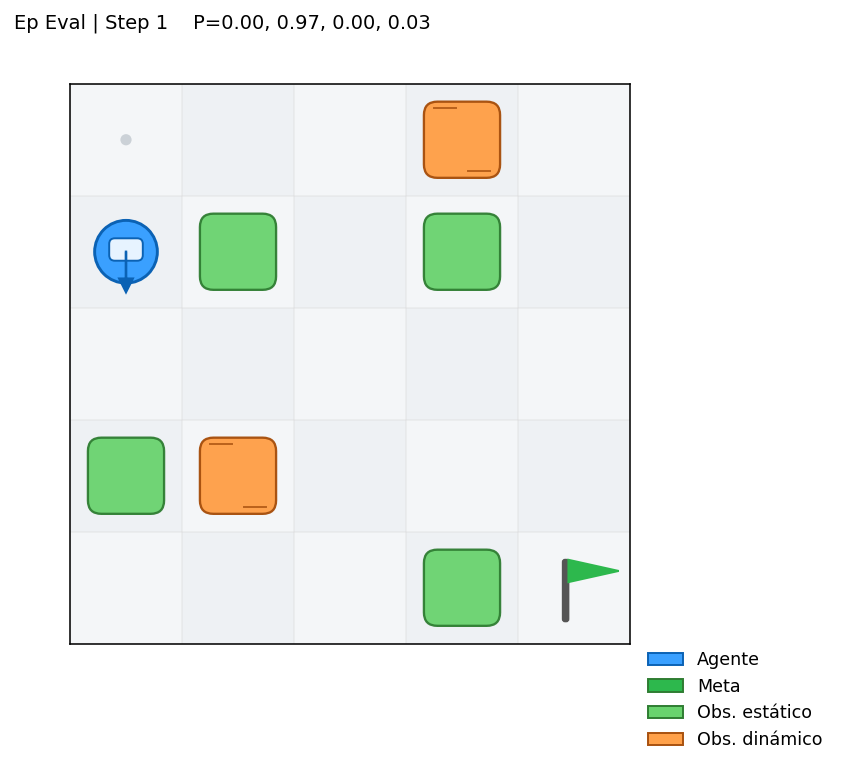

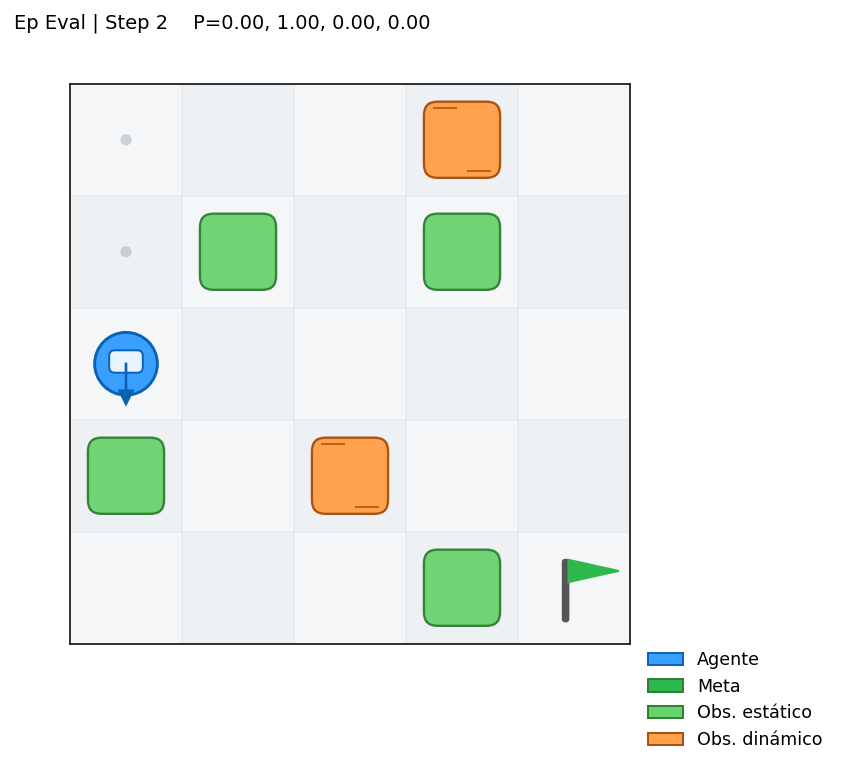

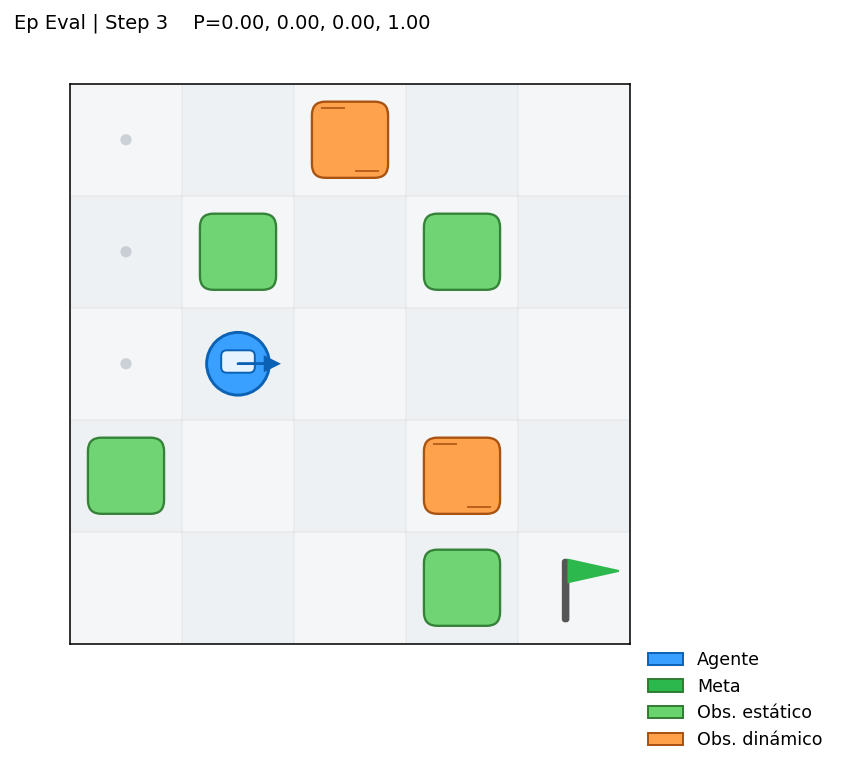

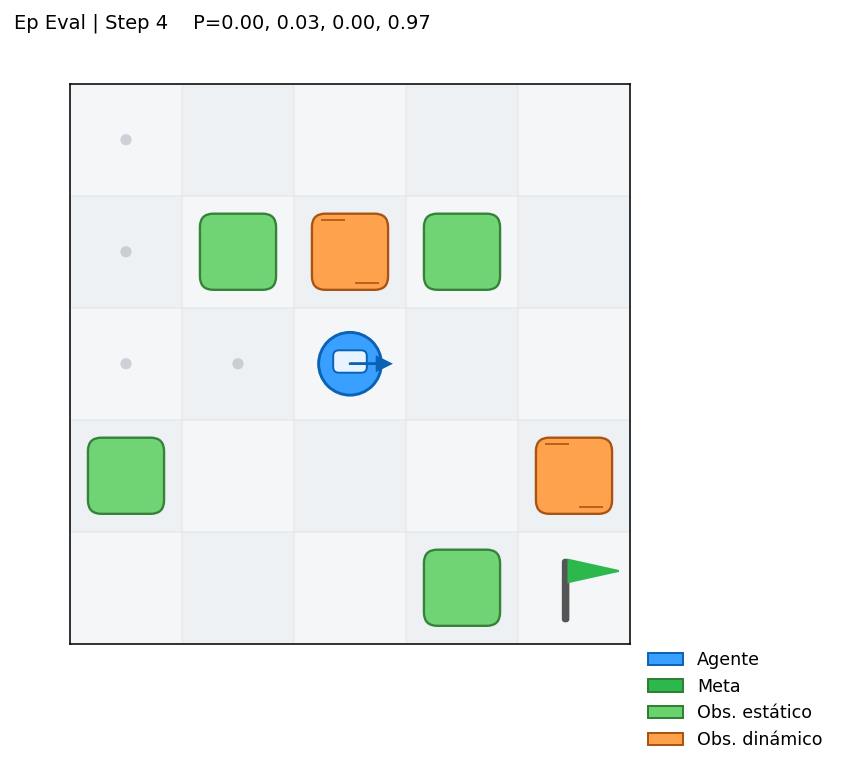

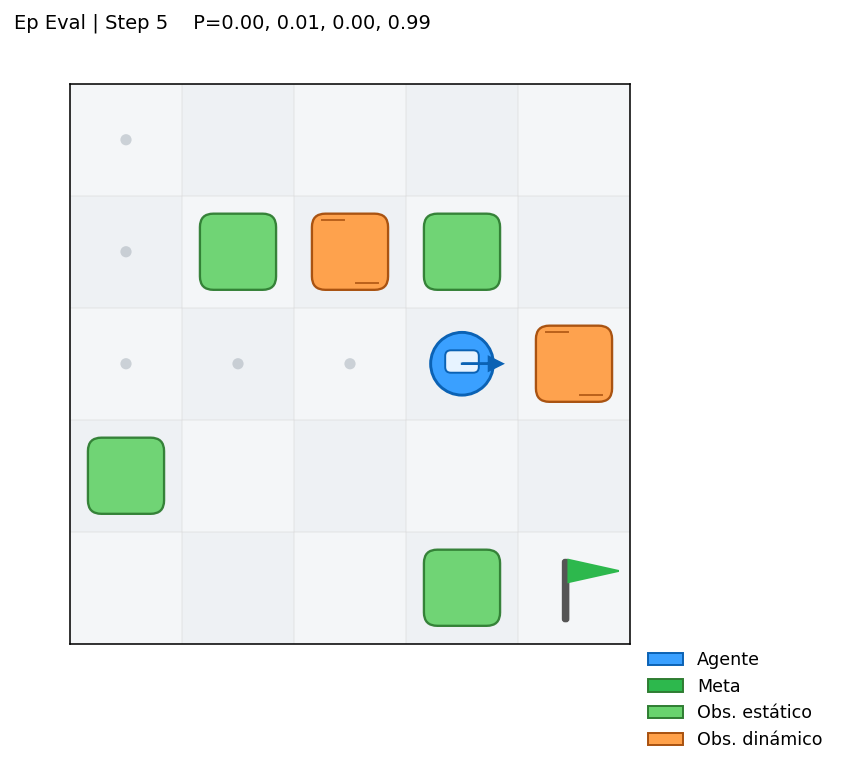

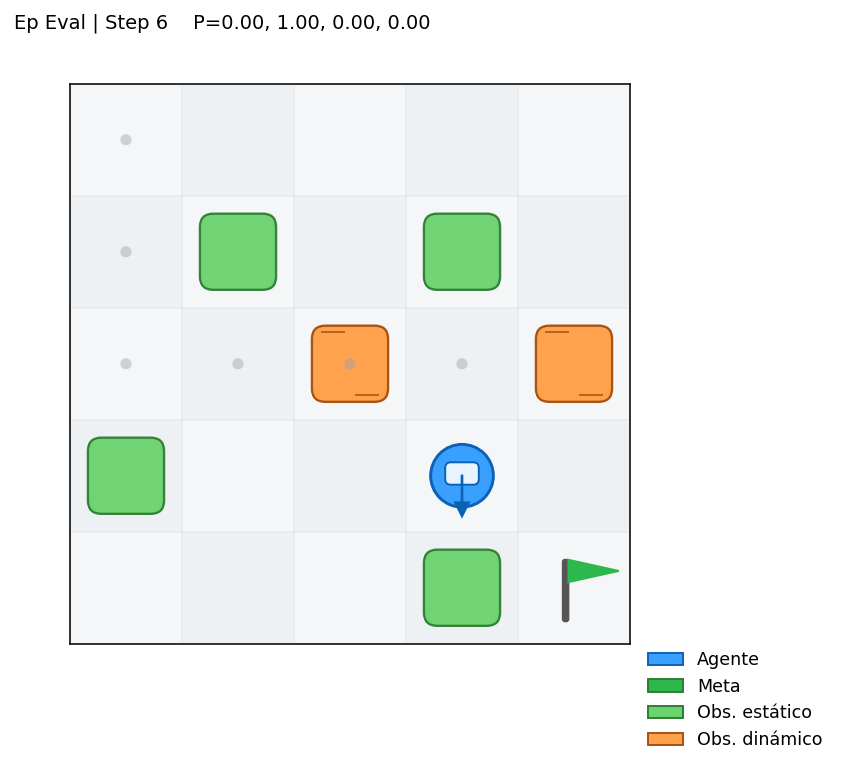

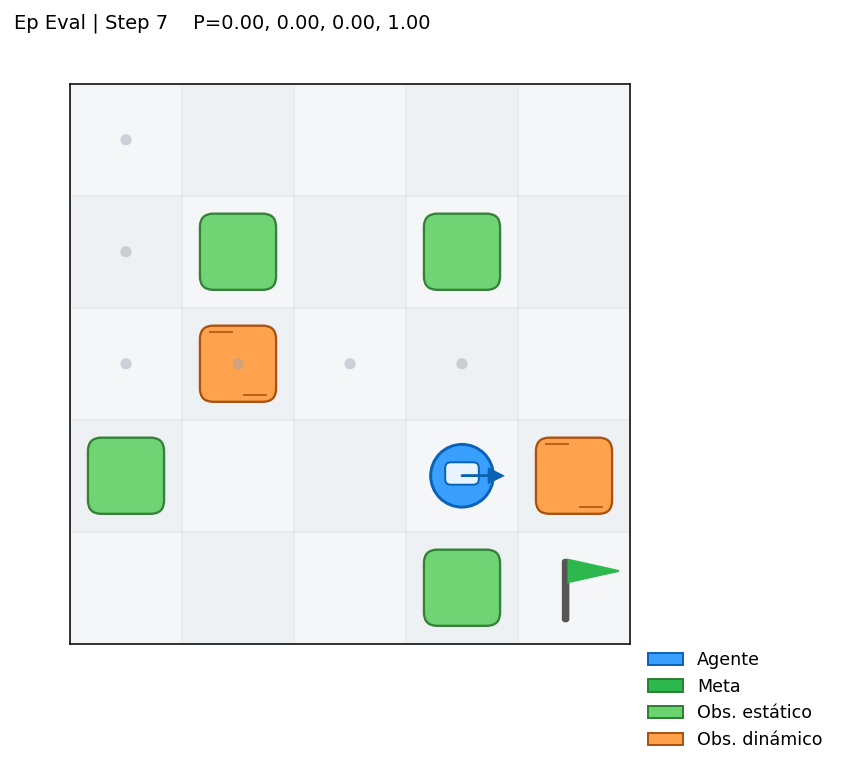

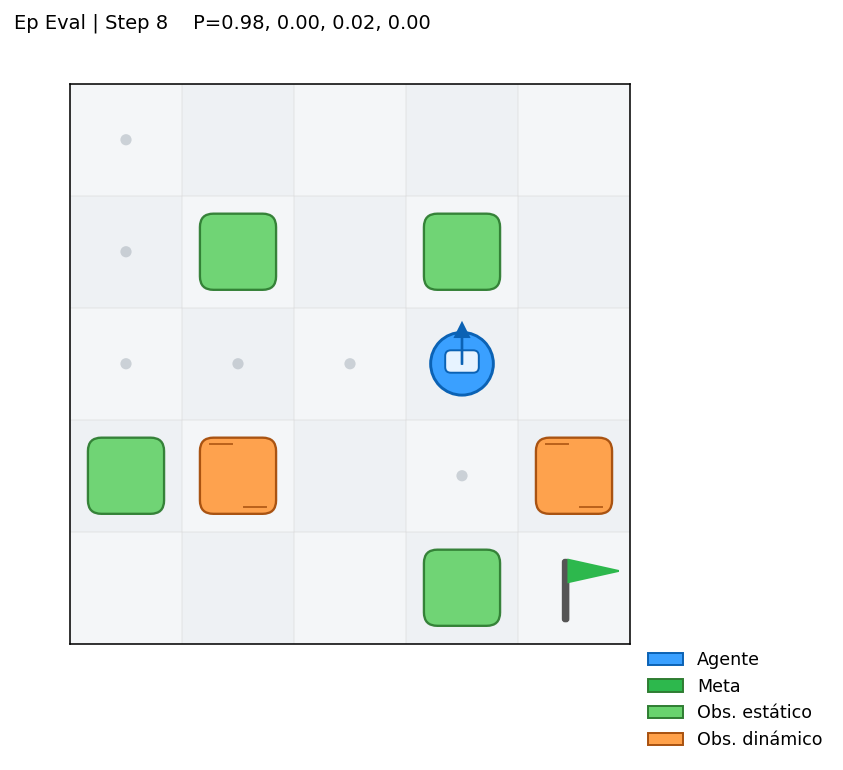

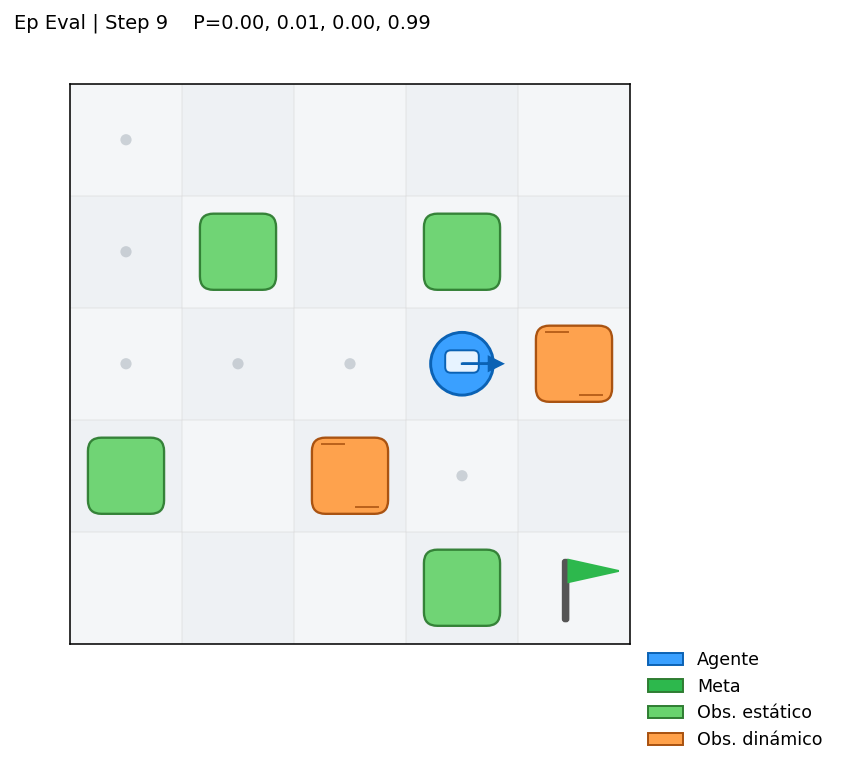

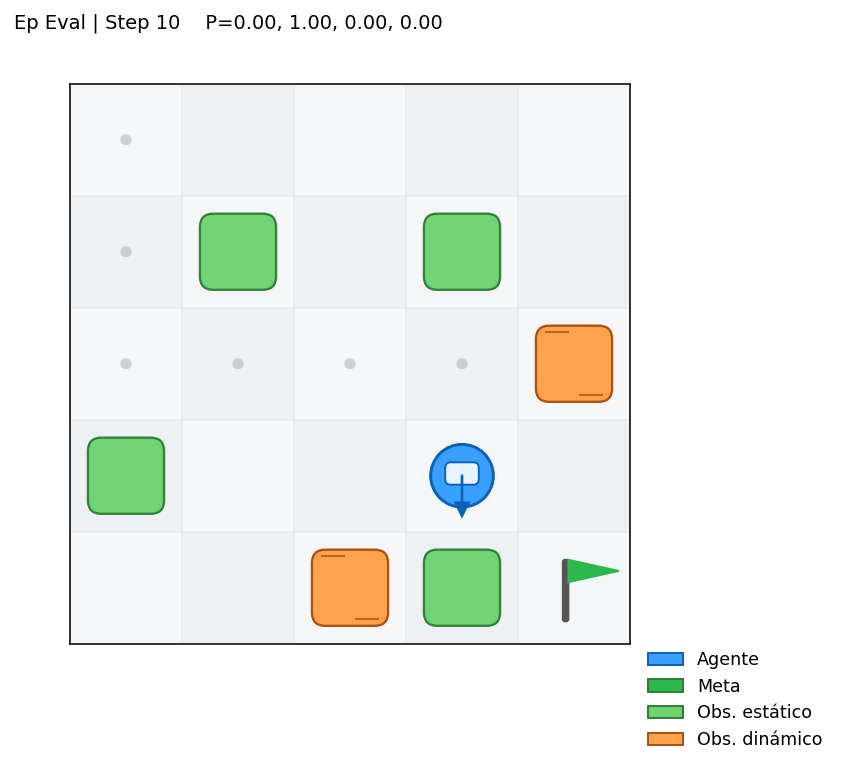

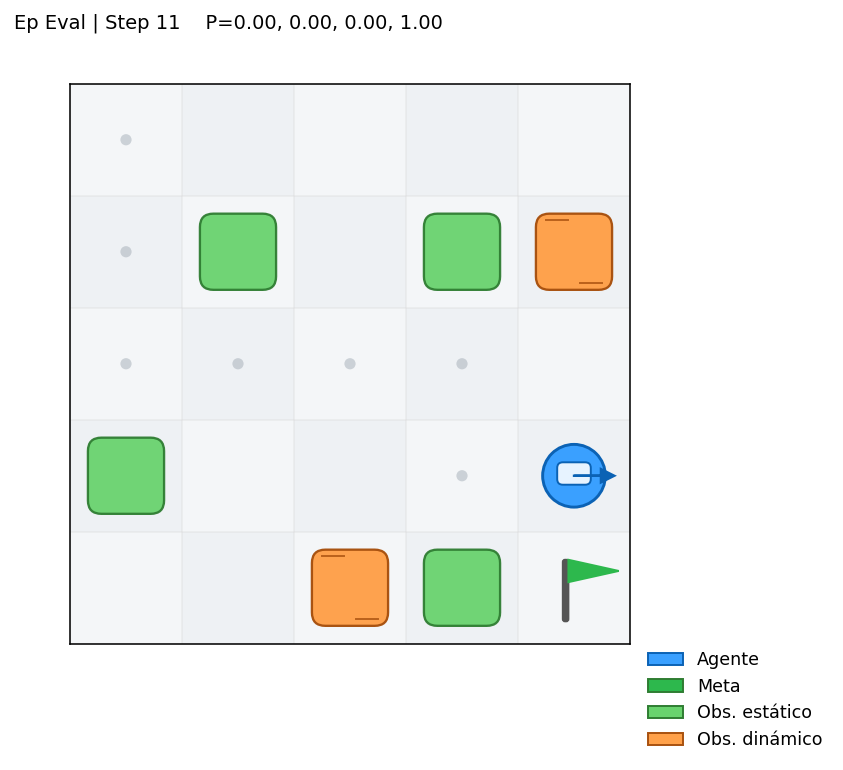

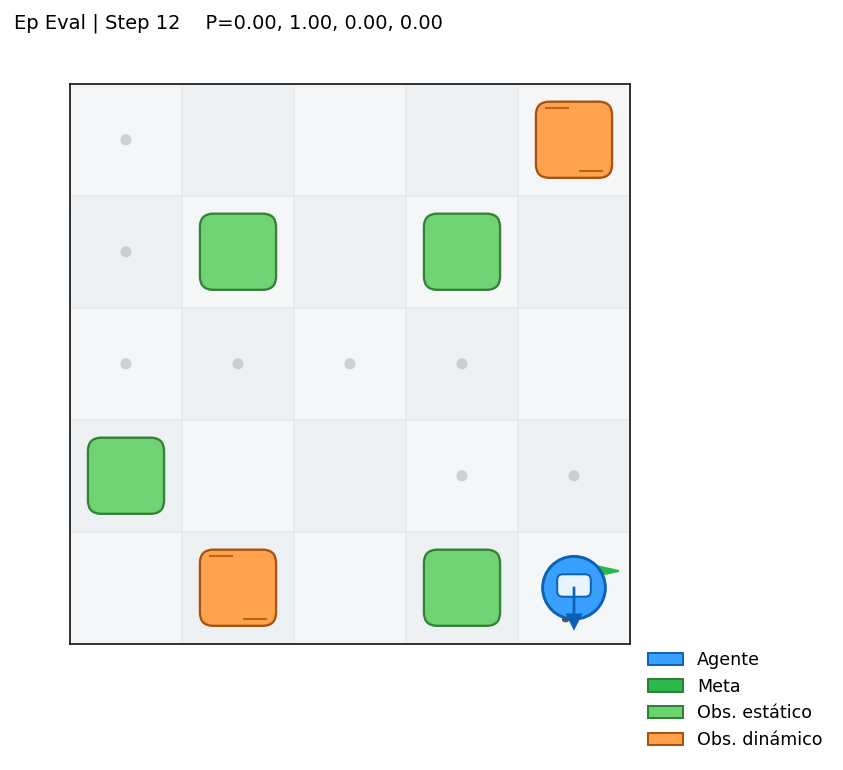

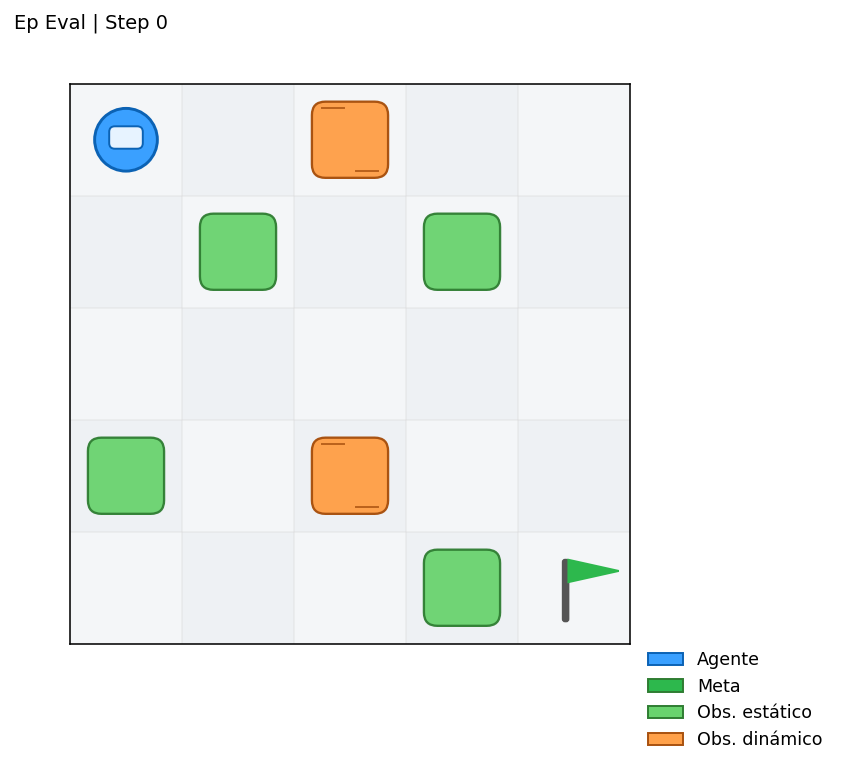

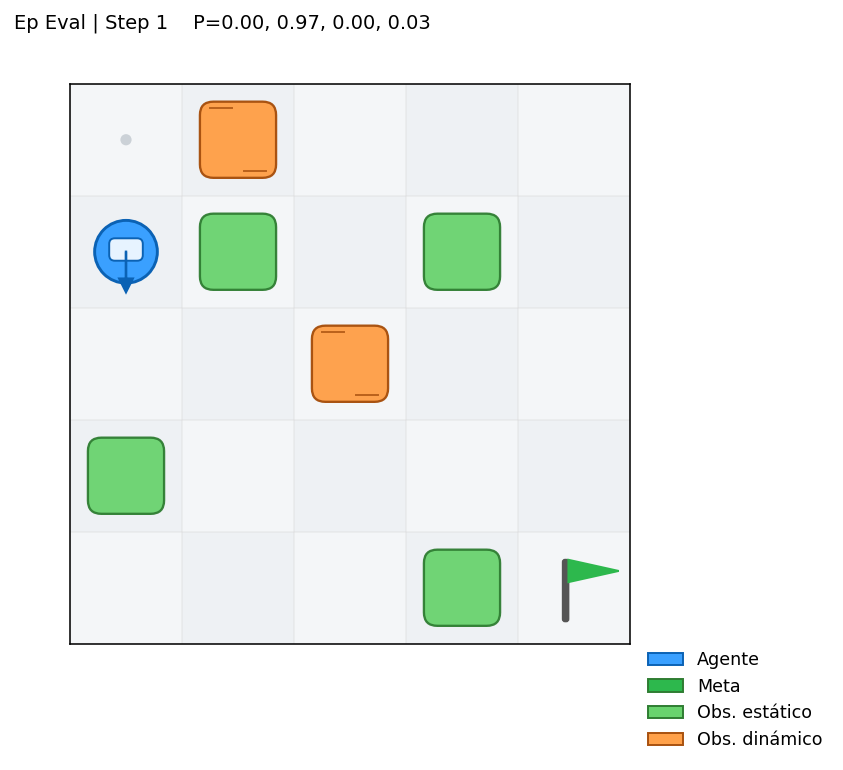

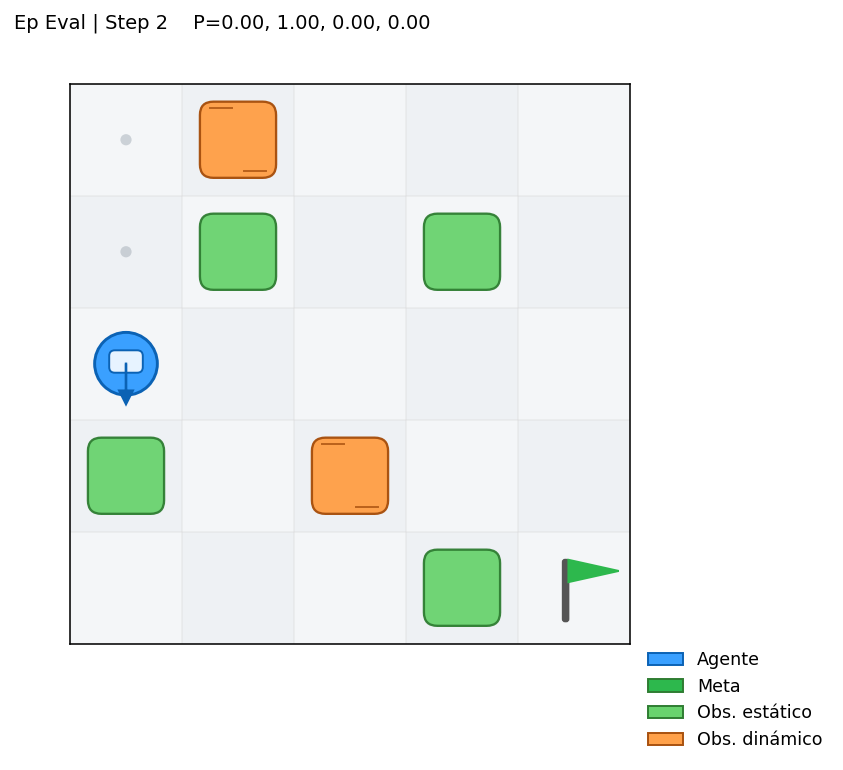

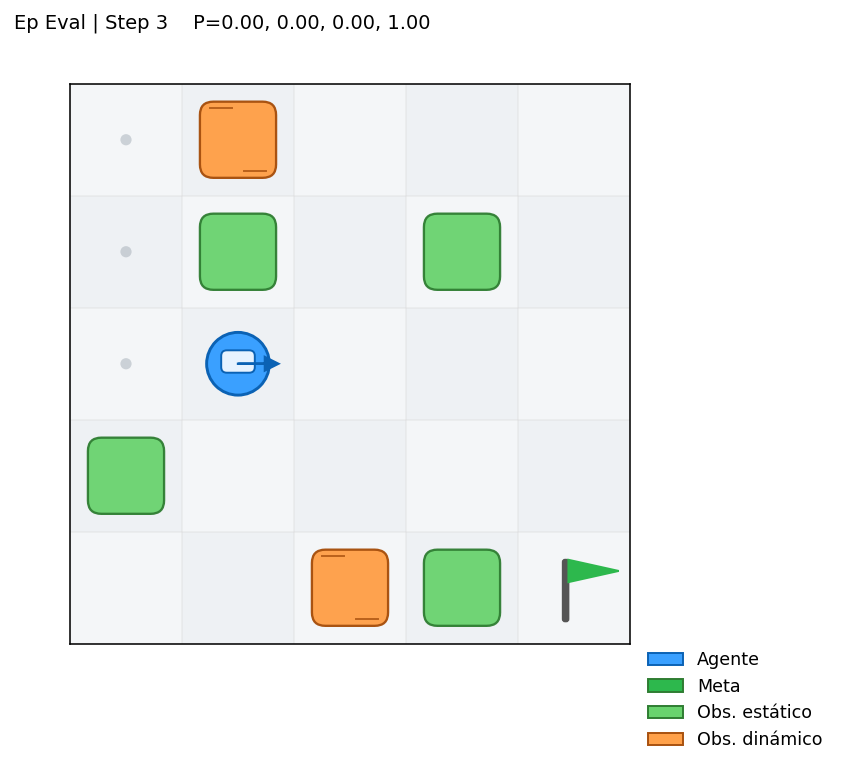

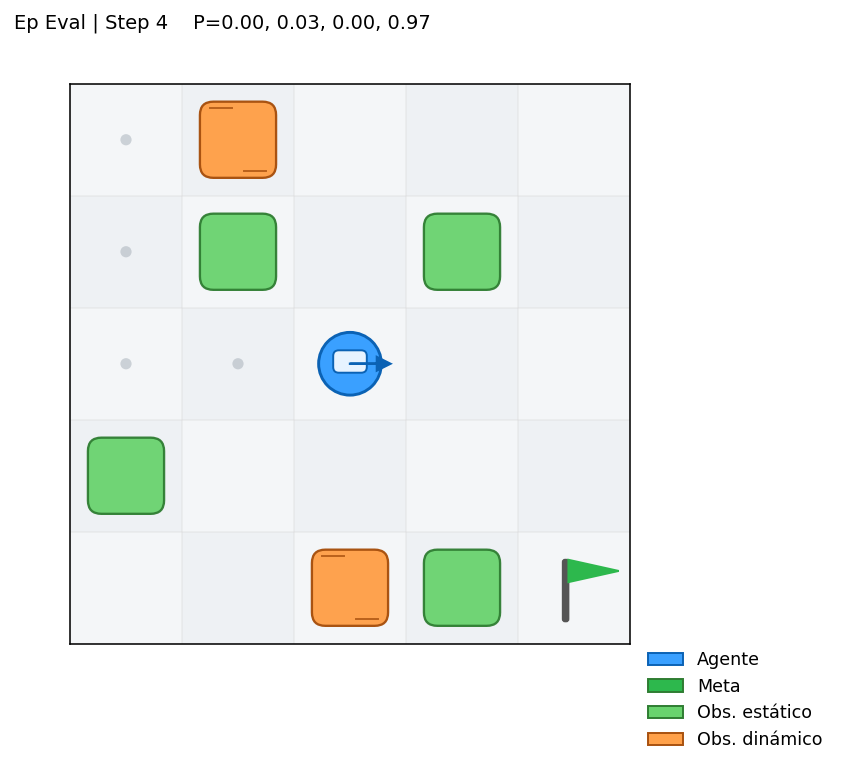

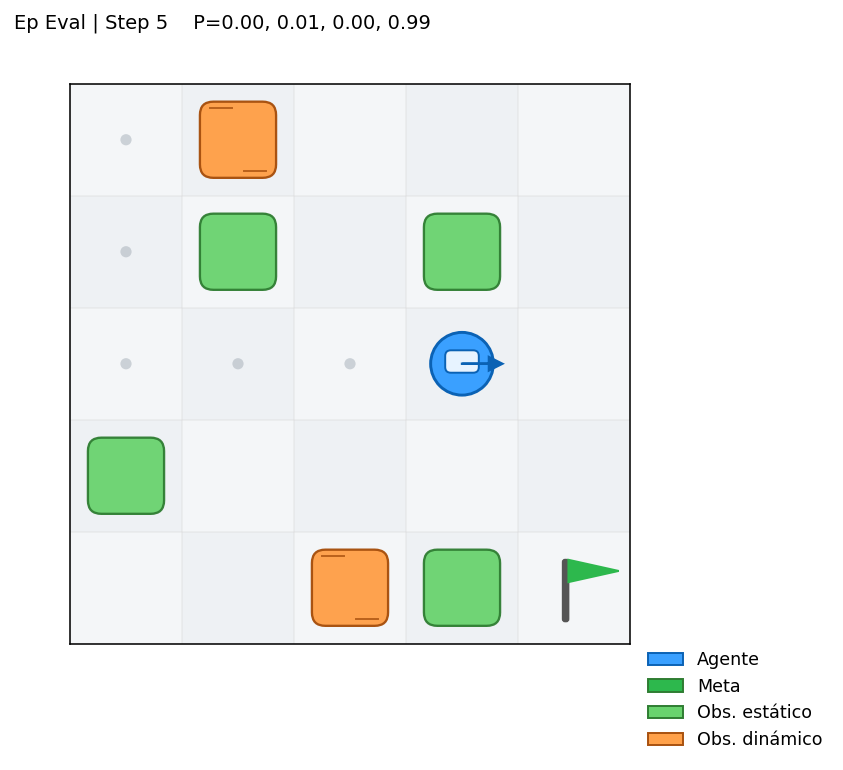

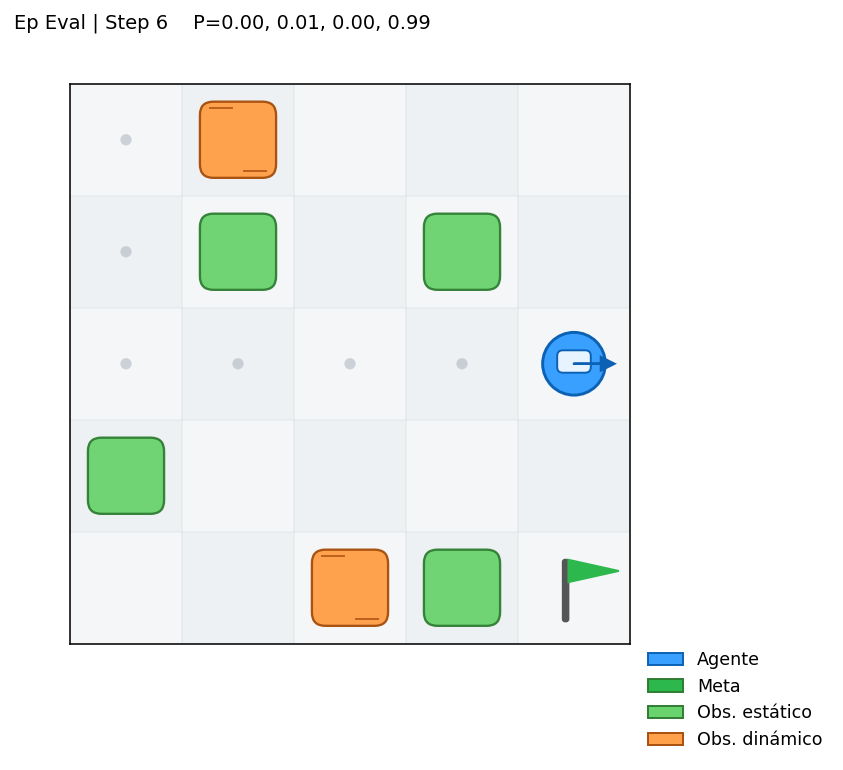

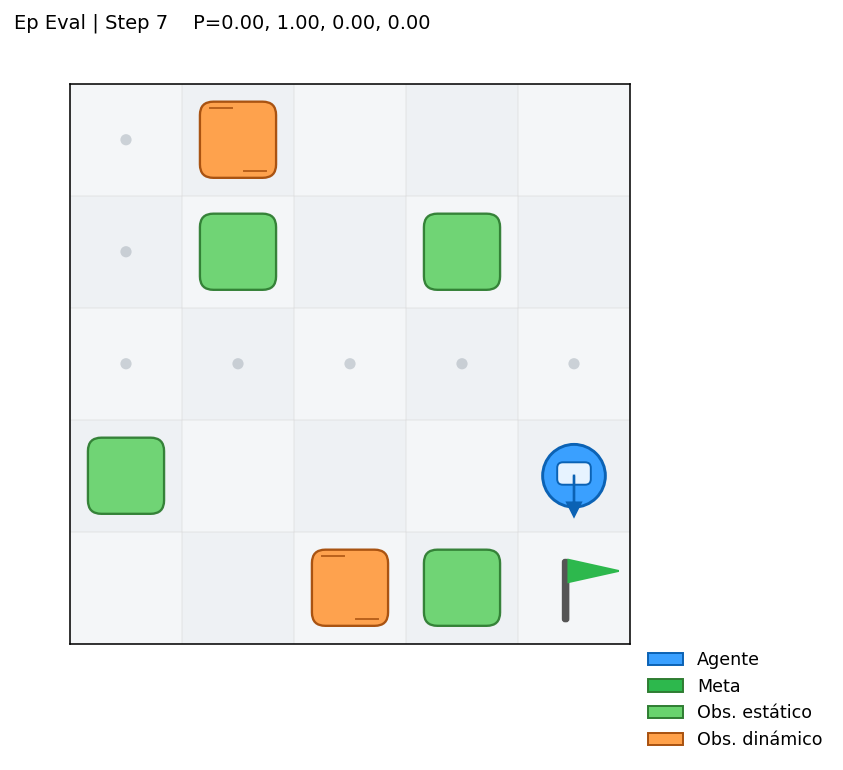

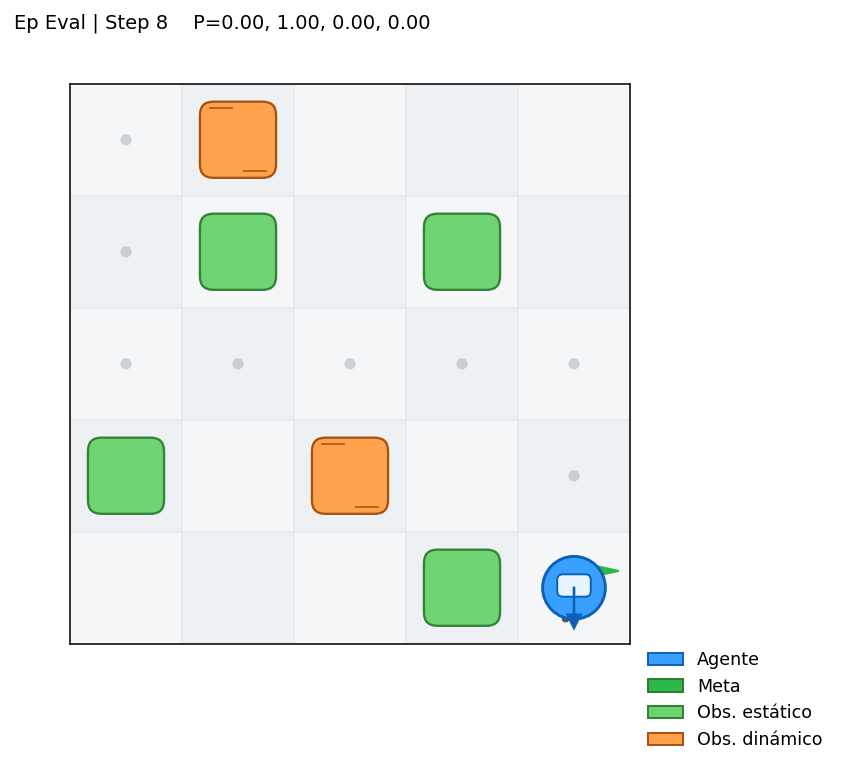

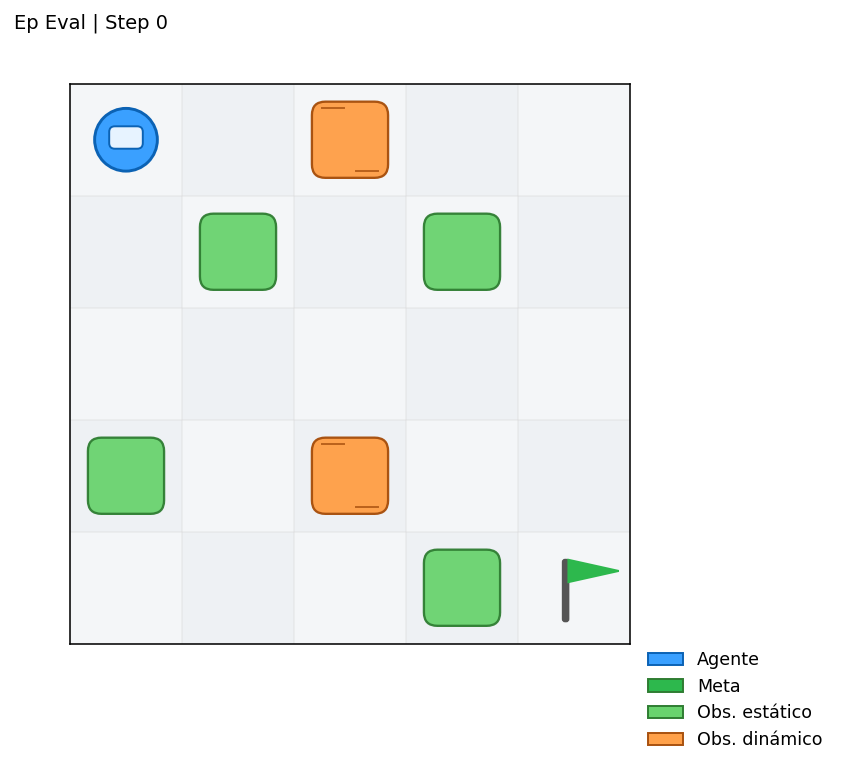

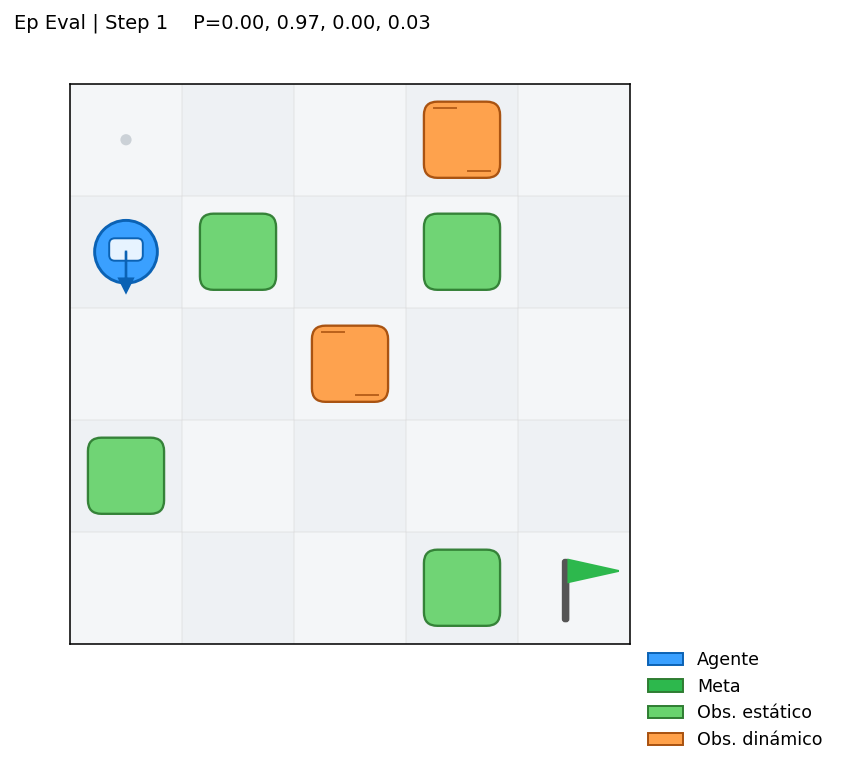

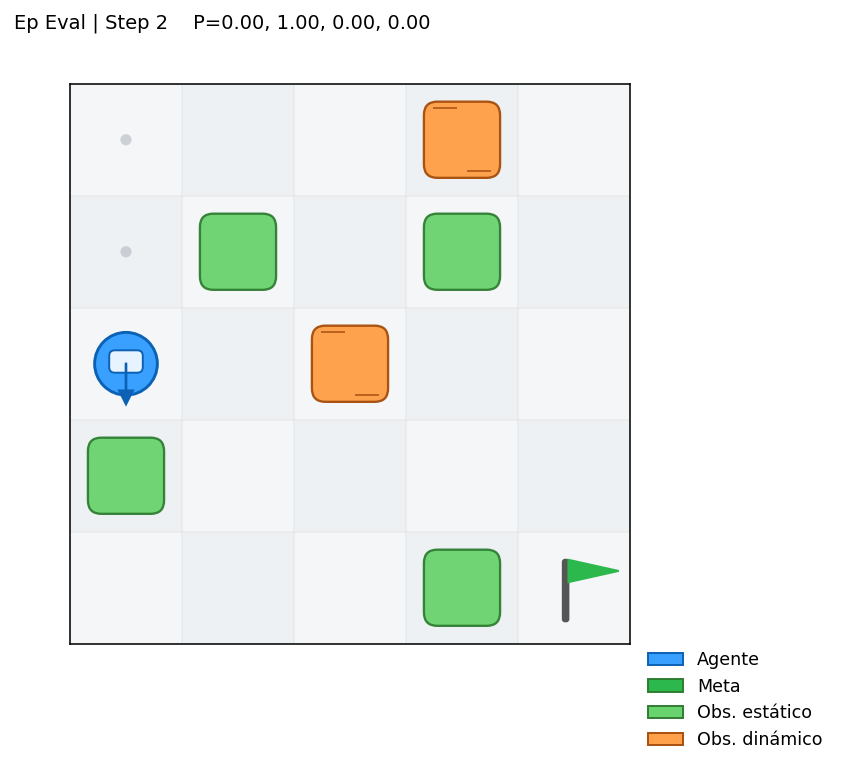

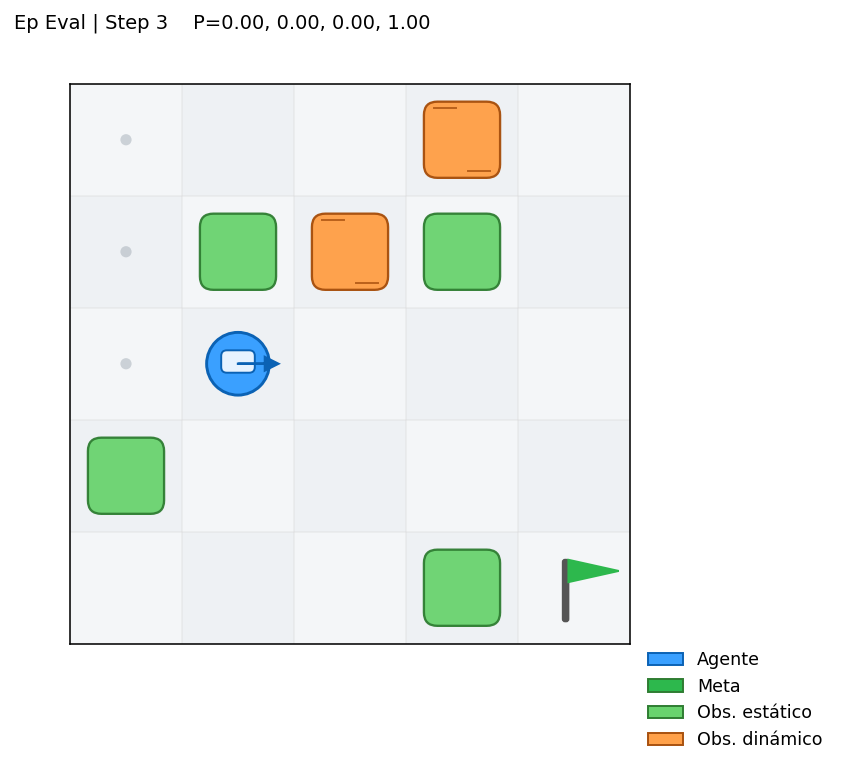

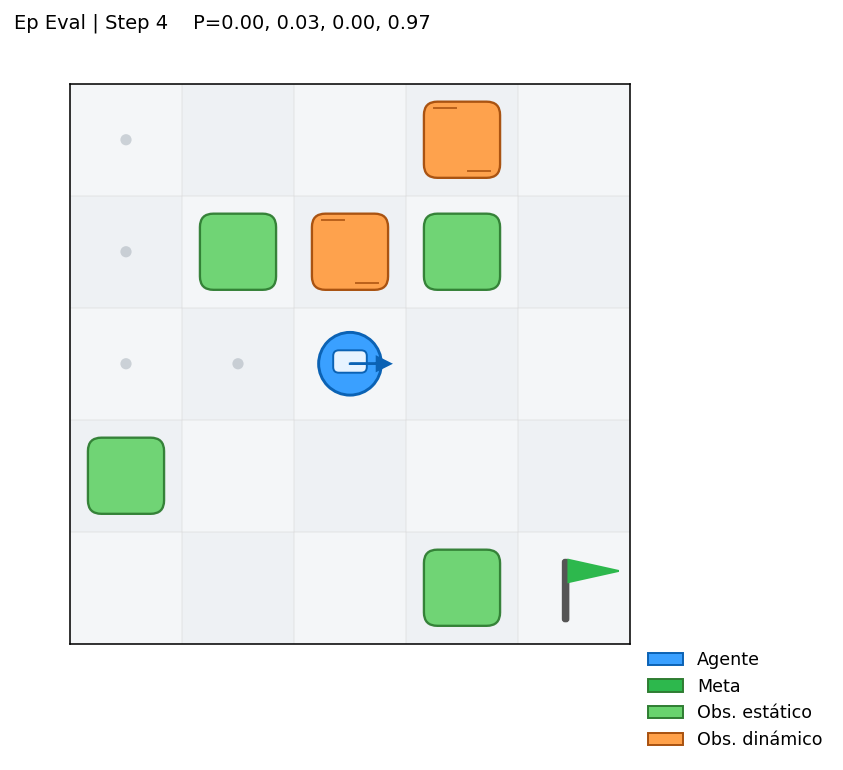

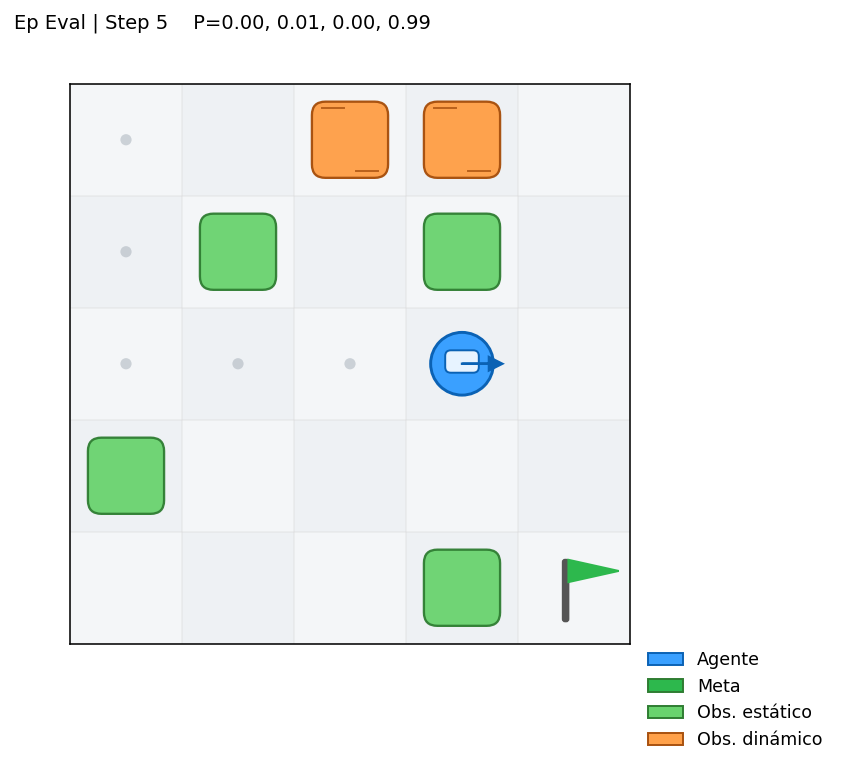

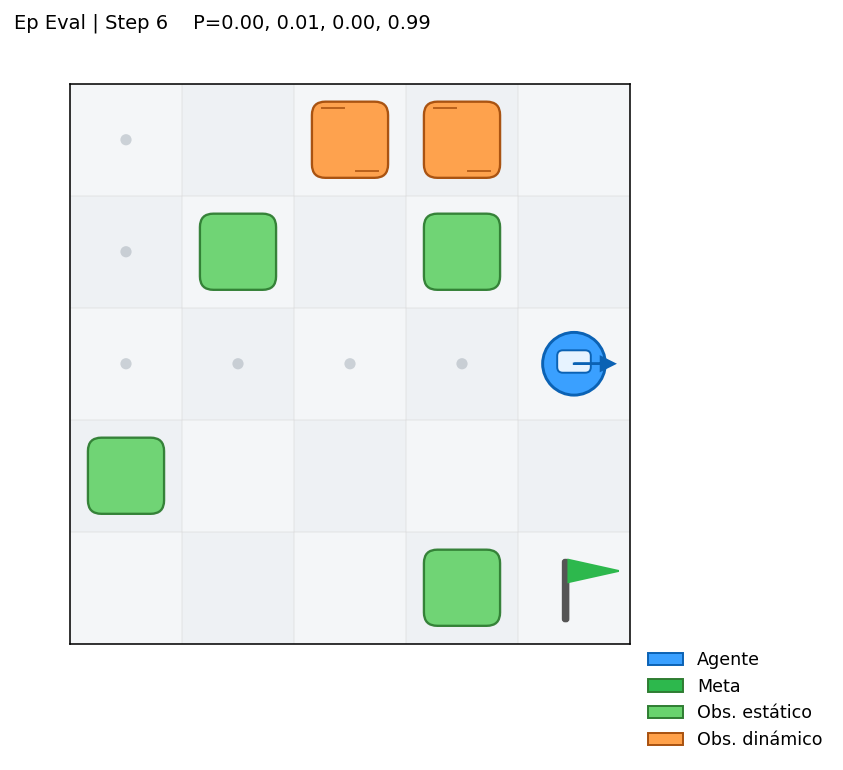

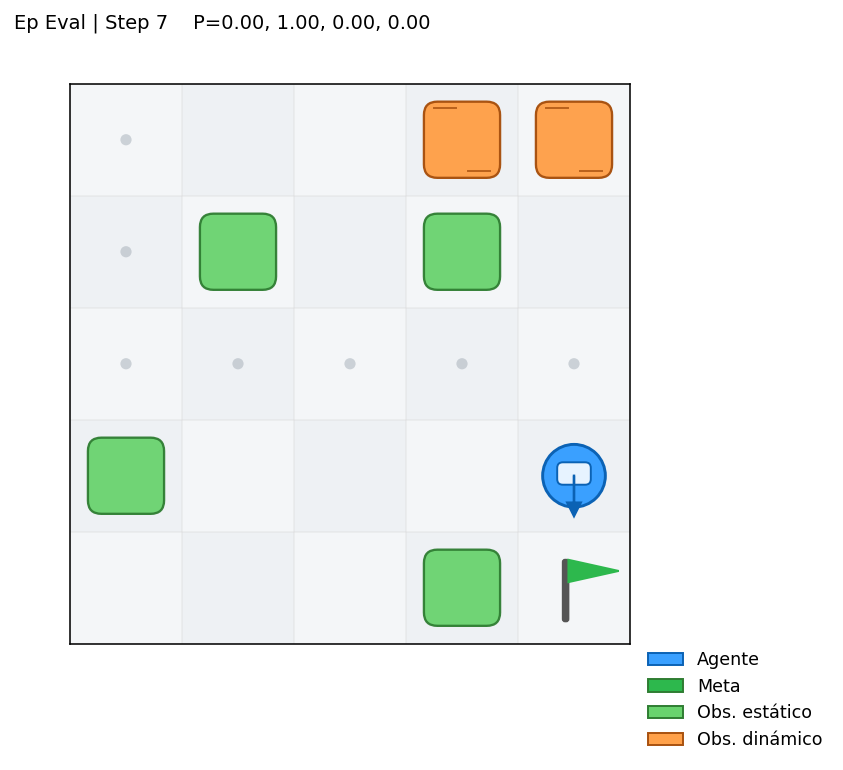

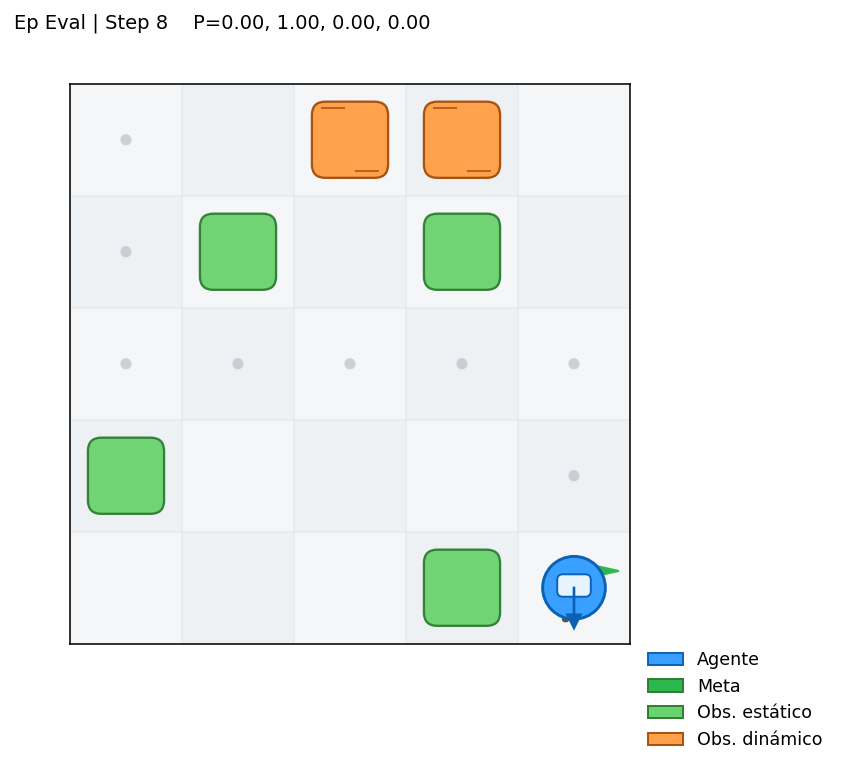

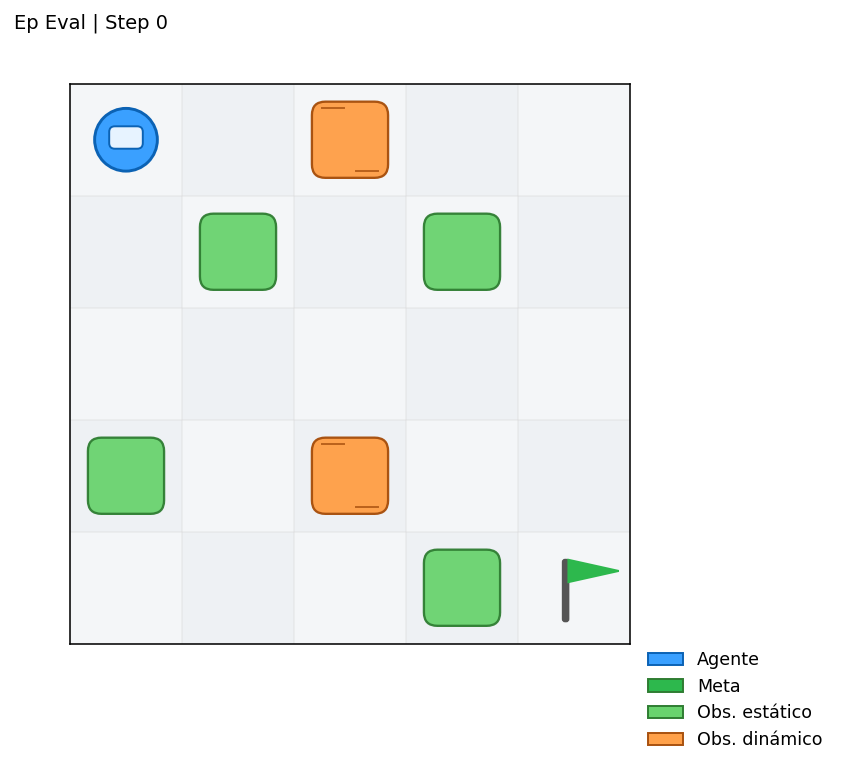

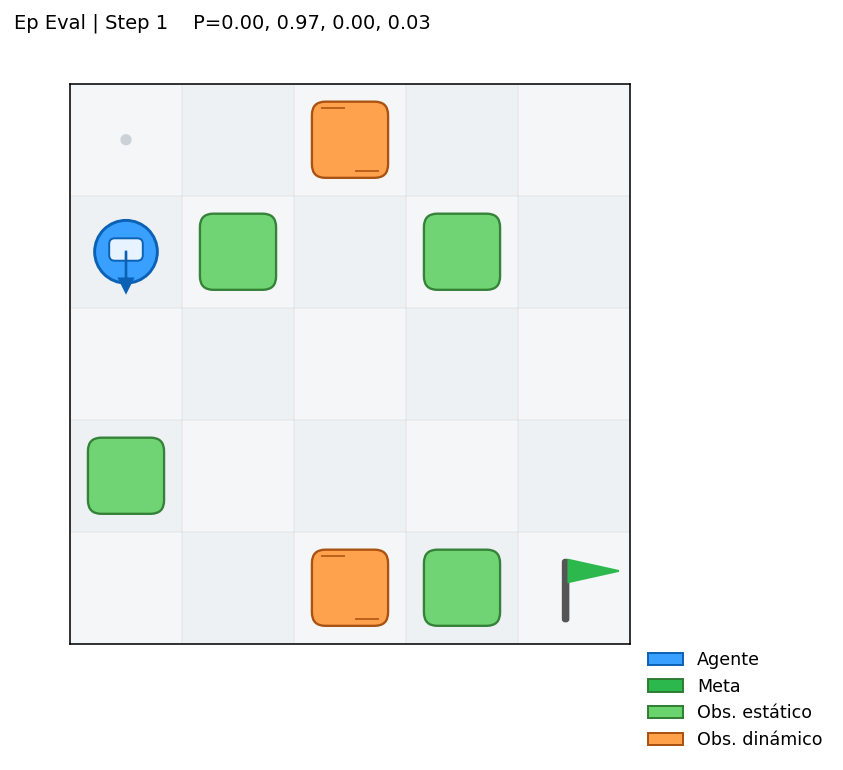

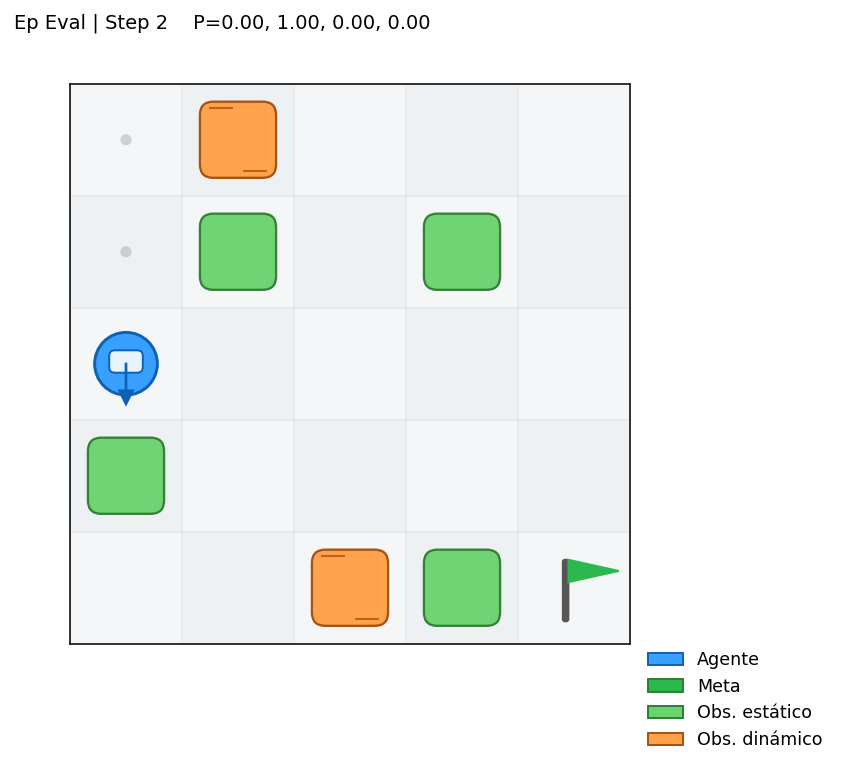

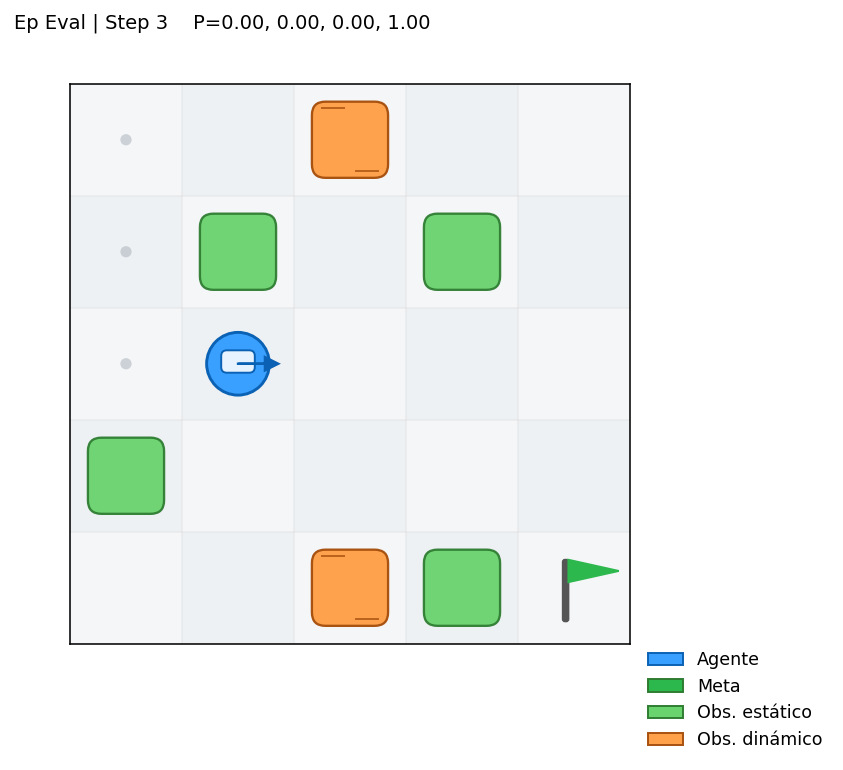

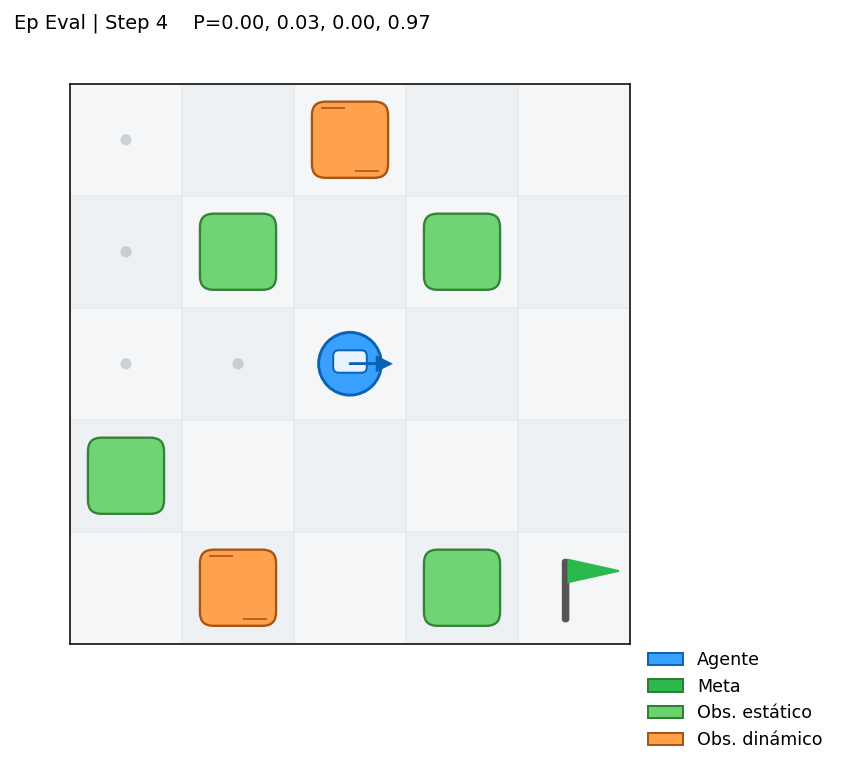

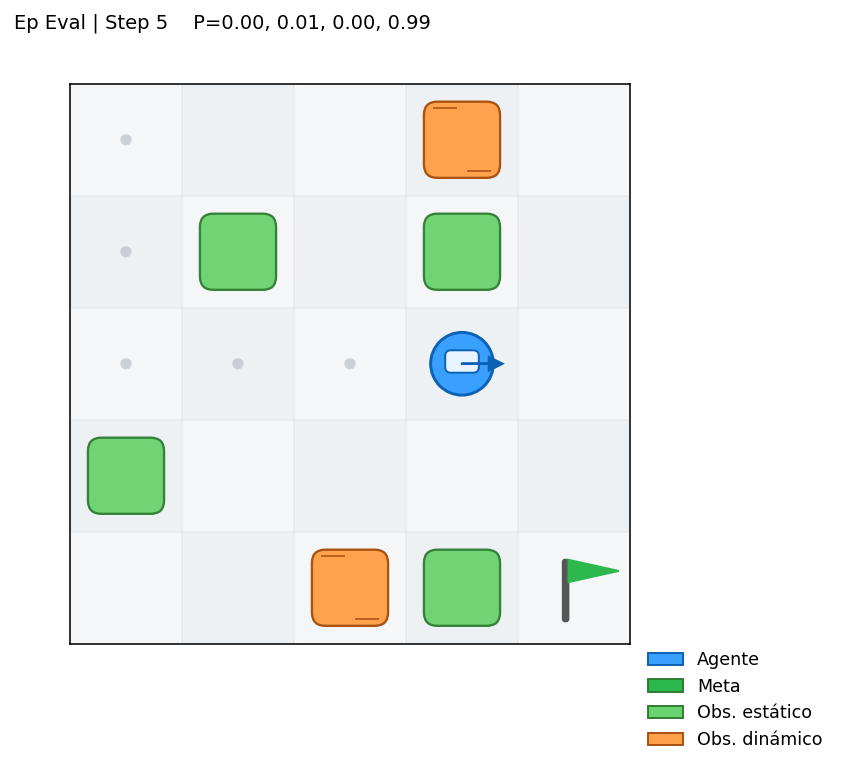

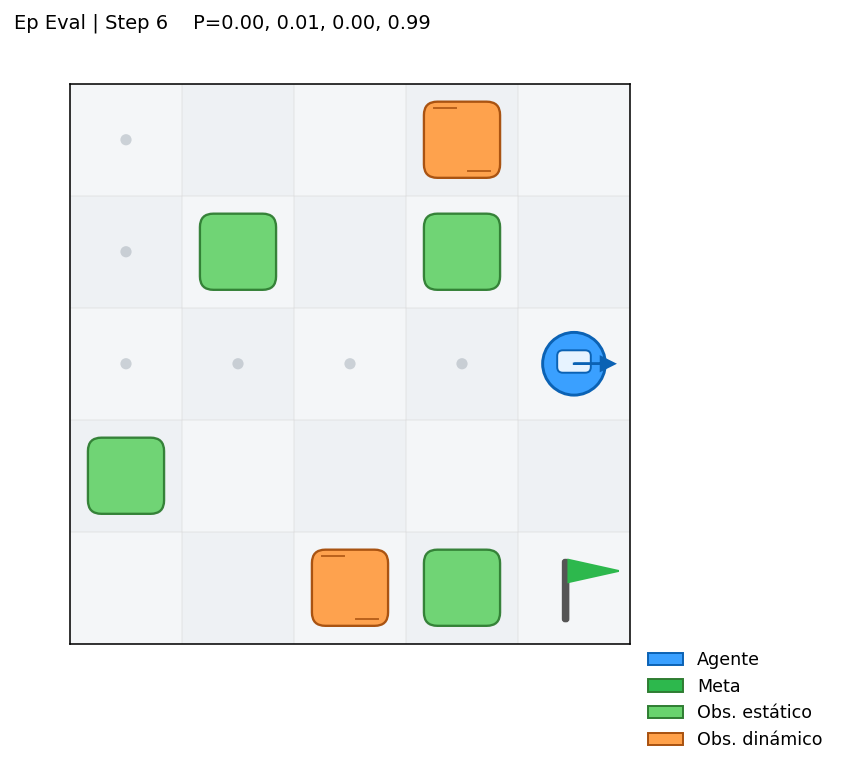

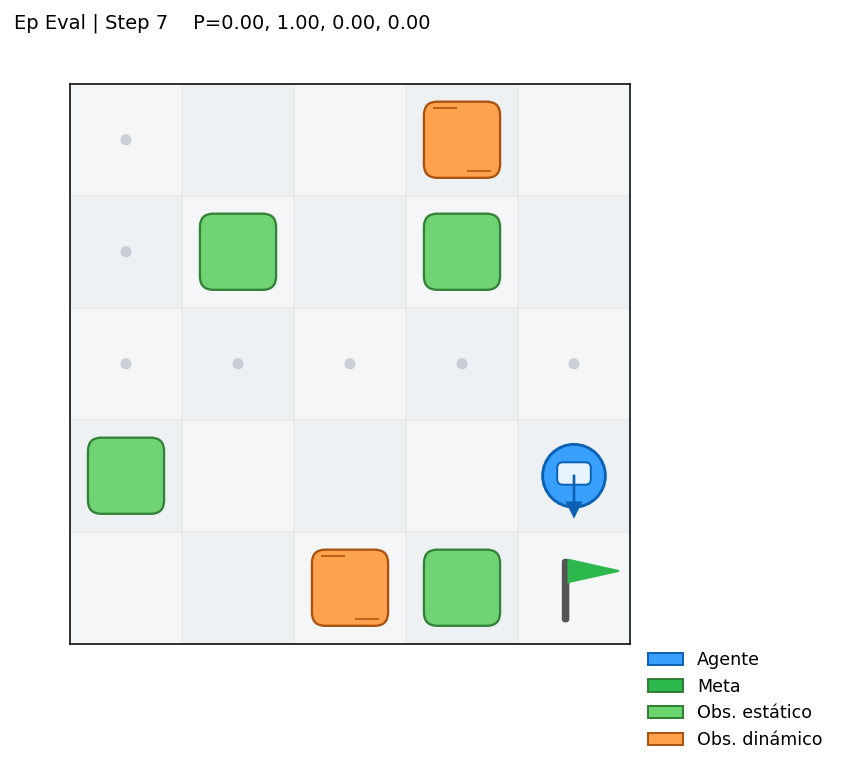

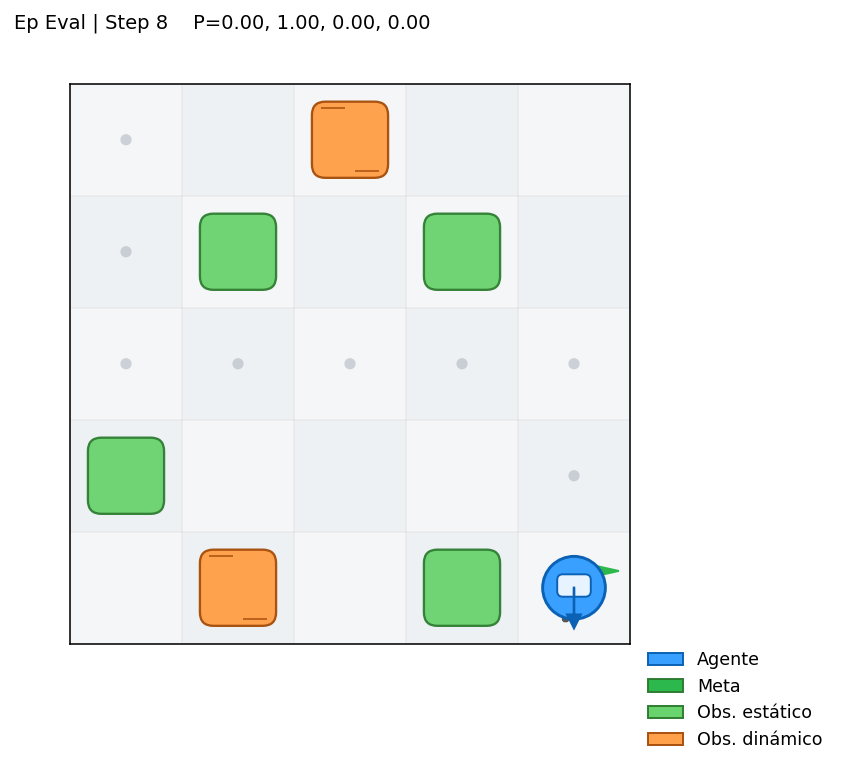

=== Stress test dinámico ===
{'trials': 10, 'success_rate': 1.0, 'avg_ep_len': 10.0, 'median_ep_len': 9, 'collisions': {'wall': 4, 'oob': 0, 'revisit': 14}}

=== ANÁLISIS DE ROBUSTEZ ===
Tasa de éxito: 100.0%
✅ EXCELENTE: Agente muy robusto (≥90% éxito)
Longitud promedio: 10.0 pasos
Longitud mediana: 9 pasos
Colisiones totales: {'wall': 4, 'oob': 0, 'revisit': 14}


In [ ]:
# ===== TESTE C: STRESS TEST COM OBSTÁCULOS DINÂMICOS =====
print("\n>>> Teste C: Stress test com obstáculos dinâmicos (N=50)")
print("Objetivo: Medir robustez estatística sob condições variáveis")
print("Método: Múltiplas avaliações independentes com obstáculos móveis")

# Executa stress test (usar render=False para velocidade, render=True para ver algumas)
stress = stress_test_dynamic(env, actor, device, trials=10, max_steps=300, render=True)

# Interpretação de resultados estatísticos
print("\n=== ANÁLISE DE ROBUSTEZ ===")
print(f"Taxa de sucesso: {stress['success_rate']:.1%}")

if stress['success_rate'] >= 0.9:
    print("✅ EXCELENTE: Agente muito robusto (≥90% sucesso)")
elif stress['success_rate'] >= 0.7:
    print("✅ BOM: Agente robusto (≥70% sucesso)")
elif stress['success_rate'] >= 0.5:
    print("⚠️ ACEITÁVEL: Agente moderadamente robusto (≥50% sucesso)")
else:
    print("❌ PROBLEMÁTICO: Agente pouco robusto (<50% sucesso)")
    print("   Considerar mais treinamento ou ajuste de hiperparâmetros")

print(f"Comprimento médio: {stress['avg_ep_len']:.1f} passos")
print(f"Comprimento mediano: {stress['median_ep_len']} passos")
print(f"Colisões totais: {stress['collisions']}")

# Recomendações baseadas nos resultados
if stress['collisions'].get('wall', 0) > stress['trials'] * 0.5:
    print("💡 Sugestão: Muitas colisões, considerar ajustar penalty de obstáculos")
if stress['avg_ep_len'] > base['ep_len'] * 1.5:
    print("💡 Sugestão: Episódios muito longos, possível ineficiência em ambiente dinâmico")